# Klasteryzacja dokumentów 20 Newsgroups — raport główny

**Autorzy:**  
- Patryk Jan Sozański, 300258
- Marcin Sadowski, 325220

Ten notebook stanowi raport do projektu grupowania tekstu na zbiorze 20 Newsgroups (UCI). Zawiera opis problemu, podstawy teoretyczne, implementacje kolejnych elementow pipeline'u oraz komorki wykonawcze, ktore uruchamiaja eksperymenty krok po kroku.

Celem projektu jest porownanie reprezentacji dokumentow tekstowych oraz algorytmow klasteryzacji: `K-means`, `klasteryzacji hierarchicznej`, `DBSCAN` oraz `klasteryzacji spektralnej`. Etykiety z `20 Newsgroups` nie sa uzywane do uczenia ani grupowania; pojawiaja sie dopiero w ocenie zewnetrznej przez `ARI`.

## Opis problemu

Klasteryzacja dokumentow to zadanie nienadzorowane: chcemy grupowac teksty tak, aby dokumenty podobne tematycznie trafialy do tych samych klastrow, bez wykorzystania etykiet klas podczas uczenia.  
W praktyce problem sprowadza sie do:
- wyboru reprezentacji tekstu (jak zamienic dokument na wektor),
- wyboru algorytmu klasteryzacji,
- doboru hiperparametrow (np. liczba klastrow `k`, linkage, `eps`),
- oceny jakosci klastrow metrykami wewnetrznymi i zewnetrznymi.

## Podejscie eksperymentalne

Pipeline jest uruchamiany etapowo:
1. **Przygotowanie danych**: czyszczenie, normalizacja, tokenizacja i lematyzacja.  
2. **Budowa reprezentacji**:
    - bazowa, podstawowa reprezentacja `TF-IDF` (baseline),
    - statyczne embeddingi (`GloVe` jako proxy, `fastText`),
    - kontekstowe embeddingi (`SBERT`).
3. **Klasteryzacja**:
    - `K-means`,
    - `Agglomerative Clustering`,
    - `DBSCAN`,
    - `Spectral Clustering`.
4. **Ocena jakosci**:
    - metryki wewnetrzne: `silhouette`, `Davies-Bouldin`, `Dunn`,
    - metryka zewnetrzna: `ARI` (tylko do porownania z rzeczywistymi etykietami).
5. **Analiza i raportowanie**:
    - wybor najlepszych przebiegow,
    - interpretacja klastrow przez slowa kluczowe i dokumenty reprezentatywne,
    - zapis artefaktow (CSV/JSON/wykresy/MLflow).

Eksperyment wspiera dwa tryby pracy:
- `quick` do szybkiej walidacji calego przeplywu,
- `full` do pelnej analizy i wynikow koncowych.

## 1. Srodowisko uruchomieniowe

Notebook nie wykonuje lokalnie komend instalacyjnych w komorkach. Lokalnie powinien byc uruchamiany na kernelu `Python (.venv)`, przygotowanym przez `setup_local_env.sh`. Komorka ponizej tylko sprawdza, czy wymagane biblioteki sa dostepne, i podaje jasny komunikat, jesli brakuje srodowiska.

In [2]:
import importlib.util
import sys
from pathlib import Path

REQUIRED_PACKAGES = ['mlflow', 'matplotlib', 'numpy', 'pandas', 'plotly', 'nltk', 'sentence_transformers', 'sklearn', 'gensim', 'tqdm', 'wordcloud']
missing_packages = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

if missing_packages:
    raise RuntimeError(
        "Missing packages: " + ", ".join(missing_packages) + "\n"
        "Local setup: run ./setup_local_env.sh and select kernel 'Python (.venv) ZUM'."
    )

print("Environment check passed.")


Python executable: /home/marcin/Desktop/text_group_20Newsgroups/.venv/bin/python
Python version: 3.13.9
Environment check passed.


## 1. Konfiguracja i parametry sterujące

W celu łatwego zarządzania eksperymentem, wprowadzamy globalny słownik konfiguracyjny. Pozwala to na:
1. Szybkie przełączanie między trybem szybkiego testowania (`quick`), a pełną ewaluacją (`full`).
2. Centralne zarządzanie siatkami parametrów dla każdego z algorytmów.
3. Parametryzację kosztownych operacji wektoryzacji i obliczania metryk dających odpowiedzi w czasie rzeczywistym.

Główne klucze konfiguracji:
- `mode`: tryb wykonania (`quick` lub `full`),
- `seed`: ziarno losowości dla zapewnienia powtarzalności (reprodukowalność),
- `kmeans_sample_size`: liczba dokumentów używana dla algorytmu K-Means (algorytm o złożoności liniowej $O(n)$),
- `hierarchical_sample_size`: limit próbek dla klasteryzacji hierarchicznej (algorytm o złożoności $O(n^2)$),
- `dbscan_sample_size`: limit próbek dla algorytmu DBSCAN (algorytm gęstościowy operujący na macierzy odległości $O(n^2)$),
- `spectral_sample_size`: limit próbek dla klasteryzacji spektralnej ($O(n^3)$ lub na wybranym grafie $O(n^2)$),
- `silhouette_sample_size`: próbkowanie dla miary silhouette,
- `davies_bouldin_sample_size`: próbkowanie dla miary Davies-Bouldin,
- `ari_sample_size`: próbkowanie dla miary ARI,
- `dunn_max_points`: limit punktów do liczenia Dunn Index,
- `embedding_models`: aktywne modele embeddingowe i ich parametry,
- `clustering_grid`: siatki hiperparametrów dla wybranych algorytmów,
- `artifact_dir`: katalog zapisywania wynikowych tabel, wykresów, cache i logów środowiska `MLflow`,
- `force_recompute_embeddings`: możliwość wymuszenia ponownego przeliczania embeddingów (zignorowanie zachowanego cache),
- `static_progress`, `sbert_batch_size`: specyficzne parametry wykonawcze widoków.

### Tryb `quick` (iteracyjny i deweloperski)
Przeznaczenie: szybkie testy notebooka, sprawdzenie logiki i debugowanie przepływu na zmniejszonej próbce, aby dać sensowne wyniki bez wielogodzinnych oczekiwań.

Parametry losowań próbek (algorytmy):
- `kmeans_sample_size = 3000`,
- `hierarchical_sample_size = 3000`,
- `dbscan_sample_size = 3000`,
- `spectral_sample_size = 2000`.

Parametry losowań próbek (miary jakości):
- `silhouette_sample_size = 1500`,
- `davies_bouldin_sample_size = 3000`,
- `ari_sample_size = 3000`,
- `dunn_max_points = 1500`.

Siatki (`clustering_grid`) w trybie `quick`:
- `kmeans`: `k = [15, 20, 25]`, `n_init = [10]`, `max_iter = 300`,
- `hierarchical`: `k = [15, 20, 25]`, `linkage = ["average", "ward"]`,
- `dbscan`: `eps = [0.3, 0.5, 0.7, 1.0]`, `min_samples = [5, 10, 15]`, `metric = ['euclidean', 'cosine']`,
- `spectral`: `n_clusters = [15, 20, 25]`, `affinity = ['nearest_neighbors', 'rbf']`, `assign_labels = ['kmeans', 'discretize']`.

### Tryb `full` (produkcyjny)
Przeznaczenie: docelowe grupowanie całego dostępnego zbioru korpusu 20 Newsgroups (prawie 19 tys. dokumentów), oraz bogatsze poszukiwania siatki (grid search).

Parametry losowań próbek (algorytmy) w `full`:
- `kmeans_sample_size = None` (cały zbiór),
- `hierarchical_sample_size = None` (cały zbiór),
- `dbscan_sample_size = None` (cały zbiór),
- `spectral_sample_size = None` (cały zbiór).

Parametry losowań próbek (miary jakości) w `full`:
- `silhouette_sample_size = None` (bez przycinania),
- `davies_bouldin_sample_size = None` (bez przycinania),
- `ari_sample_size = None` (bez przycinania),
- `dunn_max_points = None` (bez przycinania).

Siatki (`clustering_grid`) w trybie `full`:
- `kmeans`: `k = [10, 15, 20, 25, 30]`, `n_init = [10, 30]`, `max_iter = 300`,
- `hierarchical`: `k = [10, 15, 20, 25, 30]`, `linkage = ["average", "complete", "ward"]`,
- `dbscan`: `eps = [0.3, 0.5, 0.7, 1.0]`, `min_samples = [1, 5, 10, 15, 20]`, `metric = ['euclidean', 'cosine']`,
- `spectral`: `n_clusters = [10, 15, 20, 25, 30]`, `affinity = ['nearest_neighbors', 'rbf']`, `assign_labels = ['kmeans', 'discretize']`.

Uwaga wydajnościowa: dla metryk opartych o odległości para-punkt (`silhouette`, `Dunn`) pełny zbiór może być kosztowny pamięciowo i czasowo, dlatego pozostawiono osobne parametry próbkowania dla każdej miary.

In [26]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import re
import textwrap
import time
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import Normalizer
from tqdm.auto import tqdm
from wordcloud import STOPWORDS, WordCloud

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

TFIDF_PARAMS: Dict[str, List] =  {
    "max_features": [5000, 10000, 15000],
    "ngram_range": [(1, 1), (1, 2)],
    "max_df": [0.85, 0.9, 0.95],
    "min_df": [2, 5, 10],
    "n_components": [50, 100, 200]
}

DEFAULT_EMBEDDING_MODELS: Dict[str, Dict[str, Any]] = {
    "word2vec_proxy_glove": {
        "enabled": True,
        "family": "static",
        "source": "glove-wiki-gigaword-300",
        "label": "Static proxy (GloVe 300)",
    },
    "fasttext": {
        "enabled": True,
        "family": "static",
        "source": "fasttext-wiki-news-subwords-300",
        "label": "fastText wiki-news 300",
    },
    "sbert": {
        "enabled": True,
        "family": "transformer",
        "source": "sentence-transformers/all-MiniLM-L6-v2",
        "label": "SBERT MiniLM-L6-v2",
    },
}


DEFAULT_CLUSTERING_GRID: Dict[str, Dict[str, Any]] = {
    "quick": {
        "kmeans": {
            "k_values": [15, 20, 25],
            "n_init_values": [10],
            "max_iter": 300,
        },
        "hierarchical": {
            "k_values": [15, 20, 25],
            "linkages": ["average", "ward"],
        },
        "dbscan": {
            'eps': [0.25, 0.35, 0.45],
            'min_samples': [3, 5, 10],
            'metric': ['correlation', 'cosine'],
        },
        "spectral": {
            'n_clusters': [15, 20, 25], 
            'n_neighbors': [5, 10, 20],
            'affinity': ['nearest_neighbors', 'rbf'],
            'assign_labels': ['kmeans', 'discretize'],
        }
    },
    "full": {
        "kmeans": {
            "k_values": [10, 15, 20, 25, 30],
            "n_init_values": [10, 30],
            "max_iter": 300,
        },
        "hierarchical": {
            "k_values": [10, 15, 20, 25, 30],
            "linkages": ["average", "complete", "ward"],
        },
        "dbscan": {
            'eps': [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
            'min_samples': [2, 5, 7, 9, 12, 15],
            'metric': ['correlation', 'cosine'],
        },
        "spectral": {
            'n_clusters': [10, 15, 20, 25, 30], 
            'n_neighbors': [5, 10, 20],
            'affinity': ['nearest_neighbors', 'rbf'],
            'assign_labels': ['kmeans', 'discretize'],
        }
    },
}


_GENSIM_MODELS: Dict[str, Any] = {}
_SBERT_MODELS: Dict[str, SentenceTransformer] = {}


def default_config(mode: str) -> Dict[str, Any]:
    mode = mode.lower().strip()
    if mode not in {"quick", "full"}:
        raise ValueError(f"Unsupported mode: {mode}")

    artifact_dir = Path(f"artifacts_{mode}")
    base_config: Dict[str, Any] = {
        "mode": mode,
        "seed": 42,

        # Minimalna dlugosc dokumentu: dokument przechodzi, gdy spelnia
        # co najmniej jeden z progow (znaki lub tokeny po basic cleaning).
        "min_clean_chars": 50,
        "min_basic_tokens": 8,

        # Limity dla poszczególnych algorytmów na bazie ich czasu wykonań K-Means O(n) reszta O(n^2)
        "kmeans_sample_size": 3000 if mode == "quick" else None,
        "hierarchical_sample_size": 3000 if mode == "quick" else None,

        "dbscan_sample_size": 3000 if mode == "quick" else None,
        "spectral_sample_size": 2000 if mode == "quick" else None,

        # Próbki dla miar jakości
        "silhouette_sample_size": 1500 if mode == "quick" else None,
        "davies_bouldin_sample_size": 3000 if mode == "quick" else None,
        "ari_sample_size": 3000 if mode == "quick" else None,
        "dunn_max_points": 1500 if mode == "quick" else None,

        "tfidf_params": json.loads(json.dumps(TFIDF_PARAMS)),
        "embedding_models": json.loads(json.dumps(DEFAULT_EMBEDDING_MODELS)),
        "clustering_grid": json.loads(
            json.dumps(DEFAULT_CLUSTERING_GRID[mode])
        ),
        "mlflow_experiment": f"zum_20newsgroups_{mode}",
        "artifact_dir": str(artifact_dir),
        "explain_top_terms": 10,
        "explain_top_docs": 5,
        "interpretation_max_features": 15000,
        "wordcloud_top_runs": 3,
        "wordcloud_clusters_per_run": 2,
        "wordcloud_min_cluster_size": 10,
        "wordcloud_max_words": 80,
        "wordcloud_width": 1200,
        "wordcloud_height": 700,
        "sbert_batch_size": 32,
        "static_progress": True,
        "force_recompute_embeddings": False,
    }
    return base_config


def resolve_config(config: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    if config is None:
        return default_config("quick")

    merged = default_config(config.get("mode", "quick"))
    for key, value in config.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key].update(value)
        else:
            merged[key] = value

    artifact_dir = Path(merged["artifact_dir"])
    merged["artifact_dir"] = str(artifact_dir)
    return merged


## 3. Wybor trybu i parametrow

Ta komorka tworzy slownik `CONFIG`. Zmien `MODE` na `full`, gdy chcesz wykonac pelniejszy eksperyment. Dla pracy iteracyjnej zostaw `quick`, bo szybciej sprawdza caly przeplyw.

In [27]:
MODE = "full"
CONFIG = default_config(MODE)

CONFIG["force_recompute_embeddings"] = False
CONFIG["static_progress"] = True

# Filtr dlugosci dokumentu: dokument przechodzi, gdy spelnia prog znakow lub tokenow.
CONFIG["min_clean_chars"] = 50
CONFIG["min_basic_tokens"] = 8
CONFIG

{'mode': 'full',
 'seed': 42,
 'min_clean_chars': 50,
 'min_basic_tokens': 8,
 'kmeans_sample_size': None,
 'hierarchical_sample_size': None,
 'dbscan_sample_size': None,
 'spectral_sample_size': None,
 'silhouette_sample_size': None,
 'davies_bouldin_sample_size': None,
 'ari_sample_size': None,
 'dunn_max_points': None,
 'tfidf_params': {'max_features': [5000, 10000, 15000],
  'ngram_range': [[1, 1], [1, 2]],
  'max_df': [0.85, 0.9, 0.95],
  'min_df': [2, 5, 10],
  'n_components': [50, 100, 200]},
 'embedding_models': {'word2vec_proxy_glove': {'enabled': True,
   'family': 'static',
   'source': 'glove-wiki-gigaword-300',
   'label': 'Static proxy (GloVe 300)'},
  'fasttext': {'enabled': True,
   'family': 'static',
   'source': 'fasttext-wiki-news-subwords-300',
   'label': 'fastText wiki-news 300'},
  'sbert': {'enabled': True,
   'family': 'transformer',
   'source': 'sentence-transformers/all-MiniLM-L6-v2',
   'label': 'SBERT MiniLM-L6-v2'}},
 'clustering_grid': {'kmeans': {'k_va

## 4. Przygotowanie srodowiska i danych

Ten etap tworzy katalogi artefaktow, ustawia cache dla modeli, pobiera zasoby NLTK oraz laduje zbior `20 Newsgroups`. Usuwamy naglowki, stopki i cytaty, poniewaz moglyby sztucznie zdradzac grupe dyskusyjna i zaburzac klasteryzacje semantyczna.

Dla embeddingow statycznych tekst jest silniej normalizowany: male litery, usuniecie znakow nieliterowych, stop words i lematyzacja. Dla `SBERT` zachowujemy bardziej naturalna postac tekstu, bo model ma wlasny tokenizer i korzysta z kontekstu zdania.

Dodatkowo eliminujemy zbyt krotkie wiadomosci na podstawie progow `min_clean_chars` i `min_basic_tokens`. Krotka argumentacja: takie wpisy zwykle niosa za malo informacji semantycznej, podnosza poziom szumu i pogarszaja stabilnosc metryk klasteryzacji.

Szczegolowy przebieg tego kroku:
1. Tworzymy katalog roboczy dla wybranego trybu (`artifacts_quick` albo `artifacts_full`) oraz podkatalogi na cache, tabele, wykresy i runy `MLflow`.
2. Ustawiamy zmienne srodowiskowe wskazujace, gdzie zapisywac modele `gensim` i `sentence-transformers`, aby nie mieszac cache z innymi projektami.
3. Pobieramy zasoby `NLTK` potrzebne do czyszczenia i lematyzacji tekstu.
4. Wczytujemy zbior `20 Newsgroups` do `DataFrame`, nadajemy identyfikator `doc_id` i zachowujemy etykiety tylko do ewaluacji.
5. Odfiltrowujemy dokumenty niespelniajace minimalnej dlugosci (`min_clean_chars`, `min_basic_tokens`).
6. Budujemy kilka rownoleglych reprezentacji tekstu: surowa, podstawowo wyczyszczona, tokeny do embeddingow statycznych, tekst do analizy slow oraz tekst do modelu `SBERT`.
7. Na koncu przygotowujemy osobne widoki dokumentow (`dataset_views`) dla roznych algorytmow, aby kontrolowac wielkosc probek i nie mieszac konfiguracji `quick` z `full`.

In [5]:
def setup_environment(config: Dict[str, Any]) -> None:
    import nltk

    artifact_dir = Path(config["artifact_dir"])
    cache_dir = artifact_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    (artifact_dir / "tables").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "plots").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "mlruns").mkdir(parents=True, exist_ok=True)

    # Trzymamy cache modeli lokalnie w katalogu artefaktow danego trybu eksperymentu.
    os.environ["GENSIM_DATA_DIR"] = str(cache_dir / "gensim-data")
    os.environ["SENTENCE_TRANSFORMERS_HOME"] = str(cache_dir / "sentence-transformers")
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    # Zasoby NLTK sa potrzebne do stop-words i lematyzacji w preprocessingu statycznym.
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

    mlflow.set_tracking_uri((artifact_dir / "mlruns").resolve().as_uri())
    mlflow.set_experiment(config["mlflow_experiment"])


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def load_dataset(config: Dict[str, Any]) -> pd.DataFrame:
    data_home = Path(config["artifact_dir"]) / "cache" / "sklearn-data"
    min_clean_chars = int(config.get("min_clean_chars", 0) or 0)
    min_basic_tokens = int(config.get("min_basic_tokens", 0) or 0)

    print("Downloading/loading 20 Newsgroups dataset...")
    dataset = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        data_home=str(data_home),
    )

    # Tworzymy jedna glowna tabele dokumentow, a etykiety zachowujemy tylko do ewaluacji.
    df = pd.DataFrame(
        {
            "doc_id": np.arange(len(dataset.data), dtype=int),
            "text_raw": [text if isinstance(text, str) else "" for text in dataset.data],
            "target": dataset.target.astype(int),
        }
    )
    df["target_name"] = df["target"].map(lambda idx: dataset.target_names[idx])

    # Liczymy metryki dlugosci na podstawowym czyszczeniu i odrzucamy skrajnie krotkie dokumenty.
    df["text_clean_basic"] = df["text_raw"].map(clean_text_basic)
    df["clean_char_count"] = df["text_clean_basic"].map(len)
    df["basic_token_count"] = df["text_clean_basic"].map(lambda t: len(t.split()) if t else 0)

    initial_docs = len(df)
    if min_clean_chars > 0 or min_basic_tokens > 0:
        keep_mask = pd.Series(False, index=df.index)
        if min_clean_chars > 0:
            keep_mask = keep_mask | (df["clean_char_count"] >= min_clean_chars)
        if min_basic_tokens > 0:
            keep_mask = keep_mask | (df["basic_token_count"] >= min_basic_tokens)
        df = df.loc[keep_mask].reset_index(drop=True)

    removed_docs = initial_docs - len(df)

    # Rozdzielamy preprocessing na kilka sciezek, bo modele statyczne i SBERT
    # potrzebuja innej postaci tekstu wejsciowego.
    df["static_tokens"] = df["text_clean_basic"].map(preprocess_for_static_embeddings)
    df["analysis_text"] = df["static_tokens"].map(" ".join)
    df["sbert_text"] = df["text_clean_basic"].map(preprocess_for_sbert)
    df["static_token_count"] = df["static_tokens"].map(len)

    print(
        f"Loaded {initial_docs} documents; kept {len(df)} after length filtering "
        f"(removed: {removed_docs}, min_clean_chars={min_clean_chars}, "
        f"min_basic_tokens={min_basic_tokens})."
    )
    print(
        f"Empty after static preprocessing (post-filter): "
        f"{(df['static_token_count'] == 0).sum()}"
    )
    return df


def prepare_dataset_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(config["seed"])
    all_doc_ids = dataset_df["doc_id"].to_numpy()

    def sample_ids(size_key: str) -> np.ndarray:
        val = config.get(size_key)
        if val is None or val >= len(all_doc_ids):
            return all_doc_ids.copy()
        ids = rng.choice(all_doc_ids, size=val, replace=False)
        return np.sort(ids)

    # Każdy algorytm dostaje własny widok dokumentów. Dzięki temu łatwo pokazać,
    # które próbki są używane w quick/full i niezależnie sterować kosztownymi metodami.
    return {
        "kmeans": sample_ids("kmeans_sample_size"),
        "hierarchical": sample_ids("hierarchical_sample_size"),
        "dbscan": sample_ids("dbscan_sample_size"),
        "spectral": sample_ids("spectral_sample_size"),
    }


def clean_text_basic(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess_for_sbert(text: str) -> str:
    text = clean_text_basic(text)
    return text if text else "empty document"


_STOPWORDS: Optional[set[str]] = None
_LEMMATIZER: Optional[WordNetLemmatizer] = None


def preprocess_for_static_embeddings(text: str) -> List[str]:
    global _STOPWORDS, _LEMMATIZER

    if _STOPWORDS is None:
        _STOPWORDS = set(stopwords.words("english"))
    if _LEMMATIZER is None:
        _LEMMATIZER = WordNetLemmatizer()

    text = clean_text_basic(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if len(token) > 1]
    cleaned = [
        _LEMMATIZER.lemmatize(token)
        for token in tokens
        if token not in _STOPWORDS
    ]
    return cleaned

In [6]:

setup_environment(CONFIG)
set_seed(CONFIG["seed"])

dataset_df = load_dataset(CONFIG)
dataset_views = prepare_dataset_views(dataset_df, CONFIG)
embedding_views: Dict[str, Dict[str, Any]] = dict()

display(dataset_df[["doc_id", "target_name", "static_token_count", "text_clean_basic"]].head())
print({name: len(doc_ids) for name, doc_ids in dataset_views.items()})

Downloading/loading 20 Newsgroups dataset...
Loaded 18846 documents; kept 17986 after length filtering (removed: 860, min_clean_chars=50, min_basic_tokens=8).
Empty after static preprocessing (post-filter): 4


,doc_id,target_name,static_token_count,text_clean_basic
0,0,rec.sport.hockey,71,I am sure some bashers of Pens fans are pretty...
1,1,comp.sys.ibm.pc.hardware,35,My brother is in the market for a high-perform...
2,2,talk.politics.mideast,114,Finally you said what you dream about. Mediter...
3,3,comp.sys.ibm.pc.hardware,71,Think! It's the SCSI card doing the DMA transf...
4,4,comp.sys.mac.hardware,55,1) I have an old Jasmine drive which I cannot ...


{'kmeans': 3000, 'hierarchical': 3000, 'dbscan': 3000, 'spectral': 2000}


## 5.1 Bazowa reprezentacja TF-IDF

Zanim przejdziemy do embeddingow, wprowadzamy klasyczna reprezentacje worka slow oparta o `TF-IDF`. Jest to punkt odniesienia dla dalszych eksperymentow: pozwala sprawdzic, czy bardziej zaawansowane reprezentacje semantyczne rzeczywiscie daja lepsze klastry niz prosta reprezentacja czestosciowo-wagowa.

W praktyce ten wariant:
1. buduje slownik cech na podstawie oczyszczonego tekstu,
2. przypisuje wyzsze wagi slowom charakterystycznym dla dokumentu, a nizsze bardzo czestym slowom,
3. daje reprezentacje interpretowalna i latwa do porownania z embeddingami,
4. po dodaniu do `embedding_views` bedzie automatycznie przechodzil przez ten sam pipeline eksperymentalny, zapisy artefaktow i logowanie w `MLflow` co pozostale reprezentacje.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

param_grid = CONFIG['tfidf_params']
baseline_params = {
    "max_features": 10000,
    "ngram_range": (1, 2),
    "max_df": 0.9,
    "min_df": 5,
    "n_components": 100
}

configs_to_run = dict()



for param_name, values in param_grid.items():
    for val in values:
        new_config = baseline_params.copy()
        new_config[param_name] = val
        
        val_str = str(val).replace(", ", "_").replace("(", "").replace(")", "")
        name = f"tfidf_var_{param_name}_{val_str}"
        
        configs_to_run[name] = new_config
print(f"Total TF-IDF+SVD variants to evaluate: {len(configs_to_run)}")


for name, params in tqdm(configs_to_run.items()):
    svd_params = {"n_components": params["n_components"], "random_state": 42}
    
    tfidf_params = {
        "max_features": params["max_features"],
        "ngram_range": tuple(params["ngram_range"]),
        "max_df": params["max_df"],
        "min_df": params["min_df"],
        "sublinear_tf": True,
        "stop_words": 'english'
    }
    
    vectorizer = TfidfVectorizer(**tfidf_params)
    X_sparse = vectorizer.fit_transform(dataset_df["analysis_text"])
    
    svd = TruncatedSVD(**svd_params)
    X_dense_unnormalized = svd.fit_transform(X_sparse)
    
    X_dense = Normalizer(copy=False).fit_transform(X_dense_unnormalized)
    
    full_config = {**tfidf_params, **svd_params}
    
    embedding_views[name] = {
        "embedding_name": name,
        "family": "static_tfidf_svd",
        "source": "sklearn_pipeline",
        "label": "Baseline" if name == "tfidf_baseline" else f"Variation: {name.replace('tfidf_var_', '')}",
        "doc_ids": dataset_df["doc_id"].to_numpy(),
        "X": X_dense,
        "parameters_used": full_config 
    }

Total TF-IDF+SVD variants to evaluate: 14


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [02:51<00:00, 12.29s/it]


## 5.2 Reprezentacja tekstu przez embeddingi

Embedding zamienia dokument na wektor liczbowy, czyli punkt w przestrzeni cech, ale robi to inaczej niz klasyczne `TF-IDF`: zamiast opierac sie glownie na czestosciach slow, stara sie uchwycic podobienstwo semantyczne i relacje znaczeniowe pomiedzy wyrazami lub calymi fragmentami tekstu.

W tym notebooku wykorzystujemy dwa glowne typy reprezentacji embeddingowych:
1. embeddingi statyczne, takie jak `GloVe` i `fastText`, gdzie kazde slowo ma staly wektor niezalezny od kontekstu, a reprezentacja dokumentu powstaje przez usrednienie wektorow jego tokenow,
2. embeddingi kontekstowe, tutaj `SBERT`, gdzie model analizuje cale fragmenty tekstu i generuje wektory uwzgledniajace znaczenie slow w kontekscie zdania lub akapitu.

Szczegoly przetwarzania w tej sekcji:
1. dla kazdego aktywnego modelu z konfiguracji budujemy osobny widok embeddingowy,
2. jesli embeddingi zostaly juz policzone wczesniej, ladujemy je z cache zamiast przeliczac od nowa,
3. dla modeli statycznych obliczamy sredni wektor dokumentu na podstawie tokenow po preprocessingu,
4. dla `SBERT` dzielimy dlugie dokumenty na fragmenty mieszczace sie w limicie tokenow modelu, embedujemy kazdy fragment osobno, a potem usredniamy wynik do jednego wektora dokumentu,
5. na koncu normalizujemy wektory do dlugosci jednostkowej, co stabilizuje porownania i dobrze wspolgra z dalszymi algorytmami klasteryzacji.

Taka organizacja pozwala porownac klasyczny baseline `TF-IDF` z reprezentacjami, ktore lepiej modeluja semantyke tekstu i podobienstwo pomiedzy dokumentami.

In [8]:
def build_all_embedding_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, Dict[str, Any]]:
    views: Dict[str, Dict[str, Any]] = {}
    for embedding_name, embedding_cfg in config["embedding_models"].items():
        if not embedding_cfg.get("enabled", True):
            continue

        # Każdy wpis konfiguracji opisuje jeden wariant reprezentacji tekstu.
        print(f"Preparing embeddings: {embedding_name}")
        if embedding_cfg["family"] == "static":
            views[embedding_name] = build_static_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        elif embedding_cfg["family"] == "transformer":
            views[embedding_name] = build_sbert_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        else:
            raise ValueError(f"Unsupported family: {embedding_cfg['family']}")
    return views


def build_static_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_static_embeddings.npz"
    )
    model = load_gensim_vectors(embedding_cfg["source"])
    vector_size = int(model.vector_size)

    # Jeśli reprezentacja została już policzona wcześniej, ładujemy ją z cache.
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        missing_ratio = cached["missing_ratio"]
    else:
        doc_ids: List[int] = []
        rows: List[np.ndarray] = []
        missing_ratio: List[float] = []
        iterator: Iterable[Tuple[int, List[str]]] = zip(
            dataset_df["doc_id"], dataset_df["static_tokens"]
        )
        if config.get("static_progress", True):
            iterator = tqdm(
                iterator,
                total=len(dataset_df),
                desc=f"Static embeddings: {embedding_name}",
            )

        # Dla każdego dokumentu liczymy średni wektor po tokenach znalezionych w modelu.
        for doc_id, tokens in iterator:
            vector, ratio = document_vector_from_tokens(tokens, model, vector_size)
            if vector is None:
                continue
            doc_ids.append(int(doc_id))
            rows.append(vector.astype(np.float32))
            missing_ratio.append(float(ratio))

        embeddings = np.vstack(rows) if rows else np.zeros((0, vector_size), dtype=np.float32)
        doc_ids = np.array(doc_ids, dtype=int)
        missing_ratio = np.array(missing_ratio, dtype=float)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            missing_ratio=missing_ratio,
        )

    # Normalizacja ułatwia porównania między dokumentami niezależnie od ich skali.
    embeddings = Normalizer(copy=False).fit_transform(embeddings)
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "missing_ratio": missing_ratio,
    }


def build_sbert_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_sbert_embeddings.npz"
    )
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        chunk_counts = cached["chunk_counts"]
    else:
        model = load_sbert_model(embedding_cfg["source"])
        tokenizer = model.tokenizer
        max_length = int(model.max_seq_length)

        flat_chunks: List[str] = []
        chunk_doc_indices: List[int] = []
        chunk_counts: List[int] = []

        # Długie dokumenty dzielimy na fragmenty, aby zmieściły się w limicie modelu.
        for idx, text in tqdm(
            enumerate(dataset_df["sbert_text"]),
            total=len(dataset_df),
            desc="Preparing SBERT chunks",
        ):
            chunks = split_text_for_sbert(
                text=text,
                tokenizer=tokenizer,
                max_length=max_length,
            )
            chunk_counts.append(len(chunks))
            for chunk in chunks:
                flat_chunks.append(chunk)
                chunk_doc_indices.append(idx)

        # Model embeduje wszystkie fragmenty, a później agregujemy je z powrotem do dokumentów.
        chunk_embeddings = model.encode(
            flat_chunks,
            batch_size=int(config["sbert_batch_size"]),
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=False,
        )

        vector_size = chunk_embeddings.shape[1]
        embeddings = np.zeros((len(dataset_df), vector_size), dtype=np.float32)
        counts = np.zeros(len(dataset_df), dtype=np.int32)

        for chunk_vector, doc_idx in zip(chunk_embeddings, chunk_doc_indices):
            embeddings[doc_idx] += chunk_vector.astype(np.float32)
            counts[doc_idx] += 1

        counts[counts == 0] = 1
        embeddings = embeddings / counts[:, None]
        doc_ids = dataset_df["doc_id"].to_numpy(dtype=int)
        chunk_counts = np.array(chunk_counts, dtype=int)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            chunk_counts=chunk_counts,
        )

    embeddings = Normalizer(copy=False).fit_transform(embeddings.astype(np.float32))
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "chunk_counts": chunk_counts,
    }


def document_vector_from_tokens(
    tokens: List[str], model: Any, vector_size: int
) -> Tuple[Optional[np.ndarray], float]:
    if not tokens:
        return None, 1.0

    vectors: List[np.ndarray] = []
    missing = 0
    for token in tokens:
        try:
            vector = model.get_vector(token)
            vectors.append(np.asarray(vector, dtype=np.float32))
        except KeyError:
            missing += 1

    if not vectors:
        return None, 1.0

    stacked = np.vstack(vectors)
    return stacked.mean(axis=0), missing / max(len(tokens), 1)


def load_gensim_vectors(model_name: str) -> Any:
    if model_name not in _GENSIM_MODELS:
        import gensim.downloader as api

        print(f"Loading Gensim model: {model_name}")
        _GENSIM_MODELS[model_name] = api.load(model_name)
    return _GENSIM_MODELS[model_name]


def load_sbert_model(model_name: str) -> SentenceTransformer:
    if model_name not in _SBERT_MODELS:
        print(f"Loading SentenceTransformer model: {model_name}")
        _SBERT_MODELS[model_name] = SentenceTransformer(model_name)
    return _SBERT_MODELS[model_name]


def split_text_for_sbert(text: str, tokenizer: Any, max_length: int) -> List[str]:
    token_ids = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if not token_ids:
        return ["empty document"]

    chunk_size = max(max_length - 2, 8)
    chunks: List[str] = []
    for start in range(0, len(token_ids), chunk_size):
        chunk_ids = token_ids[start : start + chunk_size]
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        ).strip()
        if chunk_text:
            chunks.append(chunk_text)

    return chunks if chunks else ["empty document"]

In [ ]:
embedding_views.update(build_all_embedding_views(dataset_df, CONFIG))

for embedding_name, embedding_view in embedding_views.items():
    print(
        embedding_name,
        embedding_view["X"].shape,
        embedding_view["family"],
        embedding_view["source"],
    )

tfidf_var_max_features_5000 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_features_10000 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_features_15000 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_ngram_range_[1_1] (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_ngram_range_[1_2] (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_df_0.85 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_df_0.9 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_max_df_0.95 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_min_df_2 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_min_df_5 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_min_df_10 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_n_components_50 (17986, 50) static_tfidf_svd sklearn_pipeline
tfidf_var_n_components_100 (17986, 100) static_tfidf_svd sklearn_pipeline
tfidf_var_n_components_200 (17986, 200) static_tfidf_svd sklearn_pipelin

## 6. Klasteryzacja i metryki jakości

W tej sekcji przeprowadzamy eksperymenty z czterema algorytmami klasteryzacji nienadzorowanej na reprezentacjach wektorowych dokumentów. Każdy algorytm jest opisany w osobnej podsekcji (6.1–6.4) wraz z kodem przebiegów grid search.

### Algorytmy klasteryzacji

**K-Means (6.1)** — iteracyjny algorytm centroidów; złożoność $O(n \cdot k \cdot I)$, gdzie $I$ to liczba iteracji. Wymaga podania liczby klastrów $k$. Sprawdza się dla skupisk kulistych i dobrze oddzielonych.

**Klasteryzacja hierarchiczna aglomeracyjna (6.2)** — łączy dokumenty od dołu ku górze wedle wybranego kryterium połączeń (linkage). Złożoność $O(n^2)$, daje dendrogram pozwalający analizować hierarchię grup.

**DBSCAN (6.3)** — algorytm gęstościowy; nie wymaga podania $k$, grupuje obszary o wystarczającej gęstości, odrzucając szumy jako outliers. Złożoność $O(n^2)$ dla macierzy odległości. Wrażliwy na parametry `eps` i `min_samples`.

**Klasteryzacja spektralna (6.4)** — transformuje dane do przestrzeni spektralnej grafu podobieństwa i klasteryzuje tam. Złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń grafowych. Skuteczna przy niekonweksowej strukturze danych.

### Metryki jakości

Każdy przebieg jest oceniany czterema metrykami:
- **Silhouette** ↑: średnia szerokość sylwetki; zakres $[-1, 1]$, wyższe = lepiej.
- **Davies–Bouldin** ↓: średnia podobieństwa między klastrami; niższe = lepiej.
- **ARI** ↑: Adjusted Rand Index; zewnętrzna miara zgodności z prawdziwymi etykietami, zakres $[-1, 1]$. Używana wyłącznie do oceny post-hoc.
- **Dunn Index** ↑: stosunek minimalnej odległości między-klastrowej do maksymalnej wewnątrz-klastrowej; wyższe = lepiej. Obliczany na próbce `dunn_max_points` ze względu na koszt $O(n^2)$.

In [18]:
def make_run_name(config: Dict[str, Any], embedding_view: Dict[str, Any], params: Dict[str, Any]) -> str:
    alg = params["algorithm"]
    emb = embedding_view["embedding_name"]
    if alg == "dbscan":
        return f"{config['mode']}_{emb}_dbscan_eps{params.get('eps', '?')}_ms{params.get('min_samples', '?')}"
    return (
        f"{config['mode']}_{emb}_{alg}_"
        f"k{params['k']}_{params['linkage'] or 'na'}"
    )


def execute_single_run(
    X: np.ndarray,
    fit_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    params: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    start_time = time.time()
    algorithm = params["algorithm"]
    run_name = make_run_name(config, embedding_view, params)

    with mlflow.start_run(run_name=run_name, nested=False):
        mlflow.set_tags(
            {
                "mode": config["mode"],
                "embedding_family": embedding_view["family"],
                "embedding_source": embedding_view["source"],
                "embedding_name": embedding_view["embedding_name"],
                "algorithm": algorithm,
                "k": str(params.get("k", -1)),
                "linkage": str(params.get("linkage")),
                "seed": str(config["seed"]),
                "sample_size": str(len(fit_df)),
            }
        )
        mlflow.log_params(
            {
                "algorithm": algorithm,
                "embedding_name": embedding_view["embedding_name"],
                "embedding_source": embedding_view["source"],
                "embedding_family": embedding_view["family"],
                "k": params.get("k", -1),
                "n_init": params.get("n_init") or 0,
                "max_iter": params.get("max_iter") or 0,
                "metric": params.get("metric", "euclidean"),
                "linkage": params.get("linkage") or "na",
                "seed": config["seed"],
                "n_docs": len(fit_df),
            }
        )

        representation_params = embedding_view.get("parameters_used", {})
        if representation_params:
            mlflow.log_params(
                {
                    f"representation_{key}": (
                        json.dumps(value) if isinstance(value, (list, tuple, dict)) else value
                    )
                    for key, value in representation_params.items()
                }
            )

        algorithm_specific_params = {}
        for key in ["eps", "min_samples", "n_neighbors", "affinity", "assign_labels"]:
            value = params.get(key)
            if value is not None:
                algorithm_specific_params[key] = value
        if algorithm_specific_params:
            mlflow.log_params(algorithm_specific_params)

        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        silhouette_metric = (
            params["metric"] if algorithm in {"hierarchical", "dbscan"} else "euclidean"
        )
        cluster_diagnostics = compute_cluster_diagnostics(labels)
        metrics = compute_internal_metrics(
            X=X,
            labels=labels,
            y_true=fit_df["target"].to_numpy(),
            silhouette_metric=silhouette_metric,
            silhouette_sample_size=config.get("silhouette_sample_size"),
            davies_bouldin_sample_size=config.get("davies_bouldin_sample_size"),
            ari_sample_size=config.get("ari_sample_size"),
            dunn_metric=params.get("metric", "euclidean"),
            dunn_max_points=config.get("dunn_max_points", 1500),
            seed=config["seed"],
        )
        metrics.update(cluster_diagnostics)
        runtime_sec = time.time() - start_time
        metrics["runtime_sec"] = runtime_sec
        mlflow.log_metrics({k: v for k, v in metrics.items() if not math.isnan(v)})

    row = {
        "mode": config["mode"],
        "embedding_name": embedding_view["embedding_name"],
        "embedding_label": embedding_view["label"],
        "embedding_family": embedding_view["family"],
        "embedding_source": embedding_view["source"],
        "algorithm": algorithm,
        "k": params.get("k", -1),
        "eps": params.get("eps"),
        "min_samples": params.get("min_samples"),
        "n_neighbors": params.get("n_neighbors"),
        "assign_labels": params.get("assign_labels"),
        "n_init": params.get("n_init"),
        "max_iter": params.get("max_iter"),
        "metric": params.get("metric", "euclidean"),
        "linkage": params.get("linkage"),
        "n_docs": len(fit_df),
        "affinity": params.get("affinity"),
        **metrics,
    }
    return row


def fit_predict_clustering(X: np.ndarray, params: Dict[str, Any], seed: int) -> np.ndarray:
    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
        return model.fit_predict(X)

    if params["algorithm"] == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
        return model.fit_predict(X)

    if params["algorithm"] == "dbscan":
        model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], metric=params["metric"])
        return model.fit_predict(X)

    if params["algorithm"] == "spectral":
        model = SpectralClustering(
            n_clusters=params["k"], random_state=seed, affinity=params["affinity"],
            assign_labels=params["assign_labels"], n_neighbors=params.get("n_neighbors", 10),
        )
        return model.fit_predict(X)

    raise ValueError(f"Unsupported algorithm: {params['algorithm']}")


def compute_dunn_index(
    X: np.ndarray,
    labels: np.ndarray,
    metric: str,
    seed: int,
    max_points: Optional[int] = 1500,
) -> float:
    X_eval, labels_eval = maybe_sample_for_dunn(X=X, labels=labels, seed=seed, max_points=max_points)
    distances = pairwise_distances(X_eval, metric=metric)
    clusters = np.unique(labels_eval)
    intra_max = 0.0
    inter_min = math.inf

    for cluster in clusters:
        mask = labels_eval == cluster
        cluster_distances = distances[np.ix_(mask, mask)]
        if cluster_distances.size > 1:
            intra = float(cluster_distances.max())
            intra_max = max(intra_max, intra)

    for idx, cluster_a in enumerate(clusters):
        mask_a = labels_eval == cluster_a
        for cluster_b in clusters[idx + 1:]:
            mask_b = labels_eval == cluster_b
            cross = distances[np.ix_(mask_a, mask_b)]
            if cross.size:
                inter_min = min(inter_min, float(cross.min()))

    if intra_max == 0 or inter_min == math.inf:
        return float("nan")
    return inter_min / intra_max


def maybe_sample_for_dunn(
    X: np.ndarray, labels: np.ndarray, seed: int, max_points: Optional[int]
) -> Tuple[np.ndarray, np.ndarray]:
    if max_points is None or len(X) <= max_points:
        return X, labels

    rng = np.random.default_rng(seed)
    sampled_indices: List[int] = []
    unique_labels, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()

    for cluster, proportion in zip(unique_labels, proportions):
        cluster_indices = np.where(labels == cluster)[0]
        quota = max(2, int(round(proportion * max_points)))
        quota = min(quota, len(cluster_indices))
        chosen = rng.choice(cluster_indices, size=quota, replace=False)
        sampled_indices.extend(chosen.tolist())

    sampled_indices = np.array(sorted(set(sampled_indices)), dtype=int)
    if len(sampled_indices) > max_points:
        sampled_indices = np.array(
            sorted(rng.choice(sampled_indices, size=max_points, replace=False)), dtype=int
        )
    return X[sampled_indices], labels[sampled_indices]


def compute_cluster_diagnostics(labels: np.ndarray) -> Dict[str, float]:
    non_noise_mask = labels >= 0
    n_total = int(len(labels))
    n_clustered = int(non_noise_mask.sum())
    n_noise = n_total - n_clustered
    n_clusters = int(len(np.unique(labels[non_noise_mask])))
    return {
        "n_clusters": float(n_clusters),
        "n_clustered_docs": float(n_clustered),
        "n_noise": float(n_noise),
        "noise_ratio": float(n_noise / n_total) if n_total else float("nan"),
    }


def compute_internal_metrics(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    silhouette_metric: str,
    silhouette_sample_size: Optional[int],
    davies_bouldin_sample_size: Optional[int],
    ari_sample_size: Optional[int],
    dunn_metric: str,
    dunn_max_points: Optional[int],
    seed: int,
) -> Dict[str, float]:
    unique_labels = np.unique(labels[labels >= 0])  # wyklucz szumy DBSCAN (-1)
    n_valid = int((labels >= 0).sum())
    if len(unique_labels) < 2 or len(unique_labels) >= n_valid:
        return {
            "silhouette": float("nan"),
            "davies_bouldin": float("nan"),
            "ari": float("nan"),
            "dunn": float("nan"),
        }

    # Dla DBSCAN odrzucamy punkty oznaczone jako szum (-1) z obliczeń metryk wewnętrznych
    valid_mask = labels >= 0
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]
    y_valid = y_true[valid_mask]

    silhouette_value = float("nan")
    db_value = float("nan")
    ari_value = float("nan")
    dunn_value = float("nan")

    X_sil, labels_sil, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=silhouette_sample_size, seed=seed,
    )
    if len(np.unique(labels_sil)) >= 2 and len(np.unique(labels_sil)) < len(labels_sil):
        silhouette_value = float(
            silhouette_score(X_sil, labels_sil, metric=silhouette_metric, random_state=seed)
        )

    X_db, labels_db, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=davies_bouldin_sample_size, seed=seed,
    )
    if len(np.unique(labels_db)) >= 2 and len(np.unique(labels_db)) < len(labels_db):
        db_value = float(davies_bouldin_score(X_db, labels_db))

    _, labels_ari, y_ari = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=ari_sample_size, seed=seed,
    )
    if len(labels_ari) > 1:
        ari_value = float(adjusted_rand_score(y_ari, labels_ari))

    # Dunn Index — obliczany dla wszystkich przebiegów na próbce dunn_max_points
    if len(unique_labels) >= 2:
        dunn_value = compute_dunn_index(
            X=X_valid, labels=labels_valid,
            metric=dunn_metric, seed=seed, max_points=dunn_max_points,
        )

    return {
        "silhouette": silhouette_value,
        "davies_bouldin": db_value,
        "ari": ari_value,
        "dunn": dunn_value,
    }


def sample_for_metric(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    sample_size: Optional[int],
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if sample_size is None or sample_size >= len(X):
        return X, labels, y_true

    rng = np.random.default_rng(seed)
    sampled_idx = np.sort(rng.choice(len(X), size=sample_size, replace=False))
    return X[sampled_idx], labels[sampled_idx], y_true[sampled_idx]


def select_embedding_subset(
    dataset_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    requested_doc_ids: np.ndarray,
) -> Tuple[np.ndarray, pd.DataFrame]:
    doc_ids = embedding_view["doc_ids"]
    mask = np.isin(doc_ids, requested_doc_ids)
    subset_doc_ids = doc_ids[mask]
    X = embedding_view["X"][mask]

    nonempty_mask = np.linalg.norm(X, axis=1) > 0
    empty_count = int((~nonempty_mask).sum())
    if empty_count:
        print(
            f"Filtered {empty_count} documents with empty representation "
            f"for embedding={embedding_view['embedding_name']}"
        )
    X = X[nonempty_mask]
    subset_doc_ids = subset_doc_ids[nonempty_mask]

    fit_df = (
        dataset_df.set_index("doc_id")
        .loc[subset_doc_ids]
        .reset_index()
        .copy()
    )
    return X, fit_df


def run_experiments(
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    all_results: List[Dict[str, Any]] = []

    for embedding_name, embedding_view in embedding_views.items():
        print(f"\n=== Embedding: {embedding_name} ===")

        all_results.extend(run_kmeans_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["kmeans"],
            embedding_view=embedding_view,
            config=config,
        ))
        all_results.extend(run_hierarchical_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["hierarchical"],
            embedding_view=embedding_view,
            config=config,
        ))
        all_results.extend(run_dbscan_grid(
            dataset_df=dataset_df, doc_ids=dataset_views["dbscan"],
            embedding_view=embedding_view, config=config,
        ))
        all_results.extend(run_spectral_grid(
            dataset_df=dataset_df, doc_ids=dataset_views["spectral"],
            embedding_view=embedding_view, config=config,
        ))
        gc.collect()

    results_df = pd.DataFrame(all_results)
    if results_df.empty:
        raise RuntimeError("No experiment results were produced.")
    return results_df.sort_values(
        ["algorithm", "embedding_name", "silhouette"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

## 6.1 K-Means

K-Means minimalizuje sumę kwadratów odległości punktów od centroidów klastrów. W każdej iteracji:
1. każdy dokument jest przypisywany do najbliższego centroidu,
2. centroidy są przeliczane jako średnie punktów w danym klastrze.

Algorytm jest wrażliwy na inicjalizację — parametr `n_init` powtarza przebieg z różnymi centroidami i zachowuje wynik o najniższej inercji. Wektory są znormalizowane do długości jednostkowej, co sprawia, że metryka euklidesowa jest równoważna kosinusowej.

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_init` (liczba restartów). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [16]:
def run_kmeans_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["kmeans"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for n_init in grid["n_init_values"]:
            params = {
                "algorithm": "kmeans",
                "k": int(k),
                "n_init": int(n_init),
                "max_iter": int(grid["max_iter"]),
                "metric": "euclidean",
                "linkage": None,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  kmeans k={k} n_init={n_init} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.2 Klasteryzacja hierarchiczna aglomeracyjna

Klasteryzacja hierarchiczna (Agglomerative) buduje dendrogram łącząc dokumenty od dołu ku górze. Na każdym kroku scalane są dwa klastry o najmniejszej odległości według wybranego linkage:
- **ward** — minimalizuje wzrost wewnętrznej wariancji; wymaga metryki euklidesowej,
- **average** — odległość między klastrami to średnia wszystkich par; działa z kosinusową,
- **complete** — odległość to maksymalna para; tworzy zwarte klastry.

Wynik jest deterministyczny — brak inicjalizacji losowej. Złożoność $O(n^2)$ sprawia, że dla dużych zbiorów konieczne jest próbkowanie (`hierarchical_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (cięcie dendrogramu) i `linkage` (strategia łączenia). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [17]:
def run_hierarchical_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["hierarchical"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for linkage in grid["linkages"]:
            metric = "euclidean" if linkage == "ward" else "cosine"
            params = {
                "algorithm": "hierarchical",
                "k": int(k),
                "n_init": None,
                "max_iter": None,
                "metric": metric,
                "linkage": linkage,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  hierarchical k={k} linkage={linkage} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) nie wymaga z góry określonej liczby klastrów — wykrywa je jako obszary gęste, rozdzielone mniej zaludnionymi strefami.

Kluczowe pojęcia:
- **eps** — promień sąsiedztwa (odległość kosinusowa lub euklidesowa),
- **min_samples** — minimalna liczba sąsiadów, aby punkt był uznany za rdzeń klastra,
- punkty niebędące rdzeniem ani granicą żadnego klastra są oznaczane etykietą `-1` (szumy); są wykluczone z obliczeń metryk wewnętrznych.

Dla danych wysokowymiarowych TF-IDF/embeddingów warto zacząć od małych wartości `eps` i stopniowo je zwiększać — zbyt małe `eps` daje prawie same szumy, zbyt duże tworzy jeden wielki klaster. Metryki jakości mogą być niestabilne przy dużej liczbie outlierów.

**Przebieg eksperymentu:** grid search po `eps` i `min_samples` dla każdej reprezentacji. Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

In [13]:
def run_dbscan_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("dbscan", {})
    if not grid.get("eps"):
        print("  [DBSCAN] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for eps in grid["eps"]:
        for min_samples in grid["min_samples"]:
            for metric in grid["metric"]:
                params = {
                    "algorithm": "dbscan",
                    "k": -1,
                    "eps": float(eps),
                    "min_samples": int(min_samples),
                    "n_init": None,
                    "max_iter": None,
                    "metric": metric,
                    "linkage": None,
                }

                result = execute_single_run(
                    X=X, fit_df=fit_df, embedding_view=embedding_view,
                    params=params, config=config,
                )
                n_clusters = int(result.get("n_clusters", 0))
                n_noise = int(result.get("n_noise", 0))
                print(
                    f"  dbscan eps={eps} min_samples={min_samples} metric={metric} "
                    f"clusters={n_clusters} noise={n_noise} sil={result['silhouette']:.4f} "
                    f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
                )
                results.append(result)

    return results

## 6.4 Klasteryzacja spektralna

Klasteryzacja spektralna konstruuje graf podobieństwa między dokumentami (oparty na sąsiadach k-NN lub jądrze RBF), oblicza spektrum Laplacianu tego grafu i na otrzymanych wektorach własnych uruchamia K-Means.

Właściwości:
- skuteczna przy niekonweksowej i złożonej strukturze skupisk,
- wyniki zależą od konstrukcji grafu podobieństwa (`affinity`, `n_neighbors`),
- złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń — wymaga silnego próbkowania przy dużych zbiorach (`spectral_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_neighbors` (rozmiar sąsiedztwa grafu). Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

In [19]:
def run_spectral_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("spectral", {})
    if not grid.get("n_clusters"):
        print("  [Spectral] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for k in grid["n_clusters"]:
        for n_neighbors in grid.get("n_neighbors", [10]):
            for affinity in grid['affinity']:
                for assign_labels in grid['assign_labels']:
                    params = {
                        "algorithm": "spectral",
                        "k": int(k),
                        "n_neighbors": int(n_neighbors),
                        "n_init": None,
                        "max_iter": None,
                        "metric": "cosine",
                        "linkage": None,
                        'assign_labels' : assign_labels,
                        'affinity': affinity
                    }
                    result = execute_single_run(
                        X=X, fit_df=fit_df, embedding_view=embedding_view,
                        params=params, config=config,
                    )
                    print(
                        f"  spectral k={k} n_neighbors={n_neighbors} affinity={affinity} assign_labels={assign_labels}"
                        f"sil={result['silhouette']:.4f} ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
                    )
                    results.append(result)

    return results

In [28]:

results_df = run_experiments(
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

display(results_df.sort_values("silhouette", ascending=False).head(10))


=== Embedding: tfidf_var_max_features_5000 ===
Filtered 1 documents with empty representation for embedding=tfidf_var_max_features_5000
  kmeans k=10 n_init=10 sil=0.0440 db=4.3154 ari=0.2102 dunn=0.1883
  kmeans k=10 n_init=30 sil=0.0440 db=4.3154 ari=0.2102 dunn=0.1883
  kmeans k=15 n_init=10 sil=0.0531 db=3.9501 ari=0.2249 dunn=0.1939
  kmeans k=15 n_init=30 sil=0.0552 db=3.7850 ari=0.2188 dunn=0.1901
  kmeans k=20 n_init=10 sil=0.0564 db=3.7053 ari=0.2189 dunn=0.1906
  kmeans k=20 n_init=30 sil=0.0592 db=3.6748 ari=0.2101 dunn=0.1644
  kmeans k=25 n_init=10 sil=0.0658 db=3.4851 ari=0.2142 dunn=0.1660
  kmeans k=25 n_init=30 sil=0.0658 db=3.4851 ari=0.2142 dunn=0.1660
  kmeans k=30 n_init=10 sil=0.0696 db=3.3783 ari=0.2075 dunn=0.2613
  kmeans k=30 n_init=30 sil=0.0697 db=3.3372 ari=0.2091 dunn=0.3016
  hierarchical k=10 linkage=average sil=0.0085 db=3.4010 ari=0.0473 dunn=0.1736
  hierarchical k=10 linkage=complete sil=-0.0111 db=6.8641 ari=0.0487 dunn=0.1265
  hierarchical k=10 l

,mode,embedding_name,embedding_label,embedding_family,embedding_source,algorithm,k,eps,min_samples,n_neighbors,...,affinity,silhouette,davies_bouldin,ari,dunn,n_clusters,n_clustered_docs,n_noise,noise_ratio,runtime_sec
840,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,7.0,NaN,...,None,0.882400,0.429572,1.000000,2.339854,2.0,20.0,2978.0,0.993329,1.104860
841,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,9.0,NaN,...,None,0.882400,0.429572,1.000000,2.339854,2.0,20.0,2978.0,0.993329,0.955552
842,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,7.0,NaN,...,None,0.882047,0.429572,1.000000,2.324468,2.0,20.0,2978.0,0.993329,0.707117
843,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,9.0,NaN,...,None,0.882047,0.429572,1.000000,2.324468,2.0,20.0,2978.0,0.993329,0.457383
844,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,5.0,NaN,...,None,0.830606,0.595025,0.867849,1.388537,7.0,47.0,2951.0,0.984323,0.551052
845,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,5.0,NaN,...,None,0.830227,0.595025,0.867849,1.395907,7.0,47.0,2951.0,0.984323,1.085926
846,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.25,9.0,NaN,...,None,0.776277,0.553418,1.000000,1.406101,2.0,28.0,2970.0,0.990660,1.039234
847,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.25,9.0,NaN,...,None,0.775519,0.553418,1.000000,1.405845,2.0,28.0,2970.0,0.990660,0.655807
848,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.20,2.0,NaN,...,None,0.740750,0.618371,0.334362,0.390465,61.0,164.0,2834.0,0.945297,0.639802
849,full,tfidf_var_n_components_200,Variation: n_components_200,static_tfidf_svd,sklearn_pipeline,dbscan,-1,0.25,5.0,NaN,...,None,0.739919,0.778881,0.851584,0.816985,9.0,74.0,2924.0,0.975317,1.032238


## 7. Wybor najlepszych przebiegow

W tej sekcji rozdzielamy dwa rozne pytania metodologiczne:

1. **Wybor najlepszego hiperparametru w ramach jednej rodziny modeli**: np. ktore `k` jest najlepsze dla `sbert + kmeans`.
2. **Porownanie zwyciezcow miedzy rodzinami modeli**: np. czy lepszym kandydatem do interpretacji jest `sbert + kmeans`, czy `fasttext + hierarchical`.

Te dwa pytania nie moga uzywac tej samej normalizacji. Dlatego wprowadzamy dwa wyniki:

- `selection_score_local`: liczony osobno w grupie `(embedding_name, algorithm)`. Sluzy tylko do wyboru najlepszego przebiegu/hyperparametrow w tej grupie.
- `selection_score_global`: liczony dopiero po wyborze lokalnych zwyciezcow, wspolnie dla `best_runs_df`. Sluzy do porownania zwyciezcow miedzy embeddingami i algorytmami.

Oba wyniki bazuja wylacznie na metrykach wewnetrznych:

- `silhouette` - wyzej = lepiej,
- `dunn` - wyzej = lepiej,
- `davies_bouldin` - nizej = lepiej.

Dla kazdej metryki liczony jest rank-score `0..1`. Najlepszy przebieg w danej przestrzeni porownania dostaje `1.0`, najslabszy `0.0`, a pozostale wartosci sa rozlozone pomiedzy nimi. Rank-score nie jest nowa metryka klasteryzacji; to uporzadkowana pozycja wzgledem jasno okreslonej grupy porownawczej.

`ARI`, purity i entropia etykiet nie wplywaja na wybor. Sa raportowane jako diagnostyka post-hoc: mowia, czy otrzymane klastry przypominaja etykiety `20 Newsgroups`, ale nie definiuja jakosci nienadzorowanego grupowania.

Dodatkowo oznaczamy front Pareto (`pareto_front`) wzgledem metryk wewnetrznych. Pomaga on znalezc kandydatow, ktorzy nie sa jednoznacznie zdominowani przez inne konfiguracje.


In [24]:
def metric_rank_score(series: pd.Series, higher_is_better: bool) -> pd.Series:
    valid = series.dropna().astype(float)
    scores = pd.Series(np.nan, index=series.index, dtype=float)
    if valid.empty:
        return scores
    if len(valid) == 1:
        scores.loc[valid.index] = 1.0
        return scores

    ranks = valid.rank(ascending=not higher_is_better, method="average")
    scores.loc[valid.index] = 1.0 - ((ranks - 1.0) / (len(valid) - 1.0))
    return scores


def compute_pareto_front(group_df: pd.DataFrame) -> pd.Series:
    metric_columns = ["silhouette", "dunn", "davies_bouldin"]
    transformed = group_df[metric_columns].astype(float).copy()
    transformed["davies_bouldin"] = -transformed["davies_bouldin"]
    valid_mask = transformed.notna().all(axis=1)
    pareto = pd.Series(False, index=group_df.index, dtype=bool)

    valid_points = transformed[valid_mask]
    for idx, row in valid_points.iterrows():
        others = valid_points.drop(index=idx)
        if others.empty:
            pareto.loc[idx] = True
            continue
        dominated = ((others >= row).all(axis=1) & (others > row).any(axis=1)).any()
        pareto.loc[idx] = not bool(dominated)
    return pareto


def add_rank_scores(
    df: pd.DataFrame,
    prefix: str,
    pareto_scope: bool = False,
) -> pd.DataFrame:
    scored = df.copy()
    metric_specs = {
        "silhouette": True,
        "dunn": True,
        "davies_bouldin": False,
    }

    score_columns: List[str] = []
    for metric_name, higher_is_better in metric_specs.items():
        column = f"{metric_name}_{prefix}_rank_score"
        scored[column] = metric_rank_score(
            scored[metric_name],
            higher_is_better=higher_is_better,
        )
        score_columns.append(column)

    scored[f"selection_score_{prefix}"] = scored[score_columns].mean(axis=1, skipna=True).fillna(-1.0)
    if pareto_scope:
        scored["pareto_front"] = compute_pareto_front(scored)
    return scored


def score_group_runs(group_df: pd.DataFrame) -> pd.DataFrame:
    scored = add_rank_scores(group_df, prefix="local", pareto_scope=True)
    scored["selection_summary"] = scored.apply(
        lambda row: (
            f"local={row['selection_score_local']:.3f}; "
            f"global={row['selection_score_global']:.3f}; " if "selection_score_global" in row.index and pd.notna(row.get("selection_score_global")) else
            f"local={row['selection_score_local']:.3f}; "
        )
        + (
            f"sil={row['silhouette']:.3f}; "
            f"db={row['davies_bouldin']:.3f}; "
            f"dunn={row['dunn']:.3f}; "
            f"ari_posthoc={row['ari']:.3f}; "
            f"pareto={bool(row['pareto_front'])}"
        ),
        axis=1,
    )
    return scored


def add_global_selection_scores(best_runs_df: pd.DataFrame) -> pd.DataFrame:
    scored = add_rank_scores(best_runs_df, prefix="global", pareto_scope=False)
    scored["selection_summary"] = scored.apply(
        lambda row: (
            f"local={row['selection_score_local']:.3f}; "
            f"global={row['selection_score_global']:.3f}; "
            f"sil={row['silhouette']:.3f}; "
            f"db={row['davies_bouldin']:.3f}; "
            f"dunn={row['dunn']:.3f}; "
            f"ari_posthoc={row['ari']:.3f}; "
            f"pareto={bool(row['pareto_front'])}"
        ),
        axis=1,
    )
    return scored


def select_best_runs(results_df: pd.DataFrame) -> pd.DataFrame:
    scored_df = pd.concat(
        [
            score_group_runs(group)
            for _, group in results_df.groupby(["embedding_name", "algorithm"], sort=False)
        ],
        axis=0,
    ).reset_index(drop=True)

    local_winners_df = (
        scored_df.sort_values(
            by=[
                "embedding_name",
                "algorithm",
                "selection_score_local",
                "silhouette",
                "dunn",
                "davies_bouldin",
                "ari",
            ],
            ascending=[True, True, False, False, False, True, False],
        )
        .groupby(["embedding_name", "algorithm"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    return add_global_selection_scores(local_winners_df)


def add_dunn_scores(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    # Dunn jest liczony juz w sekcji 6; tu tylko uzupelniamy ewentualne braki.
    best_runs_df = best_runs_df.copy()
    missing_mask = best_runs_df["dunn"].isna()
    if not missing_mask.any():
        return best_runs_df

    print(f"Recomputing Dunn for {missing_mask.sum()} runs with missing values...")
    for idx in best_runs_df.index[missing_mask]:
        row = best_runs_df.loc[idx]
        subset_name = row["algorithm"] if row["algorithm"] in dataset_views else "kmeans"
        embedding_view = embedding_views[row["embedding_name"]]
        X, _ = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        best_runs_df.at[idx, "dunn"] = compute_dunn_index(
            X=X,
            labels=labels,
            metric=row["metric"],
            seed=config["seed"],
            max_points=config.get("dunn_max_points", 1500),
        )

    return add_global_selection_scores(best_runs_df)


def params_from_row(row: pd.Series) -> Dict[str, Any]:
    return {
        "algorithm": row["algorithm"],
        "k": int(row["k"]),
        "n_init": int(row["n_init"]) if pd.notna(row["n_init"]) else None,
        "max_iter": int(row["max_iter"]) if pd.notna(row["max_iter"]) else None,
        "metric": row["metric"],
        "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
        "eps": row.get("eps"),
        "min_samples": None if pd.isna(row.get("min_samples")) else int(row["min_samples"]),
        "affinity": row.get("affinity"),
        "assign_labels": row.get("assign_labels"),
        "n_neighbors": None if pd.isna(row.get("n_neighbors")) else int(row["n_neighbors"]),
    }


def build_comparison_views(best_runs_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    display_columns = [
        "embedding_name",
        "embedding_label",
        "algorithm",
        "k",
        "metric",
        "linkage",
        "selection_score_local",
        "selection_score_global",
        "silhouette_local_rank_score",
        "dunn_local_rank_score",
        "davies_bouldin_local_rank_score",
        "silhouette_global_rank_score",
        "dunn_global_rank_score",
        "davies_bouldin_global_rank_score",
        "pareto_front",
        "silhouette",
        "davies_bouldin",
        "dunn",
        "ari",
        "runtime_sec",
        "selection_summary",
    ]
    available_columns = [column for column in display_columns if column in best_runs_df.columns]

    local_winners_table = (
        best_runs_df[available_columns]
        .sort_values(["embedding_name", "algorithm"])
        .reset_index(drop=True)
    )

    global_candidates_ranking = (
        best_runs_df[available_columns]
        .sort_values(["selection_score_global", "silhouette", "dunn"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    global_candidates_ranking.insert(0, "rank", np.arange(1, len(global_candidates_ranking) + 1))

    best_embedding_per_algorithm = (
        best_runs_df.sort_values(
            ["algorithm", "selection_score_global", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("algorithm", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_algorithm_per_embedding = (
        best_runs_df.sort_values(
            ["embedding_name", "selection_score_global", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("embedding_name", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    return {
        "local_winners_table": local_winners_table,
        "global_candidates_ranking": global_candidates_ranking,
        "best_embedding_per_algorithm": best_embedding_per_algorithm[available_columns],
        "best_algorithm_per_embedding": best_algorithm_per_embedding[available_columns],
    }


def summarize_best_runs(best_runs_df: pd.DataFrame) -> str:
    if best_runs_df.empty:
        return "Brak przebiegow do porownania."

    overall_best = best_runs_df.sort_values(
        ["selection_score_global", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).iloc[0]
    fastest_best = best_runs_df.sort_values("runtime_sec", ascending=True).iloc[0]
    strongest_silhouette = best_runs_df.sort_values("silhouette", ascending=False).iloc[0]

    lines = [
        "Podsumowanie sekcji 7:",
        (
            f"- Najmocniejszy kandydat globalny wg metryk wewnetrznych: {overall_best['embedding_name']} + "
            f"{overall_best['algorithm']} (selection_score_global={overall_best['selection_score_global']:.3f}, "
            f"selection_score_local={overall_best['selection_score_local']:.3f}, "
            f"silhouette={overall_best['silhouette']:.3f}, dunn={overall_best['dunn']:.3f})."
        ),
        (
            f"- Najwyzszy silhouette wsrod lokalnych zwyciezcow: {strongest_silhouette['embedding_name']} + "
            f"{strongest_silhouette['algorithm']} ({strongest_silhouette['silhouette']:.3f})."
        ),
        (
            f"- Najszybszy lokalny zwyciezca: "
            f"{fastest_best['embedding_name']} + {fastest_best['algorithm']} "
            f"({fastest_best['runtime_sec']:.2f}s; czas nie wplywa na ranking)."
        ),
    ]
    return "\n".join(lines)


def shorten_plot_text(value: Any, max_chars: int = 34) -> str:
    text = str(value)
    replacements = {
        "tfidf_var_": "tfidf:",
        "max_features": "maxfeat",
        "ngram_range": "ngram",
        "n_components": "svd",
        "word2vec_proxy_glove": "glove_proxy",
        "sentence-transformers/": "",
        "hierarchical": "hier",
        "selection_score_global": "selection_score",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3].rstrip("_ -") + "..."


def wrap_plot_text(value: Any, width: int = 24, max_lines: int = 2, max_chars: int = 44) -> str:
    text = shorten_plot_text(value, max_chars=max_chars)
    wrapped = textwrap.wrap(text, width=width, break_long_words=False, break_on_hyphens=False)
    if not wrapped:
        return text
    if len(wrapped) <= max_lines:
        return "\n".join(wrapped)
    lines = wrapped[:max_lines]
    lines[-1] = shorten_plot_text(lines[-1], max_chars=max(8, width - 1))
    return "\n".join(lines)


def format_embedding_plot_label(value: Any, width: int = 24, max_lines: int = 2) -> str:
    return wrap_plot_text(value, width=width, max_lines=max_lines, max_chars=42)


def format_algorithm_plot_label(value: Any) -> str:
    return shorten_plot_text(value, max_chars=14)


def annotate_top_points(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    x_col: str,
    y_col: str,
    label_col: str,
    rank_col: str = "selection_score_global",
    max_annotations: int = 10,
    fontsize: int = 8,
) -> None:
    required = {x_col, y_col, label_col}
    if plot_df.empty or not required.issubset(plot_df.columns):
        return
    label_df = plot_df.dropna(subset=[x_col, y_col]).copy()
    if label_df.empty:
        return
    if rank_col in label_df.columns:
        label_df = label_df.sort_values(rank_col, ascending=False)
    label_df = label_df.head(max_annotations)
    offsets = [(7, 7), (7, -13), (-58, 8), (-58, -13), (10, 18), (-70, 18)]
    for annotation_idx, (_, row) in enumerate(label_df.iterrows()):
        ax.annotate(
            row[label_col],
            (row[x_col], row[y_col]),
            xytext=offsets[annotation_idx % len(offsets)],
            textcoords="offset points",
            fontsize=fontsize,
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.78},
            arrowprops={"arrowstyle": "-", "color": "#8a8f98", "lw": 0.5, "alpha": 0.65},
        )


def format_table_value(value: Any, fmt: str = ".2f") -> str:
    if pd.isna(value):
        return "-"
    try:
        return format(float(value), fmt)
    except (TypeError, ValueError):
        return shorten_plot_text(value, max_chars=18)


def format_parameter_label(row: pd.Series) -> str:
    algorithm = str(row.get("algorithm", ""))
    if algorithm == "dbscan":
        eps = row.get("eps", np.nan)
        min_samples = row.get("min_samples", np.nan)
        eps_label = "?" if pd.isna(eps) else f"{float(eps):g}"
        min_samples_label = "?" if pd.isna(min_samples) else str(int(min_samples))
        metric_label = row.get("metric", "")
        metric_part = f", {metric_label}" if isinstance(metric_label, str) and metric_label else ""
        return f"eps={eps_label}, ms={min_samples_label}{metric_part}"

    k = row.get("k", np.nan)
    if pd.isna(k) or int(k) < 0:
        return "k=na"

    label_parts = [f"k={int(k)}"]
    if algorithm == "spectral" and "n_neighbors" in row.index and not pd.isna(row.get("n_neighbors")):
        label_parts.append(f"nn={int(row['n_neighbors'])}")
    return ", ".join(label_parts)


def add_top_runs_table(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    columns: List[Tuple[str, str, str]],
    max_rows: int = 8,
    title: str = "Top przebiegi",
    sort_col: str = "selection_score_global",
) -> None:
    ax.axis("off")
    if plot_df.empty:
        return
    sort_by = sort_col if sort_col in plot_df.columns else columns[0][0]
    table_df = plot_df.sort_values(sort_by, ascending=False).head(max_rows).copy()
    cell_text = []
    for rank, (_, row) in enumerate(table_df.iterrows(), start=1):
        run_label = f"{shorten_plot_text(row['embedding_name'], 28)} + {format_algorithm_plot_label(row['algorithm'])}"
        params_label = shorten_plot_text(format_parameter_label(row), max_chars=32)
        cell_text.append(
            [str(rank), f"{run_label}\n{params_label}"]
            + [format_table_value(row.get(col), fmt) for col, _, fmt in columns]
        )
    col_labels = ["#", "run / params"] + [label for _, label, _ in columns]
    metric_width = 0.11 if columns else 0.1
    col_widths = [0.06, 0.58] + [metric_width for _ in columns]
    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="left",
        colLoc="left",
        colWidths=col_widths,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.0, 1.55)
    for (row_idx, _), cell in table.get_celld().items():
        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#edf2f7")
        else:
            cell.set_facecolor("#ffffff" if row_idx % 2 else "#f8fafc")
    ax.set_title(title, fontsize=10, pad=8)


def prepare_interactive_runs_df(plot_df: pd.DataFrame) -> pd.DataFrame:
    interactive_df = plot_df.copy()
    if interactive_df.empty:
        return interactive_df
    interactive_df["parameter_label"] = interactive_df.apply(format_parameter_label, axis=1)
    interactive_df["run_label"] = interactive_df.apply(
        lambda row: f"{row['embedding_name']} + {row['algorithm']}",
        axis=1,
    )
    if "selection_score_global" in interactive_df.columns:
        score_values = interactive_df["selection_score_global"].fillna(0).astype(float)
    else:
        score_values = pd.Series(0.0, index=interactive_df.index)
    interactive_df["plot_size"] = score_values.clip(lower=0) + 0.05
    return interactive_df


def write_interactive_scatter(
    plot_df: pd.DataFrame,
    x_col: str,
    y_col: str,
    output_path: Path,
    title: str,
    x_label: Optional[str] = None,
    y_label: Optional[str] = None,
) -> Optional[str]:
    required = {x_col, y_col, "algorithm", "embedding_name"}
    if plot_df.empty or not required.issubset(plot_df.columns):
        return None
    interactive_df = prepare_interactive_runs_df(plot_df).dropna(subset=[x_col, y_col])
    if interactive_df.empty:
        return None
    hover_candidates = [
        "embedding_name", "embedding_family", "embedding_source", "algorithm",
        "parameter_label", "selection_score_global", "selection_score_local",
        "silhouette", "ari", "davies_bouldin", "dunn", "runtime_sec",
        "k", "eps", "min_samples", "n_neighbors", "affinity", "assign_labels",
        "n_clusters", "n_clustered_docs", "n_noise", "noise_ratio",
    ]
    hover_data = {col: True for col in hover_candidates if col in interactive_df.columns}
    hover_data["plot_size"] = False
    fig = px.scatter(
        interactive_df,
        x=x_col,
        y=y_col,
        color="algorithm",
        symbol="algorithm",
        size="plot_size",
        size_max=24,
        hover_name="run_label",
        hover_data=hover_data,
        title=title,
        labels={
            x_col: x_label or x_col,
            y_col: y_label or y_col,
            "selection_score_global": "selection_score_global",
        },
    )
    fig.update_layout(
        width=1150,
        height=720,
        legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "left", "x": 0},
        margin={"l": 70, "r": 35, "t": 95, "b": 70},
    )
    fig.update_traces(marker={"line": {"width": 0.8, "color": "#1f2933"}}, opacity=0.82)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(str(output_path), include_plotlyjs=True)
    return str(output_path)


def create_best_runs_plots(best_runs_df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, str]:
    if best_runs_df.empty:
        return {}

    plot_df = best_runs_df.copy()
    plot_df["run_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'])}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df["annotation_label"] = plot_df.apply(
        lambda row: f"{format_embedding_plot_label(row['embedding_name'], width=20)}\n{format_algorithm_plot_label(row['algorithm'])}",
        axis=1,
    )
    plot_df = plot_df.sort_values(
        ["selection_score_global", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    plots_dir = Path(config["artifact_dir"]) / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    ranking_path = plots_dir / "section7_global_candidates_heatmap.png"
    tradeoff_path = plots_dir / "section7_global_selection_runtime.png"
    tradeoff_interactive_path = plots_dir / "section7_global_selection_runtime_interactive.html"

    heatmap_rows = plot_df["embedding_name"].nunique()
    fig_height = max(6.0, min(14.0, 0.38 * heatmap_rows + 3.0))
    fig, axes = plt.subplots(1, 2, figsize=(17, fig_height), gridspec_kw={"width_ratios": [1.05, 1.45]})
    top_df = plot_df.head(min(10, len(plot_df))).iloc[::-1]
    bars = axes[0].barh(top_df["run_label"], top_df["selection_score_global"], color="#355C7D")
    axes[0].set_title("Porownanie lokalnych zwyciezcow wg selection_score_global")
    axes[0].set_xlabel("selection_score_global")
    axes[0].grid(axis="x", alpha=0.2)
    axes[0].tick_params(axis="y", labelsize=8)
    axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    axes[0].margins(x=0.12)

    heatmap_df = plot_df.pivot(index="embedding_name", columns="algorithm", values="selection_score_global").sort_index()
    heatmap = axes[1].imshow(heatmap_df.to_numpy(), cmap="YlGnBu", aspect="auto")
    axes[1].set_title("Mapa selection_score_global: embedding x algorithm")
    axes[1].set_xticks(np.arange(len(heatmap_df.columns)))
    axes[1].set_xticklabels([format_algorithm_plot_label(col) for col in heatmap_df.columns], rotation=0)
    axes[1].set_yticks(np.arange(len(heatmap_df.index)))
    axes[1].set_yticklabels([format_embedding_plot_label(idx, width=26) for idx in heatmap_df.index], fontsize=8)
    for row_idx, row_name in enumerate(heatmap_df.index):
        for col_idx, col_name in enumerate(heatmap_df.columns):
            value = heatmap_df.loc[row_name, col_name]
            if pd.notna(value):
                axes[1].text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(ranking_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.3, 6.4), gridspec_kw={"width_ratios": [1.25, 1.08]})
    algorithm_colors = {
        "kmeans": "#F67280",
        "hierarchical": "#6C5B7B",
        "dbscan": "#C06C84",
        "spectral": "#2A9D8F",
    }
    colors = plot_df["algorithm"].map(lambda alg: algorithm_colors.get(alg, "#355C7D"))
    ax.scatter(
        plot_df["runtime_sec"],
        plot_df["selection_score_global"],
        s=140,
        c=colors,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.5,
    )
    if plot_df["runtime_sec"].min() > 0 and plot_df["runtime_sec"].max() / plot_df["runtime_sec"].min() > 20:
        ax.set_xscale("log")
    ax.set_title("Diagnostyka czasu wzgledem selection_score_global")
    ax.set_xlabel("runtime_sec")
    ax.set_ylabel("selection_score_global")
    ax.grid(alpha=0.2)
    handles = [
        plt.Line2D(
            [0], [0], marker="o", color="w", label=name,
            markerfacecolor=color, markeredgecolor="black", markersize=9,
        )
        for name, color in algorithm_colors.items()
        if name in set(plot_df["algorithm"])
    ]
    if handles:
        fig.legend(handles=handles, title="Algorithm", loc="lower left", bbox_to_anchor=(0.06, 0.01), ncol=len(handles))
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("runtime_sec", "sec", ".1f"), ("silhouette", "sil", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    interactive_runtime_path = write_interactive_scatter(
        plot_df=plot_df,
        x_col="runtime_sec",
        y_col="selection_score_global",
        output_path=tradeoff_interactive_path,
        title="Interaktywnie: runtime vs selection_score_global",
        x_label="runtime_sec",
        y_label="selection_score_global",
    )

    plot_paths = {
        "global_candidates_heatmap": str(ranking_path),
        "global_selection_runtime": str(tradeoff_path),
    }
    if interactive_runtime_path:
        plot_paths["global_selection_runtime_interactive"] = interactive_runtime_path
    return plot_paths


def display_best_runs_plots(plot_paths: Dict[str, str]) -> None:
    if not plot_paths:
        return

    from IPython.display import HTML, Image, display

    for key in ["global_candidates_heatmap", "global_selection_runtime"]:
        if key in plot_paths:
            display(Image(filename=plot_paths[key]))

    interactive_links = [
        f"<li><a href='{path}' target='_blank'>{key}</a></li>"
        for key, path in plot_paths.items()
        if key.endswith("_interactive")
    ]
    if interactive_links:
        display(HTML("<b>Interaktywne wykresy:</b><ul>" + "".join(interactive_links) + "</ul>"))


Podsumowanie sekcji 7:
- Najmocniejszy kandydat globalny wg metryk wewnetrznych: tfidf_var_n_components_200 + dbscan (selection_score_global=1.000, selection_score_local=0.989, silhouette=0.882, dunn=2.340).
- Najwyzszy silhouette wsrod lokalnych zwyciezcow: tfidf_var_n_components_200 + dbscan (0.882).
- Najszybszy lokalny zwyciezca: tfidf_var_max_features_10000 + dbscan (0.37s; czas nie wplywa na ranking).


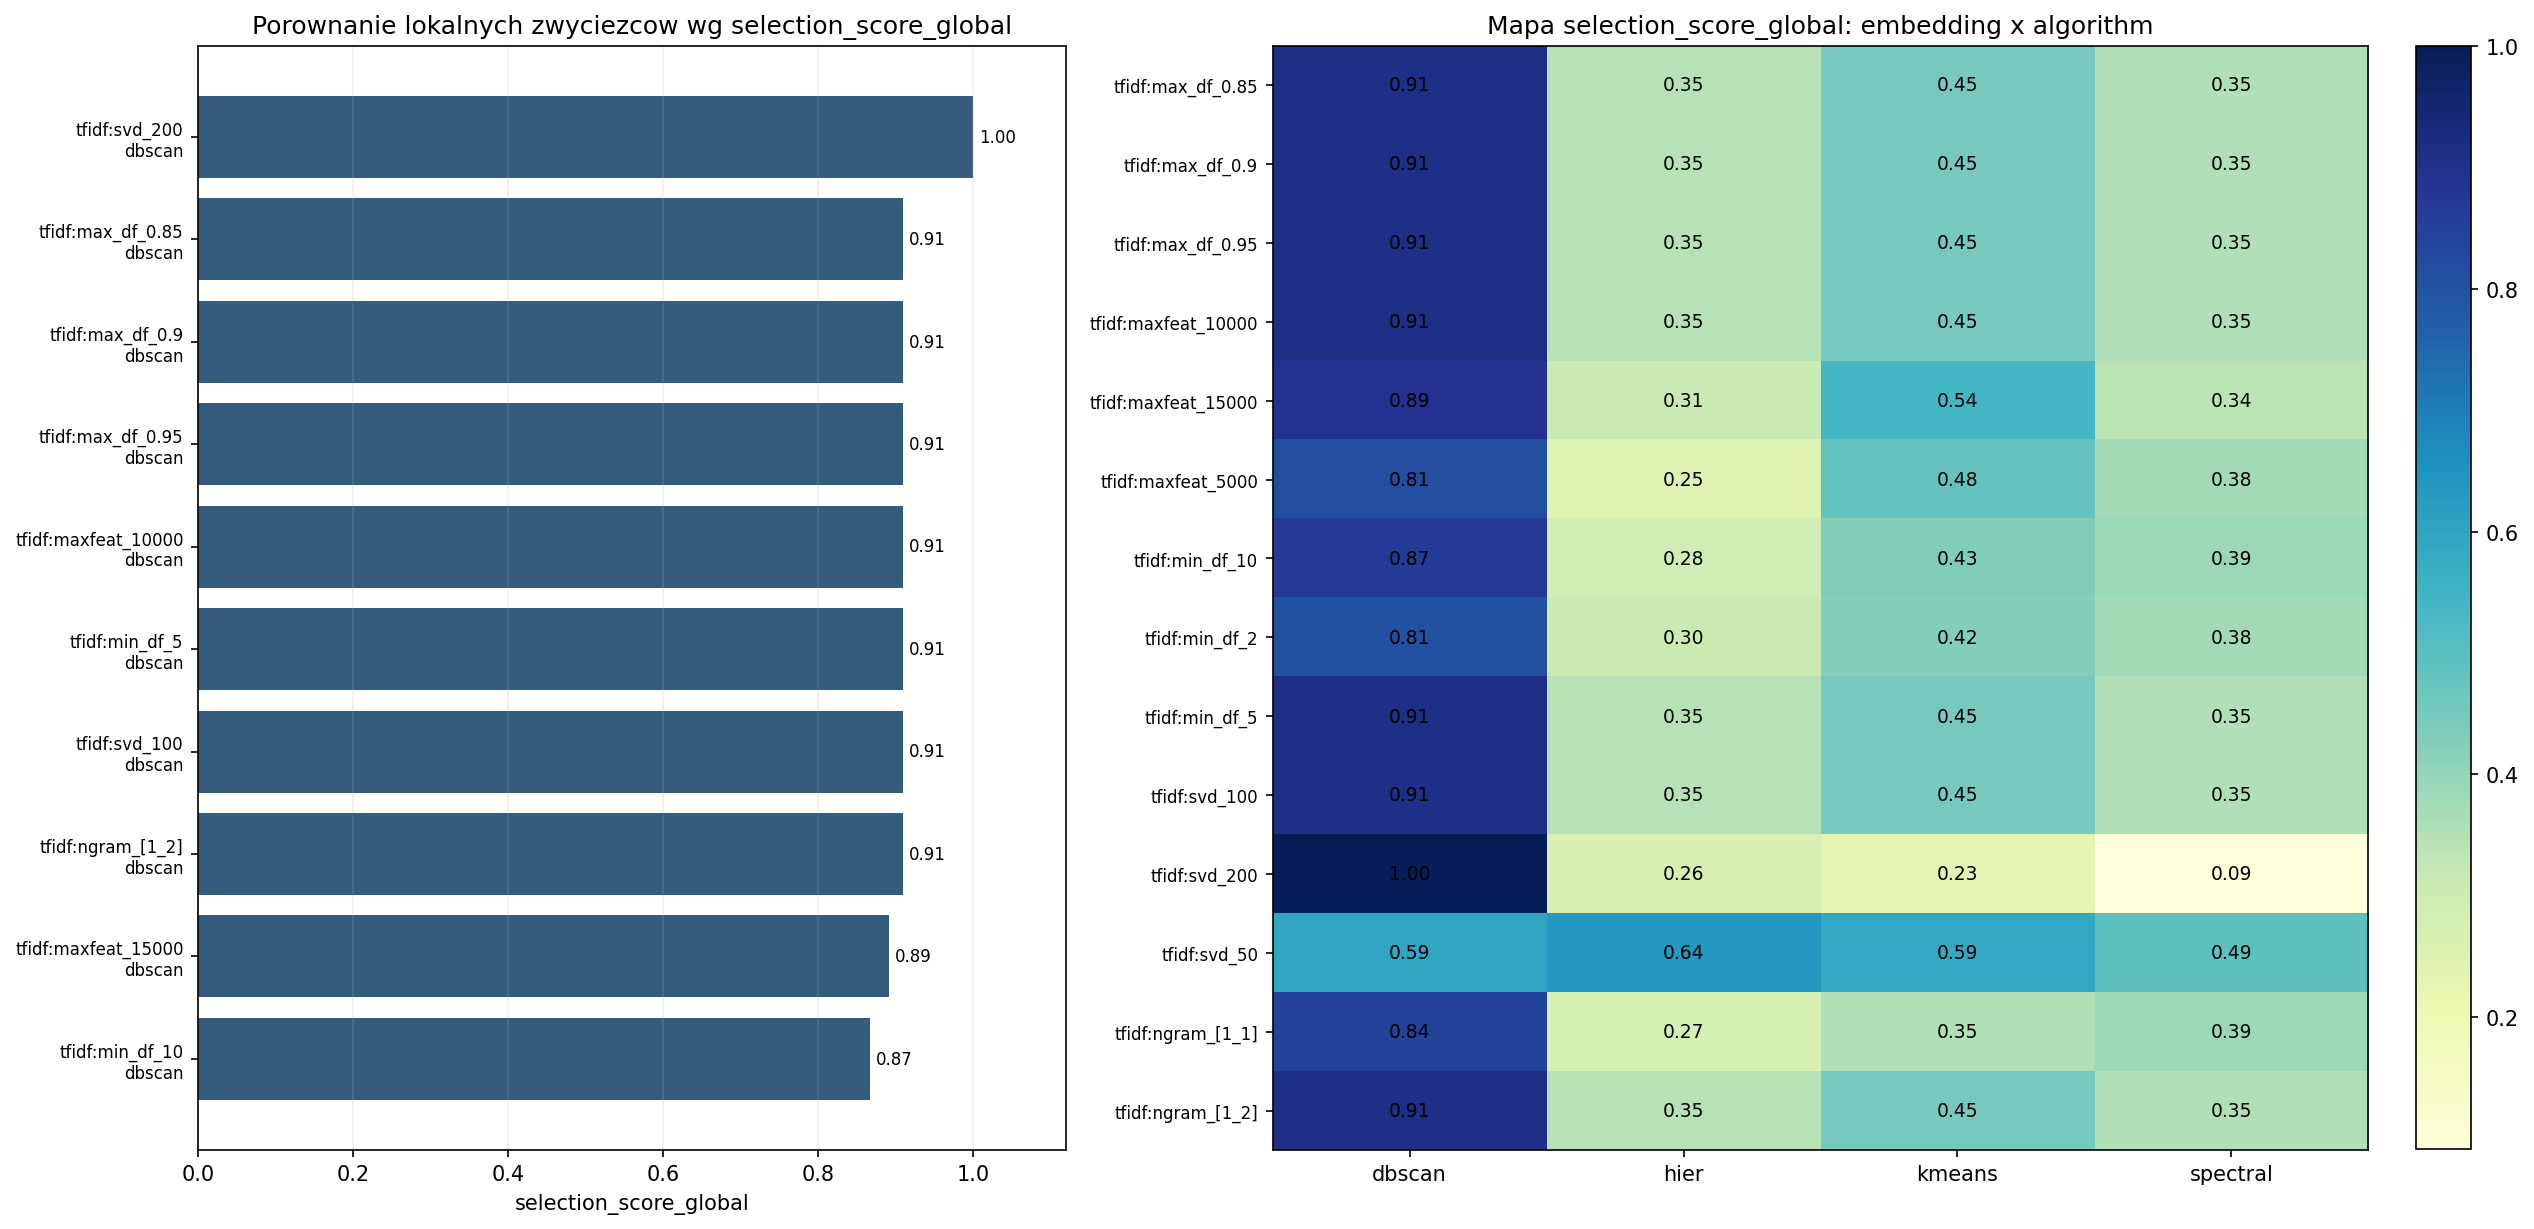

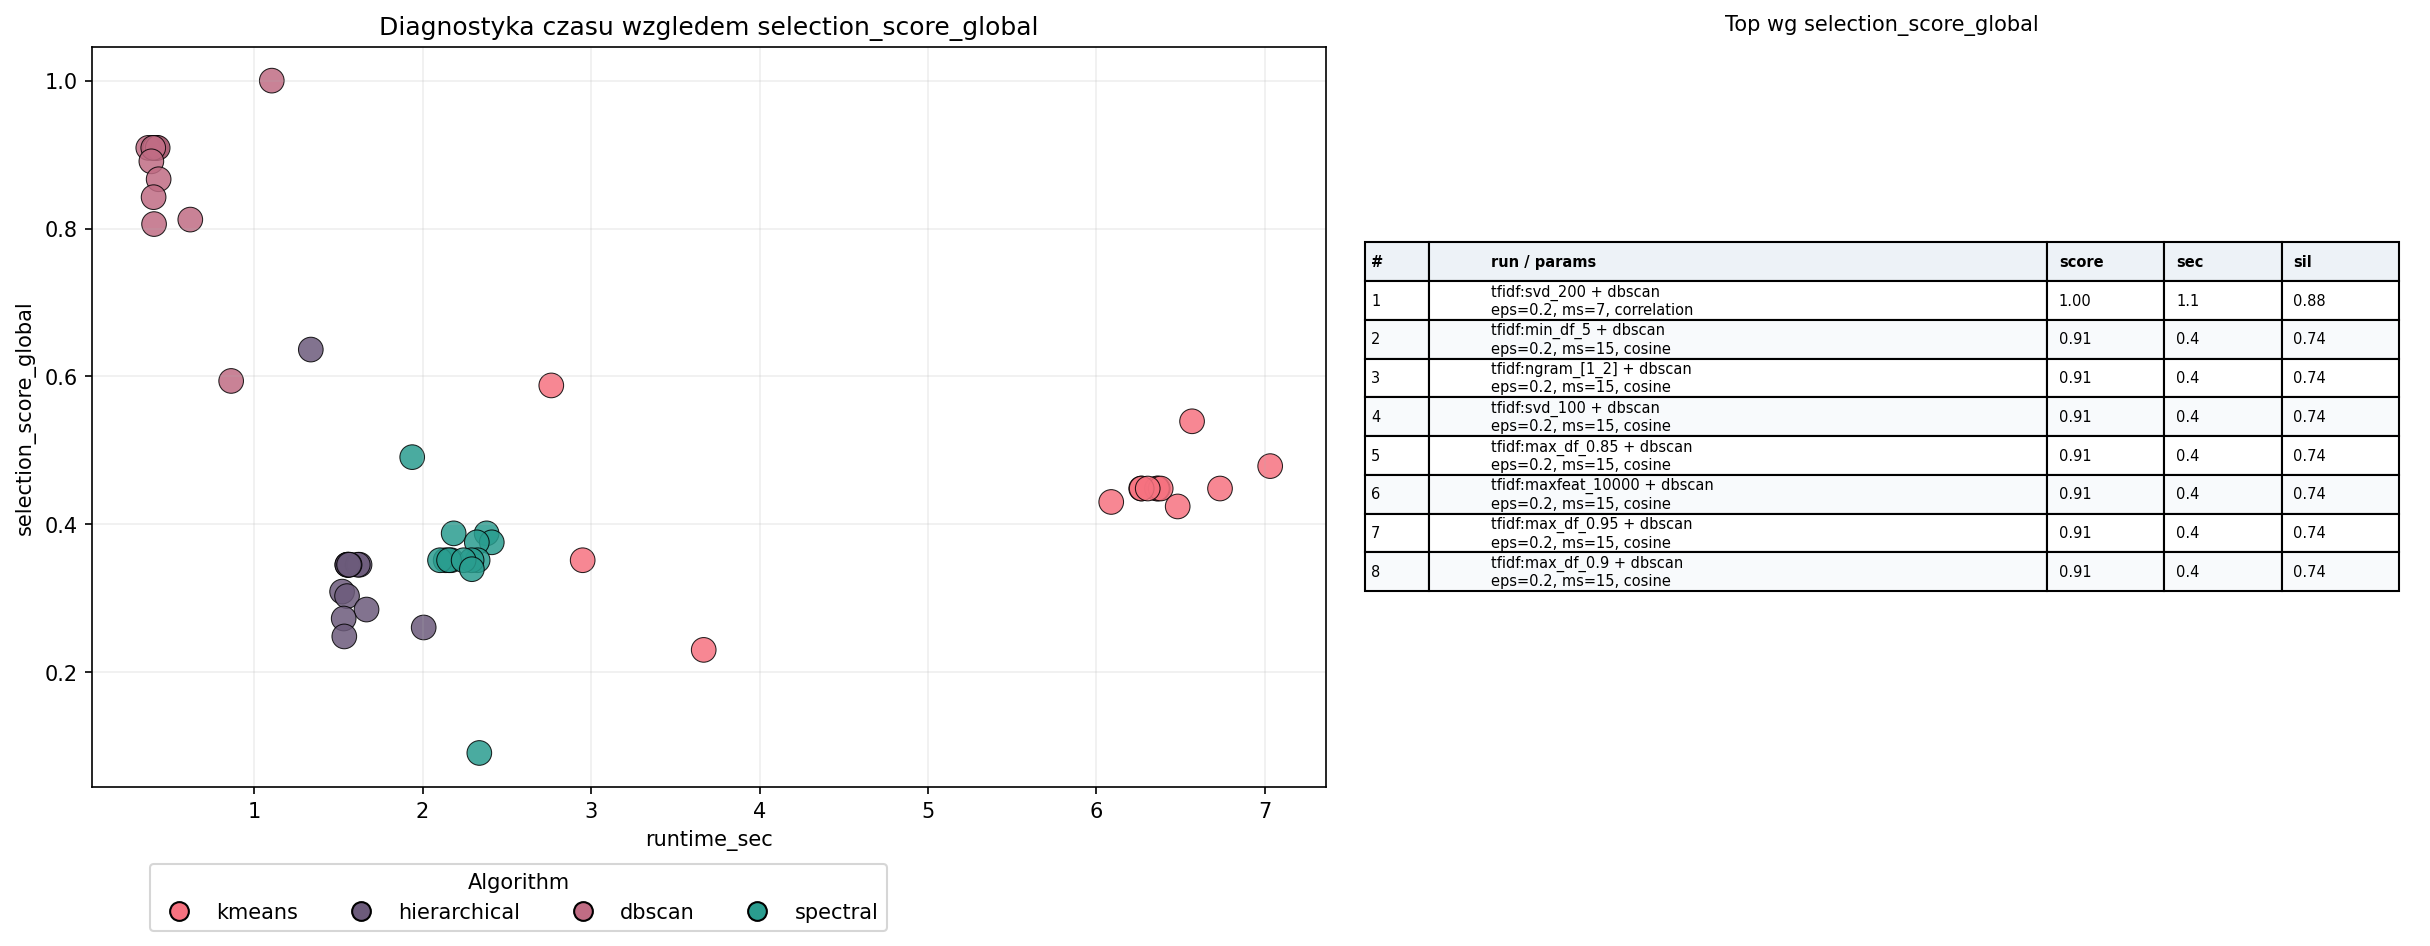


---
### Tabela 7A: `local_winners_table` — lokalni zwyciezcy hiperparametrow

Ta tabela odpowiada na pytanie: **ktory przebieg jest najlepszy wewnatrz danej pary `(embedding_name, algorithm)`?**

Do tego sluzy `selection_score_local`. Jest on liczony osobno w kazdej rodzinie modeli, wiec nadaje sie do wyboru hiperparametrow w tej rodzinie, ale nie do bezposredniego porownania roznych rodzin.


,embedding_name,embedding_label,algorithm,k,metric,linkage,selection_score_local,selection_score_global,silhouette_local_rank_score,dunn_local_rank_score,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,tfidf_var_max_df_0.85,Variation: max_df_0.85,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.407795,local=1.000; global=0.909; sil=0.738; db=0.787...
1,tfidf_var_max_df_0.85,Variation: max_df_0.85,hierarchical,30,euclidean,ward,0.797619,0.345455,1.000000,0.750000,...,0.200000,0.618182,0.218182,True,0.041708,3.370905,0.341199,0.131613,1.625865,local=0.798; global=0.345; sil=0.042; db=3.371...
2,tfidf_var_max_df_0.85,Variation: max_df_0.85,kmeans,30,euclidean,None,0.925926,0.448485,1.000000,0.888889,...,0.636364,0.363636,0.345455,True,0.072307,3.350551,0.257590,0.219919,6.265629,local=0.926; global=0.448; sil=0.072; db=3.351...
3,tfidf_var_max_df_0.85,Variation: max_df_0.85,spectral,30,cosine,None,0.813559,0.351515,0.559322,0.932203,...,0.327273,0.109091,0.618182,True,0.048964,2.999426,0.097773,0.103541,2.137121,local=0.814; global=0.352; sil=0.049; db=2.999...
4,tfidf_var_max_df_0.9,Variation: max_df_0.9,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.419709,local=1.000; global=0.909; sil=0.738; db=0.787...
5,tfidf_var_max_df_0.9,Variation: max_df_0.9,hierarchical,30,euclidean,ward,0.797619,0.345455,1.000000,0.750000,...,0.200000,0.618182,0.218182,True,0.041708,3.370905,0.341199,0.131613,1.553287,local=0.798; global=0.345; sil=0.042; db=3.371...
6,tfidf_var_max_df_0.9,Variation: max_df_0.9,kmeans,30,euclidean,None,0.925926,0.448485,1.000000,0.888889,...,0.636364,0.363636,0.345455,True,0.072307,3.350551,0.257590,0.219919,6.364594,local=0.926; global=0.448; sil=0.072; db=3.351...
7,tfidf_var_max_df_0.9,Variation: max_df_0.9,spectral,30,cosine,None,0.813559,0.351515,0.559322,0.932203,...,0.327273,0.109091,0.618182,True,0.048964,2.999426,0.097773,0.103541,2.169546,local=0.814; global=0.352; sil=0.049; db=2.999...
8,tfidf_var_max_df_0.95,Variation: max_df_0.95,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.402956,local=1.000; global=0.909; sil=0.738; db=0.787...
9,tfidf_var_max_df_0.95,Variation: max_df_0.95,hierarchical,30,euclidean,ward,0.797619,0.345455,1.000000,0.750000,...,0.200000,0.618182,0.218182,True,0.041708,3.370905,0.341199,0.131613,1.557165,local=0.798; global=0.345; sil=0.042; db=3.371...



---
### Tabela 7B: `global_candidates_ranking` — porownanie lokalnych zwyciezcow

Ta tabela odpowiada na inne pytanie: **ktory z lokalnych zwyciezcow wyglada najlepiej globalnie?**

Tutaj uzywamy `selection_score_global`, liczacego rank-score wspolnie na `best_runs_df`, czyli juz po wyborze lokalnych zwyciezcow. Dopiero ten wynik jest porownywalny miedzy parami embedding + algorytm.


,rank,embedding_name,embedding_label,algorithm,k,metric,linkage,selection_score_local,selection_score_global,silhouette_local_rank_score,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,1,tfidf_var_n_components_200,Variation: n_components_200,dbscan,-1,correlation,None,0.988584,1.000000,0.993151,...,1.000000,1.000000,1.000000,True,0.882400,0.429572,2.339854,1.000000,1.104860,local=0.989; global=1.000; sil=0.882; db=0.430...
1,2,tfidf_var_max_df_0.85,Variation: max_df_0.85,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.407795,local=1.000; global=0.909; sil=0.738; db=0.787...
2,3,tfidf_var_max_df_0.9,Variation: max_df_0.9,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.419709,local=1.000; global=0.909; sil=0.738; db=0.787...
3,4,tfidf_var_max_df_0.95,Variation: max_df_0.95,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.402956,local=1.000; global=0.909; sil=0.738; db=0.787...
4,5,tfidf_var_max_features_10000,Variation: max_features_10000,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.371624,local=1.000; global=0.909; sil=0.738; db=0.787...
5,6,tfidf_var_min_df_5,Variation: min_df_5,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.412219,local=1.000; global=0.909; sil=0.738; db=0.787...
6,7,tfidf_var_n_components_100,Variation: n_components_100,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.427514,local=1.000; global=0.909; sil=0.738; db=0.787...
7,8,tfidf_var_ngram_range_[1_2],Variation: ngram_range_[1_2],dbscan,-1,cosine,None,1.000000,0.909091,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.401330,local=1.000; global=0.909; sil=0.738; db=0.787...
8,9,tfidf_var_max_features_15000,Variation: max_features_15000,dbscan,-1,cosine,None,0.995556,0.890909,1.000000,...,0.854545,0.836364,0.981818,True,0.733641,0.779129,0.797773,0.608241,0.389931,local=0.996; global=0.891; sil=0.734; db=0.779...
9,10,tfidf_var_min_df_10,Variation: min_df_10,dbscan,-1,cosine,None,0.989035,0.866667,1.000000,...,0.836364,0.800000,0.963636,True,0.731947,0.783366,0.701238,0.625003,0.433262,local=0.989; global=0.867; sil=0.732; db=0.783...



---
### Tabela 7C: `best_embedding_per_algorithm` — najlepszy embedding dla kazdego algorytmu

Dla kazdego algorytmu wybieramy lokalnego zwyciezce z najwyzszym `selection_score_global`. To porownanie odbywa sie juz na wspolnej skali globalnej dla zwyciezcow.


,embedding_name,embedding_label,algorithm,k,metric,linkage,selection_score_local,selection_score_global,silhouette_local_rank_score,dunn_local_rank_score,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,tfidf_var_n_components_200,Variation: n_components_200,dbscan,-1,correlation,None,0.988584,1.000000,0.993151,0.993151,...,1.000000,1.000000,1.000000,True,0.882400,0.429572,2.339854,1.000000,1.104860,local=0.989; global=1.000; sil=0.882; db=0.430...
1,tfidf_var_n_components_50,Variation: n_components_50,hierarchical,30,euclidean,ward,0.880952,0.636364,1.000000,1.000000,...,0.727273,0.472727,0.709091,True,0.081181,2.692890,0.298553,0.188445,1.336483,local=0.881; global=0.636; sil=0.081; db=2.693...
2,tfidf_var_n_components_50,Variation: n_components_50,kmeans,30,euclidean,None,0.962963,0.587879,1.000000,0.888889,...,0.763636,0.254545,0.745455,True,0.115157,2.332016,0.172585,0.239841,2.763921,local=0.963; global=0.588; sil=0.115; db=2.332...
3,tfidf_var_n_components_50,Variation: n_components_50,spectral,30,cosine,None,0.946328,0.490909,1.000000,0.957627,...,0.745455,0.000000,0.727273,True,0.098343,2.458970,0.069986,0.216550,1.938376,local=0.946; global=0.491; sil=0.098; db=2.459...



---
### Tabela 7D: `best_algorithm_per_embedding` — najlepszy algorytm dla kazdego embeddingu

Dla kazdego embeddingu wybieramy algorytm z najwyzszym `selection_score_global`, czyli porownujemy tylko reprezentantow wybranych lokalnie.


,embedding_name,embedding_label,algorithm,k,metric,linkage,selection_score_local,selection_score_global,silhouette_local_rank_score,dunn_local_rank_score,...,silhouette_global_rank_score,dunn_global_rank_score,davies_bouldin_global_rank_score,pareto_front,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,tfidf_var_max_df_0.85,Variation: max_df_0.85,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.407795,local=1.000; global=0.909; sil=0.738; db=0.787...
1,tfidf_var_max_df_0.9,Variation: max_df_0.9,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.419709,local=1.000; global=0.909; sil=0.738; db=0.787...
2,tfidf_var_max_df_0.95,Variation: max_df_0.95,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.402956,local=1.000; global=0.909; sil=0.738; db=0.787...
3,tfidf_var_max_features_10000,Variation: max_features_10000,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.371624,local=1.000; global=0.909; sil=0.738; db=0.787...
4,tfidf_var_max_features_15000,Variation: max_features_15000,dbscan,-1,cosine,None,0.995556,0.890909,1.000000,0.986667,...,0.854545,0.836364,0.981818,True,0.733641,0.779129,0.797773,0.608241,0.389931,local=0.996; global=0.891; sil=0.734; db=0.779...
5,tfidf_var_max_features_5000,Variation: max_features_5000,dbscan,-1,correlation,None,0.991228,0.812121,1.000000,0.986842,...,0.818182,0.818182,0.800000,True,0.730311,0.789565,0.746715,0.625236,0.621017,local=0.991; global=0.812; sil=0.730; db=0.790...
6,tfidf_var_min_df_10,Variation: min_df_10,dbscan,-1,cosine,None,0.989035,0.866667,1.000000,0.967105,...,0.836364,0.800000,0.963636,True,0.731947,0.783366,0.701238,0.625003,0.433262,local=0.989; global=0.867; sil=0.732; db=0.783...
7,tfidf_var_min_df_2,Variation: min_df_2,dbscan,-1,cosine,None,1.000000,0.806061,1.000000,1.000000,...,0.781818,0.854545,0.781818,True,0.705784,0.859315,0.870940,0.456941,0.406083,local=1.000; global=0.806; sil=0.706; db=0.859...
8,tfidf_var_min_df_5,Variation: min_df_5,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.412219,local=1.000; global=0.909; sil=0.738; db=0.787...
9,tfidf_var_n_components_100,Variation: n_components_100,dbscan,-1,cosine,None,1.000000,0.909091,1.000000,1.000000,...,0.927273,0.927273,0.872727,True,0.737712,0.787448,0.944474,0.000000,0.427514,local=1.000; global=0.909; sil=0.738; db=0.787...


{'global_candidates_heatmap': 'artifacts_full/plots/section7_global_candidates_heatmap.png',
 'global_selection_runtime': 'artifacts_full/plots/section7_global_selection_runtime.png',
 'global_selection_runtime_interactive': 'artifacts_full/plots/section7_global_selection_runtime_interactive.html'}

In [29]:
from IPython.display import Markdown

best_runs_df = select_best_runs(results_df)
best_runs_df = add_dunn_scores(
    best_runs_df=best_runs_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

comparison_views = build_comparison_views(best_runs_df)
plot_paths = create_best_runs_plots(best_runs_df, CONFIG)
print(summarize_best_runs(best_runs_df))
display_best_runs_plots(plot_paths)

display(Markdown("""
---
### Tabela 7A: `local_winners_table` — lokalni zwyciezcy hiperparametrow

Ta tabela odpowiada na pytanie: **ktory przebieg jest najlepszy wewnatrz danej pary `(embedding_name, algorithm)`?**

Do tego sluzy `selection_score_local`. Jest on liczony osobno w kazdej rodzinie modeli, wiec nadaje sie do wyboru hiperparametrow w tej rodzinie, ale nie do bezposredniego porownania roznych rodzin.
"""))
display(comparison_views["local_winners_table"])

display(Markdown("""
---
### Tabela 7B: `global_candidates_ranking` — porownanie lokalnych zwyciezcow

Ta tabela odpowiada na inne pytanie: **ktory z lokalnych zwyciezcow wyglada najlepiej globalnie?**

Tutaj uzywamy `selection_score_global`, liczacego rank-score wspolnie na `best_runs_df`, czyli juz po wyborze lokalnych zwyciezcow. Dopiero ten wynik jest porownywalny miedzy parami embedding + algorytm.
"""))
display(comparison_views["global_candidates_ranking"])

display(Markdown("""
---
### Tabela 7C: `best_embedding_per_algorithm` — najlepszy embedding dla kazdego algorytmu

Dla kazdego algorytmu wybieramy lokalnego zwyciezce z najwyzszym `selection_score_global`. To porownanie odbywa sie juz na wspolnej skali globalnej dla zwyciezcow.
"""))
display(comparison_views["best_embedding_per_algorithm"])

display(Markdown("""
---
### Tabela 7D: `best_algorithm_per_embedding` — najlepszy algorytm dla kazdego embeddingu

Dla kazdego embeddingu wybieramy algorytm z najwyzszym `selection_score_global`, czyli porownujemy tylko reprezentantow wybranych lokalnie.
"""))
display(comparison_views["best_algorithm_per_embedding"])
plot_paths


## 8. Czesc interpretacyjna klastrow

Metryki globalne nie wystarczaja do zrozumienia, co model rzeczywiscie pogrupowal. Dlatego interpretujemy klastry wielotorowo i rozdzielamy sygnaly nienadzorowane od diagnostyki etykietowej.

W tej sekcji wykorzystujemy:

1. **Opis leksykalny klastra**: najczestsze slowa, slowa odrozniajace oraz WordCloud.
2. **Interpretacje geometryczna**: dokumenty centralne i graniczne.
3. **Diagnostyke etykiet post-hoc**: dominujaca etykieta, purity i entropia etykiet.
4. **Diagnostyke strukturalna**: rozmiar klastra, udzial w zbiorze, singletony/male klastry i klastry gigantyczne.

Purity i entropia sa przydatne, ale wymagaja ostroznosci. Purity `1.0` w klastrze jednoelementowym nie jest dowodem dobrego modelu, tylko skutkiem malego rozmiaru. Dlatego listy „najczystszych” klastrów filtrujemy przez minimalny rozmiar, a globalnie raportujemy zarowno metryki wazone rozmiarem klastra, jak i makro-metryki pokazujace fragmentacje.

`ARI`, purity i entropia nie wplywaja na wybor `best_runs`; sluza do interpretacji zgodnosci z kategoriami `20 Newsgroups` po wyborze modelu.


In [30]:
def explain_best_runs(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> Tuple[pd.DataFrame, List[Dict[str, Any]], pd.DataFrame]:
    profile_rows: List[Dict[str, Any]] = []
    cluster_examples: List[Dict[str, Any]] = []
    run_summary_rows: List[Dict[str, Any]] = []
    min_cluster_size = int(config.get("wordcloud_min_cluster_size", 10))

    for _, row in best_runs_df.iterrows():
        subset_name = row["algorithm"] if row["algorithm"] in dataset_views else "kmeans"
        embedding_view = embedding_views[row["embedding_name"]]
        X, fit_df = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        model, labels = refit_model(X=X, params=params, seed=config["seed"])
        run_profiles, run_examples = interpret_single_run(
            fit_df=fit_df,
            X=X,
            labels=labels,
            model=model,
            row=row,
            top_terms=int(config["explain_top_terms"]),
            top_docs=int(config["explain_top_docs"]),
            max_features=int(config["interpretation_max_features"]),
            min_cluster_size=min_cluster_size,
        )
        profile_rows.extend(run_profiles)
        cluster_examples.extend(run_examples)

        run_summary_rows.extend(
            summarize_run_interpretation(
                run_profiles=run_profiles,
                run_row=row,
            )
        )

    profiles_df = pd.DataFrame(profile_rows)
    run_summary_df = pd.DataFrame(run_summary_rows)
    return profiles_df, cluster_examples, run_summary_df


def refit_model(
    X: np.ndarray, params: Dict[str, Any], seed: int
) -> Tuple[Any, np.ndarray]:
    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
    elif params["algorithm"] == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
    elif params["algorithm"] == "dbscan":
        model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], metric=params["metric"])
    else:
        model = SpectralClustering(
            n_clusters=params["k"], random_state=seed, affinity=params["affinity"],
            assign_labels=params["assign_labels"], n_neighbors=params.get("n_neighbors", 10),
        )
    labels = model.fit_predict(X)
    return model, labels


def interpret_single_run(
    fit_df: pd.DataFrame,
    X: np.ndarray,
    labels: np.ndarray,
    model: Any,
    row: pd.Series,
    top_terms: int,
    top_docs: int,
    max_features: int,
    min_cluster_size: int,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    texts = fit_df["analysis_text"].fillna("").replace("", "emptytoken").tolist()
    count_vectorizer = CountVectorizer(max_features=max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
    count_matrix = count_vectorizer.fit_transform(texts)
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    count_vocab = np.array(count_vectorizer.get_feature_names_out())
    tfidf_vocab = np.array(tfidf_vectorizer.get_feature_names_out())
    n_docs = max(int(len(fit_df)), 1)
    n_unique_targets_global = max(int(fit_df["target_name"].nunique()), 1)
    max_entropy = math.log2(n_unique_targets_global) if n_unique_targets_global > 1 else 1.0

    profiles: List[Dict[str, Any]] = []
    examples: List[Dict[str, Any]] = []

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        outside_mask = ~cluster_mask
        cluster_size = int(cluster_mask.sum())
        cluster_share = float(cluster_size / n_docs)

        mean_counts = np.asarray(count_matrix[cluster_mask].mean(axis=0)).ravel()
        frequent_idx = np.argsort(mean_counts)[::-1][:top_terms]
        frequent_words = [word for word in count_vocab[frequent_idx] if mean_counts.any()]

        mean_tfidf_cluster = np.asarray(tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
        if outside_mask.sum() > 0:
            mean_tfidf_outside = np.asarray(tfidf_matrix[outside_mask].mean(axis=0)).ravel()
        else:
            mean_tfidf_outside = np.zeros_like(mean_tfidf_cluster)
        distinctive_scores = mean_tfidf_cluster - mean_tfidf_outside
        distinctive_idx = np.argsort(distinctive_scores)[::-1][:top_terms]
        distinctive_words = [
            word for word in tfidf_vocab[distinctive_idx] if distinctive_scores.any()
        ]

        label_stats = compute_target_label_stats(
            target_names=fit_df.loc[cluster_mask, "target_name"].astype(str),
            max_entropy=max_entropy,
        )
        target_entropy_normalized = label_stats["target_entropy_normalized"]
        is_tiny_cluster = cluster_size < min_cluster_size
        is_giant_cluster = cluster_share > 0.50
        is_label_pure = (
            cluster_size >= min_cluster_size
            and pd.notna(label_stats["dominant_target_share"])
            and label_stats["dominant_target_share"] >= 0.65
        )
        is_mixed_cluster = (
            pd.notna(target_entropy_normalized)
            and target_entropy_normalized >= 0.75
        )

        central_indices, boundary_indices = representative_doc_indices(
            X=X,
            labels=labels,
            cluster_id=int(cluster_id),
            model=model,
            algorithm=row["algorithm"],
            metric=row["metric"],
            top_docs=top_docs,
        )

        representative_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=central_indices,
            role="central",
        )
        boundary_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=boundary_indices,
            role="boundary",
        )

        interpretation_note = build_cluster_note(
            cluster_size=cluster_size,
            cluster_share=cluster_share,
            label_stats=label_stats,
            frequent_words=frequent_words,
            distinctive_words=distinctive_words,
            is_tiny_cluster=is_tiny_cluster,
            is_giant_cluster=is_giant_cluster,
            is_mixed_cluster=is_mixed_cluster,
        )

        profiles.append(
            {
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "cluster_size": cluster_size,
                "cluster_share": cluster_share,
                "top_frequent_words": ", ".join(frequent_words),
                "top_distinctive_words": ", ".join(distinctive_words),
                "dominant_target": label_stats["dominant_target"],
                "dominant_target_share": label_stats["dominant_target_share"],
                "target_entropy": label_stats["target_entropy"],
                "target_entropy_normalized": target_entropy_normalized,
                "top_targets": label_stats["top_targets"],
                "is_tiny_cluster": bool(is_tiny_cluster),
                "is_giant_cluster": bool(is_giant_cluster),
                "is_label_pure": bool(is_label_pure),
                "is_mixed_cluster": bool(is_mixed_cluster),
                "interpretation_note": interpretation_note,
            }
        )
        examples.append(
            {
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "central_documents": representative_docs,
                "boundary_documents": boundary_docs,
            }
        )

    return profiles, examples


def representative_doc_indices(
    X: np.ndarray,
    labels: np.ndarray,
    cluster_id: int,
    model: Any,
    algorithm: str,
    metric: str,
    top_docs: int,
) -> Tuple[List[int], List[int]]:
    cluster_indices = np.where(labels == cluster_id)[0]
    if len(cluster_indices) == 0:
        return [], []

    if algorithm == "kmeans":
        distances = model.transform(X[cluster_indices])[:, cluster_id]
        ordered = cluster_indices[np.argsort(distances)]
    elif algorithm == "dbscan":
        cluster_vectors = X[cluster_indices]
        nn = NearestNeighbors(radius=model.eps, metric=metric)
        nn.fit(cluster_vectors)
        neighbors = nn.radius_neighbors(cluster_vectors, return_distance=False)
        densities = np.array([len(n) for n in neighbors])
        ordered = cluster_indices[np.argsort(-densities)]
    else:
        cluster_vectors = X[cluster_indices]
        dist_matrix = pairwise_distances(cluster_vectors, metric=metric)
        centrality = dist_matrix.mean(axis=1)
        ordered = cluster_indices[np.argsort(centrality)]

    docs_per_role = min(top_docs, len(ordered) // 2)
    if docs_per_role == 0:
        return ordered[:1].tolist(), []

    central = ordered[:docs_per_role].tolist()
    boundary = ordered[-docs_per_role:][::-1].tolist()
    return central, boundary


def build_doc_records(
    fit_df: pd.DataFrame,
    local_indices: List[int],
    role: str,
) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []
    for local_idx in local_indices:
        record = fit_df.iloc[local_idx]
        records.append(
            {
                "role": role,
                "doc_id": int(record["doc_id"]),
                "target_name": str(record["target_name"]),
                "excerpt": truncate_text(record["text_clean_basic"]),
            }
        )
    return records


def compute_target_label_stats(target_names: pd.Series, max_entropy: float) -> Dict[str, Any]:
    label_counts = target_names.value_counts()
    total = int(label_counts.sum())
    if total == 0:
        return {
            "dominant_target": "unknown",
            "dominant_target_share": float("nan"),
            "target_entropy": float("nan"),
            "target_entropy_normalized": float("nan"),
            "top_targets": "",
        }

    probs = (label_counts / total).to_numpy(dtype=float)
    entropy = max(0.0, float(-(probs * np.log2(probs + 1e-12)).sum()))
    normalized_entropy = float(min(1.0, entropy / max_entropy)) if max_entropy > 0 else float("nan")

    dominant_target = str(label_counts.index[0])
    dominant_share = float(label_counts.iloc[0] / total)
    top_targets = ", ".join(
        [f"{name}:{count}" for name, count in label_counts.head(3).items()]
    )

    return {
        "dominant_target": dominant_target,
        "dominant_target_share": dominant_share,
        "target_entropy": entropy,
        "target_entropy_normalized": normalized_entropy,
        "top_targets": top_targets,
    }


def build_cluster_note(
    cluster_size: int,
    cluster_share: float,
    label_stats: Dict[str, Any],
    frequent_words: List[str],
    distinctive_words: List[str],
    is_tiny_cluster: bool,
    is_giant_cluster: bool,
    is_mixed_cluster: bool,
) -> str:
    lexical_hint = ", ".join(distinctive_words[:4] if distinctive_words else frequent_words[:4])
    if not lexical_hint:
        lexical_hint = "brak wyraznych tokenow"

    purity = label_stats["dominant_target_share"]
    if pd.isna(purity):
        purity_desc = "nieznana zgodnosc etykiet"
    elif is_tiny_cluster:
        purity_desc = "purity malo informacyjne (maly klaster)"
    elif purity >= 0.65:
        purity_desc = "wysoka zgodnosc etykiet post-hoc"
    elif purity >= 0.45:
        purity_desc = "srednia zgodnosc etykiet post-hoc"
    else:
        purity_desc = "niska zgodnosc etykiet post-hoc"

    structure_notes = []
    if is_giant_cluster:
        structure_notes.append("klaster gigantyczny")
    if is_mixed_cluster:
        structure_notes.append("wysoka entropia etykiet")
    structure_suffix = f"; {'; '.join(structure_notes)}" if structure_notes else ""

    return (
        f"Klaster {cluster_size} docs ({cluster_share:.1%}); dominant='{label_stats['dominant_target']}' "
        f"({purity:.2f}) - {purity_desc}{structure_suffix}; sygnatura: {lexical_hint}."
    )


def summarize_run_interpretation(
    run_profiles: List[Dict[str, Any]],
    run_row: pd.Series,
) -> List[Dict[str, Any]]:
    if not run_profiles:
        return []

    run_df = pd.DataFrame(run_profiles)
    total_docs = float(run_df["cluster_size"].sum())
    top_by_size = run_df.sort_values("cluster_size", ascending=False).head(3)
    purity_candidates = run_df[~run_df["is_tiny_cluster"]]
    if purity_candidates.empty:
        purity_candidates = run_df.iloc[0:0]
    top_by_purity = purity_candidates.sort_values(
        ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
        ascending=[False, False, True],
    ).head(3)

    weighted_purity = float((run_df["dominant_target_share"] * run_df["cluster_size"]).sum() / total_docs)
    weighted_entropy = float((run_df["target_entropy"] * run_df["cluster_size"]).sum() / total_docs)
    weighted_normalized_entropy = float((run_df["target_entropy_normalized"] * run_df["cluster_size"]).sum() / total_docs)
    tiny_doc_count = float(run_df.loc[run_df["is_tiny_cluster"], "cluster_size"].sum())

    summary = {
        "embedding_name": run_row["embedding_name"],
        "algorithm": run_row["algorithm"],
        "k": int(run_row["k"]),
        "best_clusters_by_size": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_size.itertuples()
            ]
        ),
        "best_clusters_by_purity": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_purity.itertuples()
            ]
        ) if not top_by_purity.empty else "Brak klastrow powyzej minimalnego rozmiaru.",
        "weighted_purity": weighted_purity,
        "macro_purity": float(run_df["dominant_target_share"].mean()),
        "weighted_entropy": weighted_entropy,
        "macro_entropy": float(run_df["target_entropy"].mean()),
        "weighted_normalized_entropy": weighted_normalized_entropy,
        "macro_normalized_entropy": float(run_df["target_entropy_normalized"].mean()),
        "tiny_cluster_count": int(run_df["is_tiny_cluster"].sum()),
        "tiny_cluster_doc_share": float(tiny_doc_count / total_docs),
        "largest_cluster_share": float(run_df["cluster_share"].max()),
        "selection_score_global": float(run_row["selection_score_global"]) if "selection_score_global" in run_row.index else float("nan"),
        "ari": float(run_row["ari"]) if "ari" in run_row.index else float("nan"),
    }
    return [summary]


def sort_interpretation_runs(run_summary_df: pd.DataFrame, top_runs: int) -> pd.DataFrame:
    return (
        run_summary_df
        .sort_values(
            ["selection_score_global", "weighted_normalized_entropy", "weighted_purity"],
            ascending=[False, True, False],
        )
        .head(top_runs)
        .reset_index(drop=True)
    )


def format_interpretation_markdown(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
    min_cluster_size: int = 10,
) -> str:
    if run_summary_df.empty:
        return "Brak danych do interpretacji."

    top_rows = sort_interpretation_runs(run_summary_df, top_runs=top_runs)
    criteria_note = (
        f"Top {top_runs} przebiegow wybranych wg `selection_score_global` z sekcji 7. "
        "Purity, entropia i ARI sa raportowane jako diagnostyka post-hoc, bez wplywu na wybor."
    )

    lines: List[str] = [
        "## Raport interpretacyjny klastrow (best runs)",
        "",
        f"> **Kryteria wyboru:** {criteria_note}",
        "",
    ]

    for rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        run_name = f"{row.embedding_name} + {row.algorithm} (k={int(row.k)})"
        lines.append(f"### {rank}. {run_name}")
        lines.append("")
        lines.append(
            f"**Selection:** selection_score_global={row.selection_score_global:.3f} | "
            f"ARI post-hoc={row.ari:.3f}"
        )
        lines.append(
            f"**Etykiety post-hoc:** weighted_purity={row.weighted_purity:.3f} | "
            f"weighted_entropy_norm={row.weighted_normalized_entropy:.3f} | "
            f"macro_purity={row.macro_purity:.3f}"
        )
        lines.append(
            f"**Struktura:** largest_cluster_share={row.largest_cluster_share:.3f} | "
            f"tiny_clusters={int(row.tiny_cluster_count)} | "
            f"tiny_doc_share={row.tiny_cluster_doc_share:.3f}"
        )
        lines.append("")
        lines.append(f"- Najwieksze klastry: {row.best_clusters_by_size}")
        lines.append(f"- Najczystsze klastry (cluster_size >= {min_cluster_size}): {row.best_clusters_by_purity}")
        lines.append("")

        run_profiles = (
            cluster_profiles_df[
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(3)
        )

        lines.append("**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**")
        lines.append("")
        if run_profiles.empty:
            lines.append("Brak klastrow spelniajacych minimalny rozmiar.")
        else:
            lines.append("| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |")
            lines.append("|---:|---:|---:|---|---:|---:|---|")
            for profile in run_profiles.itertuples(index=False):
                flags = []
                if profile.is_label_pure:
                    flags.append("label_pure")
                if profile.is_mixed_cluster:
                    flags.append("mixed")
                if profile.is_giant_cluster:
                    flags.append("giant")
                lines.append(
                    f"| {int(profile.cluster_id)} | {int(profile.cluster_size)} | "
                    f"{profile.cluster_share:.3f} | {profile.dominant_target} | "
                    f"{profile.dominant_target_share:.3f} | {profile.target_entropy_normalized:.3f} | "
                    f"{', '.join(flags) if flags else 'ok'} |"
                )
        lines.append("")

        selected_cluster_ids = [int(x) for x in run_profiles["cluster_id"].head(2).tolist()]
        related_examples = [
            item for item in cluster_examples
            if item["embedding_name"] == row.embedding_name
            and item["algorithm"] == row.algorithm
            and item["k"] == int(row.k)
            and int(item["cluster_id"]) in selected_cluster_ids
        ]
        related_examples = sorted(related_examples, key=lambda x: x["cluster_id"])

        lines.append("**Przykladowe dokumenty (centralne i graniczne):**")
        lines.append("")
        for example in related_examples:
            lines.append(f"- Cluster {example['cluster_id']}")
            lines.append("  - Centralne:")
            for doc in example["central_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
            lines.append("  - Graniczne:")
            for doc in example["boundary_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
        lines.append("")
        lines.append("---")
        lines.append("")

    return "\n".join(lines)


def build_examples_dataframe(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
    clusters_per_run: int = 2,
    docs_per_role: int = 2,
    min_cluster_size: int = 10,
) -> pd.DataFrame:
    if run_summary_df.empty:
        return pd.DataFrame()

    top_rows = sort_interpretation_runs(run_summary_df, top_runs=top_runs)
    rows: List[Dict[str, Any]] = []
    for run_rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        run_profiles = (
            cluster_profiles_df[
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(clusters_per_run)
        )
        selected_cluster_ids = {int(x) for x in run_profiles["cluster_id"].tolist()}

        related_examples = [
            item for item in cluster_examples
            if item["embedding_name"] == row.embedding_name
            and item["algorithm"] == row.algorithm
            and item["k"] == int(row.k)
            and int(item["cluster_id"]) in selected_cluster_ids
        ]

        for example in sorted(related_examples, key=lambda x: x["cluster_id"]):
            for role_key, role_label in [
                ("central_documents", "central"),
                ("boundary_documents", "boundary"),
            ]:
                for doc_rank, doc in enumerate(example[role_key][:docs_per_role], start=1):
                    rows.append(
                        {
                            "run_rank": run_rank,
                            "embedding": row.embedding_name,
                            "algorithm": row.algorithm,
                            "k": int(row.k),
                            "selection_score_global": float(row.selection_score_global),
                            "cluster_id": int(example["cluster_id"]),
                            "doc_role": role_label,
                            "doc_rank": doc_rank,
                            "doc_id": int(doc["doc_id"]),
                            "target_name": str(doc["target_name"]),
                            "excerpt": str(doc["excerpt"]),
                        }
                    )

    if not rows:
        return pd.DataFrame()

    examples_df = pd.DataFrame(rows)
    return examples_df.sort_values(
        ["run_rank", "cluster_id", "doc_role", "doc_rank"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)


def sanitize_filename_part(value: Any) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def wordcloud_stopwords() -> set:
    try:
        nltk_stopwords = set(stopwords.words("english"))
    except LookupError:
        nltk_stopwords = set()
    return set(STOPWORDS) | nltk_stopwords | {"emptytoken"}


def generate_wordcloud_artifacts(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    best_runs_df: pd.DataFrame,
    config: Dict[str, Any],
) -> pd.DataFrame:
    if run_summary_df.empty or cluster_profiles_df.empty:
        return pd.DataFrame()

    artifact_dir = Path(config["artifact_dir"])
    wordcloud_dir = artifact_dir / "plots" / "wordclouds"
    wordcloud_dir.mkdir(parents=True, exist_ok=True)

    top_runs = sort_interpretation_runs(
        run_summary_df,
        top_runs=int(config.get("wordcloud_top_runs", 3)),
    )
    min_cluster_size = int(config.get("wordcloud_min_cluster_size", 10))
    stop_words = wordcloud_stopwords()
    rows: List[Dict[str, Any]] = []

    for run_rank, run_row in enumerate(top_runs.itertuples(index=False), start=1):
        selected_run = best_runs_df[
            (best_runs_df["embedding_name"] == run_row.embedding_name)
            & (best_runs_df["algorithm"] == run_row.algorithm)
            & (best_runs_df["k"] == int(run_row.k))
        ].iloc[0]
        subset_name = selected_run["algorithm"] if selected_run["algorithm"] in dataset_views else "kmeans"
        embedding_view = embedding_views[selected_run["embedding_name"]]
        X, fit_df = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(selected_run)
        _, labels = refit_model(X=X, params=params, seed=config["seed"])

        run_clusters = (
            cluster_profiles_df[
                (cluster_profiles_df["embedding_name"] == run_row.embedding_name)
                & (cluster_profiles_df["algorithm"] == run_row.algorithm)
                & (cluster_profiles_df["k"] == int(run_row.k))
                & (cluster_profiles_df["cluster_size"] >= min_cluster_size)
            ]
            .sort_values(
                ["dominant_target_share", "cluster_size", "target_entropy_normalized"],
                ascending=[False, False, True],
            )
            .head(int(config.get("wordcloud_clusters_per_run", 2)))
        )

        for cluster in run_clusters.itertuples(index=False):
            cluster_id = int(cluster.cluster_id)
            cluster_text = " ".join(
                fit_df.loc[labels == cluster_id, "analysis_text"].fillna("").astype(str).tolist()
            ).strip()
            if not cluster_text:
                continue

            filename = (
                f"wordcloud_{run_rank:02d}_"
                f"{sanitize_filename_part(run_row.embedding_name)}_"
                f"{sanitize_filename_part(run_row.algorithm)}_"
                f"k{int(run_row.k)}_cluster{cluster_id}.png"
            )
            output_path = wordcloud_dir / filename
            cloud = WordCloud(
                width=int(config.get("wordcloud_width", 1200)),
                height=int(config.get("wordcloud_height", 700)),
                max_words=int(config.get("wordcloud_max_words", 80)),
                background_color="white",
                stopwords=stop_words,
                collocations=False,
                random_state=int(config["seed"]),
            ).generate(cluster_text)
            cloud.to_file(str(output_path))

            rows.append(
                {
                    "run_rank": run_rank,
                    "embedding_name": run_row.embedding_name,
                    "algorithm": run_row.algorithm,
                    "k": int(run_row.k),
                    "cluster_id": cluster_id,
                    "cluster_size": int(cluster.cluster_size),
                    "cluster_share": float(cluster.cluster_share),
                    "dominant_target": str(cluster.dominant_target),
                    "dominant_target_share": float(cluster.dominant_target_share),
                    "target_entropy_normalized": float(cluster.target_entropy_normalized),
                    "wordcloud_path": str(output_path),
                }
            )

    return pd.DataFrame(rows)


def display_wordclouds(wordcloud_index_df: pd.DataFrame) -> None:
    if wordcloud_index_df.empty:
        return

    from IPython.display import Image, Markdown, display

    display(Markdown("---\n### WordCloud dla top klastrow"))
    for row in wordcloud_index_df.itertuples(index=False):
        display(Markdown(
            f"**{row.embedding_name} + {row.algorithm}, k={int(row.k)}, "
            f"cluster={int(row.cluster_id)}** | size={int(row.cluster_size)} | "
            f"dominant={row.dominant_target} ({row.dominant_target_share:.3f})"
        ))
        display(Image(filename=row.wordcloud_path))


def truncate_text(text: str, length: int = 260) -> str:
    clean = clean_text_basic(text)
    if len(clean) <= length:
        return clean
    return clean[: length - 3] + "..."


Filtered 2 documents with empty representation for embedding=tfidf_var_max_df_0.85
Filtered 2 documents with empty representation for embedding=tfidf_var_max_df_0.9
Filtered 2 documents with empty representation for embedding=tfidf_var_max_df_0.95
Filtered 2 documents with empty representation for embedding=tfidf_var_max_features_10000
Filtered 2 documents with empty representation for embedding=tfidf_var_max_features_15000
Filtered 3 documents with empty representation for embedding=tfidf_var_max_features_5000
Filtered 1 documents with empty representation for embedding=tfidf_var_max_features_5000
Filtered 2 documents with empty representation for embedding=tfidf_var_min_df_10
Filtered 2 documents with empty representation for embedding=tfidf_var_min_df_2
Filtered 2 documents with empty representation for embedding=tfidf_var_min_df_5
Filtered 2 documents with empty representation for embedding=tfidf_var_n_components_100
Filtered 2 documents with empty representation for embedding=tfid


---
### Tabela A: `interpretation_runs_df` — diagnostyka przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking sortowany malejąco po `selection_score_global`, a metryki etykietowe są diagnostyką post-hoc.

Kluczowe pola:
- `selection_score_global`: nienadzorowane kryterium wyboru z sekcji 7,
- `weighted_purity` i `weighted_normalized_entropy`: globalna zgodność z etykietami, ważona rozmiarem klastrów,
- `macro_purity` i `macro_normalized_entropy`: diagnostyka fragmentacji,
- `tiny_cluster_count`, `tiny_cluster_doc_share`, `largest_cluster_share`: diagnostyka struktury podziału.


,embedding_name,algorithm,k,best_clusters_by_size,best_clusters_by_purity,weighted_purity,macro_purity,weighted_entropy,macro_entropy,weighted_normalized_entropy,macro_normalized_entropy,tiny_cluster_count,tiny_cluster_doc_share,largest_cluster_share,selection_score_global,ari
0,tfidf_var_n_components_200,dbscan,-1,#-1 size=2978 dom=comp.graphics(0.06); #0 size=11 dom=talk.politics.mideast(1.00); #1 size=9 dom=sci.med(1.00),#0 size=11 dom=talk.politics.mideast(1.00); #-1 size=2978 dom=comp.graphics(0.06),0.067378,0.687038,4.275626,1.434780,0.989287,0.331977,1,0.003002,0.993329,1.000000,1.000000
1,tfidf_var_max_df_0.85,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
2,tfidf_var_max_df_0.9,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
3,tfidf_var_max_df_0.95,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
4,tfidf_var_max_features_10000,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
5,tfidf_var_min_df_5,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
6,tfidf_var_n_components_100,dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
7,tfidf_var_ngram_range_[1_2],dbscan,-1,#-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00),#1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06),0.075050,0.687197,4.238254,1.433309,0.980640,0.331636,0,0.000000,0.985657,0.909091,0.000000
8,tfidf_var_max_features_15000,dbscan,-1,#-1 size=2881 dom=comp.graphics(0.06); #5 size=28 dom=talk.politics.mideast(1.00); #0 size=20 dom=talk.politics.mideast(1.00),#5 size=28 dom=talk.politics.mideast(1.00); #0 size=20 dom=talk.politics.mideast(1.00); #7 size=12 dom=sci.crypt(1.00),0.094396,0.745291,4.149130,1.044769,0.960018,0.241737,3,0.009006,0.960974,0.890909,0.608241
9,tfidf_var_min_df_10,dbscan,-1,#-1 size=2889 dom=comp.graphics(0.06); #4 size=27 dom=talk.politics.mideast(1.00); #0 size=20 dom=talk.politics.mideast(1.00),#4 size=27 dom=talk.politics.mideast(1.00); #0 size=20 dom=talk.politics.mideast(1.00); #2 size=16 dom=sci.crypt(1.00),0.092728,0.746179,4.157583,1.038822,0.961974,0.240361,3,0.009006,0.963642,0.866667,


---
### Tabela B: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi, etykietowymi i strukturalnymi. Purity dla małych klastrów traktujemy ostrożnie.


,embedding_name,algorithm,k,metric,linkage,cluster_id,cluster_size,cluster_share,top_frequent_words,top_distinctive_words,dominant_target,dominant_target_share,target_entropy,target_entropy_normalized,top_targets,is_tiny_cluster,is_giant_cluster,is_label_pure,is_mixed_cluster,interpretation_note
0,tfidf_var_n_components_50,dbscan,-1,correlation,None,0,2984,0.995330,"one, would, like, get, know, people, also, time, use, think","one, would, get, people, could, thanks, problem, also, window, good",comp.graphics,0.060992,4.304903,0.996061,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:169",False,True,False,True,Klaster 2984 docs (99.5%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
1,tfidf_var_n_components_200,dbscan,-1,correlation,None,-1,2978,0.993329,"ax, one, would, max, like, get, know, people, also, time","use, anyone, one, problem, window, thanks, please, say, thing, need",comp.graphics,0.061115,4.304341,0.995931,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2978 docs (99.3%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
2,tfidf_var_max_df_0.85,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
3,tfidf_var_max_df_0.9,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
4,tfidf_var_max_df_0.95,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
5,tfidf_var_max_features_10000,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
6,tfidf_var_min_df_5,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
7,tfidf_var_n_components_100,dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, time","thanks, use, window, system, anyone, good, drive, please, game, work",comp.graphics,0.061591,4.299927,0.994909,"comp.graphics:182, misc.forsale:174, comp.sys.ibm.pc.hardware:170",False,True,False,True,Klaster 2955 docs (98.6%); dominant='comp.graphics' (0.06) - niska zgodnosc etykiet post-hoc; klaster gigantyczny; w...
8,tfidf_var_ngram_range_[1_2],dbscan,-1,cosine,None,-1,2955,0.985657,"ax, one, would, max, like, get, know, also, people, ti

...

,run_rank,embedding,algorithm,k,selection_score_global,cluster_id,doc_role,doc_rank,doc_id,target_name,excerpt
0,1,tfidf_var_n_components_200,dbscan,-1,1.000000,-1,boundary,1,18845,rec.autos,"After a tip from Gary Crum (crum@fcom.cc.utah.edu) I got on the Phone with ""Pontiac Systems"" or ""Pontaic Customer Service"" or whatever, and inquired about a rumoured Production..."
1,1,tfidf_var_n_components_200,dbscan,-1,1.000000,-1,boundary,2,6323,talk.religion.misc,"It isn't. It's usually treated as being about as reliable as any other single, uncorroborated source of information about a person for whom there is no other evidence. What do ..."
2,1,tfidf_var_n_components_200,dbscan,-1,1.000000,-1,central,1,12411,sci.space,"But Allen, if you can assume the existence of an SSTO there is no need to have the contest in the first place. I would think that what we want to get out of the contest is the ..."
3,1,tfidf_var_n_components_200,dbscan,-1,1.000000,-1,central,2,2830,sci.space,"You missed something. I think it takes off vertically and is intended to land the same way. -- ""Insisting on perfect safety is for people who don't have the balls to live in th..."
4,1,tfidf_var_n_components_200,dbscan,-1,1.000000,0,boundary,1,3794,talk.politics.mideast,"Well, does it change the fact that during the period of 1914 to 1920, the fascist x-Soviet Armenian Government ordered, incited, assisted and participated in the genocide of 2...."
5,1,tfidf_var_n_components_200,dbscan,-1,1.000000,0,boundary,2,7123,talk.politics.mideast,"""Hate messages"" rather than ""facts""? Sorry, but your argument falls flat on its face. SOME OF THE REFERENCES FROM EMINENT AUTHORS IN THE FIELD OF MIDDLE-EASTERN HISTORY AND EYE..."
6,1,tfidf_var_n_components_200,dbscan,-1,1.000000,0,central,1,15820,talk.politics.mideast,"1/64th or 63/64th? I must congratulate your analytical and excellent reportage about Diana. From the writings of tye biographers you quoted, I can perceive, maybe chauvinistica..."
7,1,tfidf_var_n_components_200,dbscan,-1,1.000000,0,central,2,2603,talk.politics.mideast,"Typical 'Arromdian' of the ASALA/SDPA/ARF Terrorism and Revisionism Triangle. Well, does it change the fact that during the period of 1914 to 1920, the Armenian Government orde..."
8,2,tfidf_var_max_df_0.85,dbscan,-1,0.909091,0,boundary,1,5169,talk.politics.mideast,The scenario and genocide staged by the Armenians 78 years ago in x-Soviet Armenia is being reenacted again - this time in Azerbaijan. The stories of survivors of Karabag massa...
9,2,tfidf_var_max_df_0.85,dbscan,-1,0.909091,0,boundary,2,4114,talk.politics.mideast,"Source: Channel 4 News at 19.00, Monday 2 March 1992. 2 French journalists have seen 32 corpses of men, women and children in civilian clothes. Many of them shot dead from thei..."



---
### Tabela D: `wordcloud_index_df`

Indeks wygenerowanych WordCloud. Chmury słów są elementem interpretacji leksykalnej, nie metryką jakości.


,run_rank,embedding_name,algorithm,k,cluster_id,cluster_size,cluster_share,dominant_target,dominant_target_share,target_entropy_normalized,wordcloud_path
0,1,tfidf_var_n_components_200,dbscan,-1,0,11,0.003669,talk.politics.mideast,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_01_t...
1,1,tfidf_var_n_components_200,dbscan,-1,-1,2978,0.993329,comp.graphics,0.061115,0.995931,artifacts_full/plots/wordclouds/wordcloud_01_t...
2,2,tfidf_var_max_df_0.85,dbscan,-1,1,24,0.008005,talk.politics.mideast,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_02_t...
3,2,tfidf_var_max_df_0.85,dbscan,-1,0,19,0.006338,talk.politics.mideast,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_02_t...
4,3,tfidf_var_max_df_0.9,dbscan,-1,1,24,0.008005,talk.politics.mideast,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_03_t...
5,3,tfidf_var_max_df_0.9,dbscan,-1,0,19,0.006338,talk.politics.mideast,1.000000,0.000000,artifacts_full/plots/wordclouds/wordcloud_03_t...


---
### WordCloud dla top klastrow

**tfidf_var_n_components_200 + dbscan, k=-1, cluster=0** | size=11 | dominant=talk.politics.mideast (1.000)

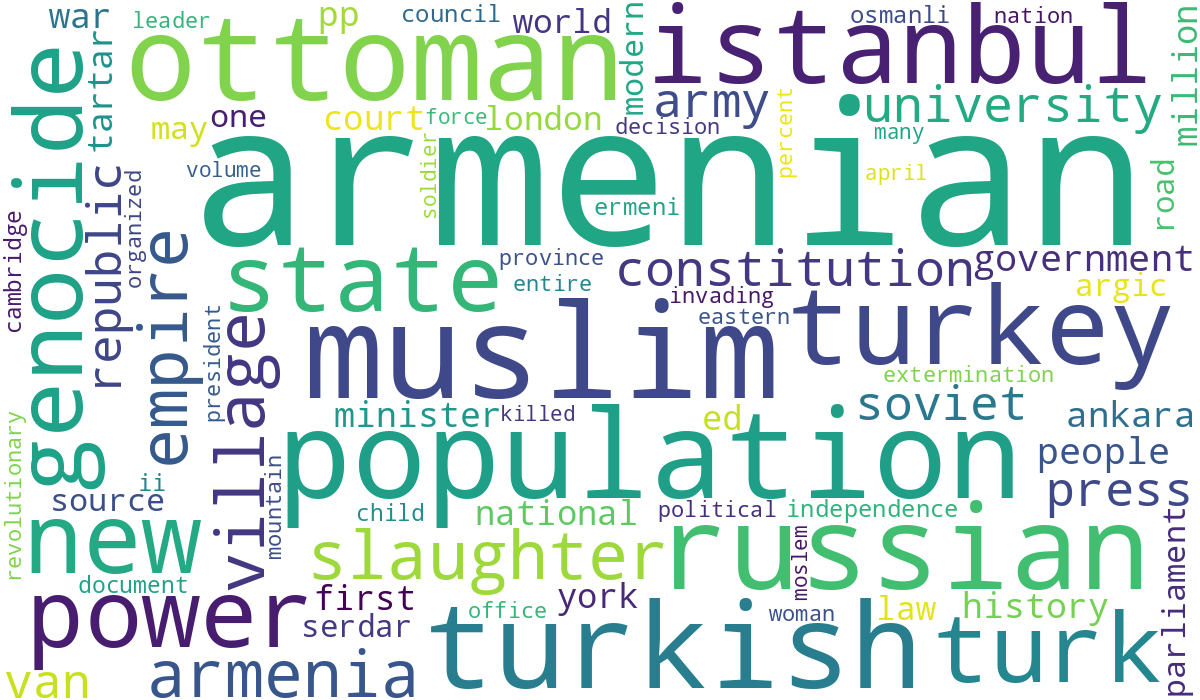

**tfidf_var_n_components_200 + dbscan, k=-1, cluster=-1** | size=2978 | dominant=comp.graphics (0.061)

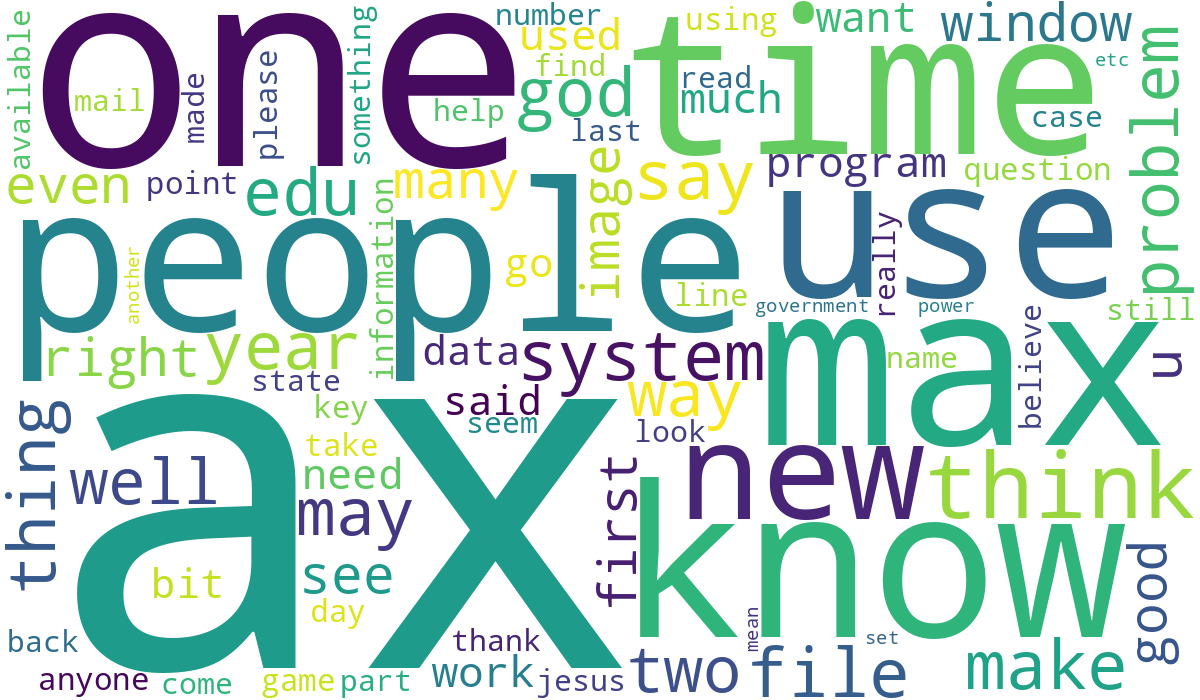

**tfidf_var_max_df_0.85 + dbscan, k=-1, cluster=1** | size=24 | dominant=talk.politics.mideast (1.000)

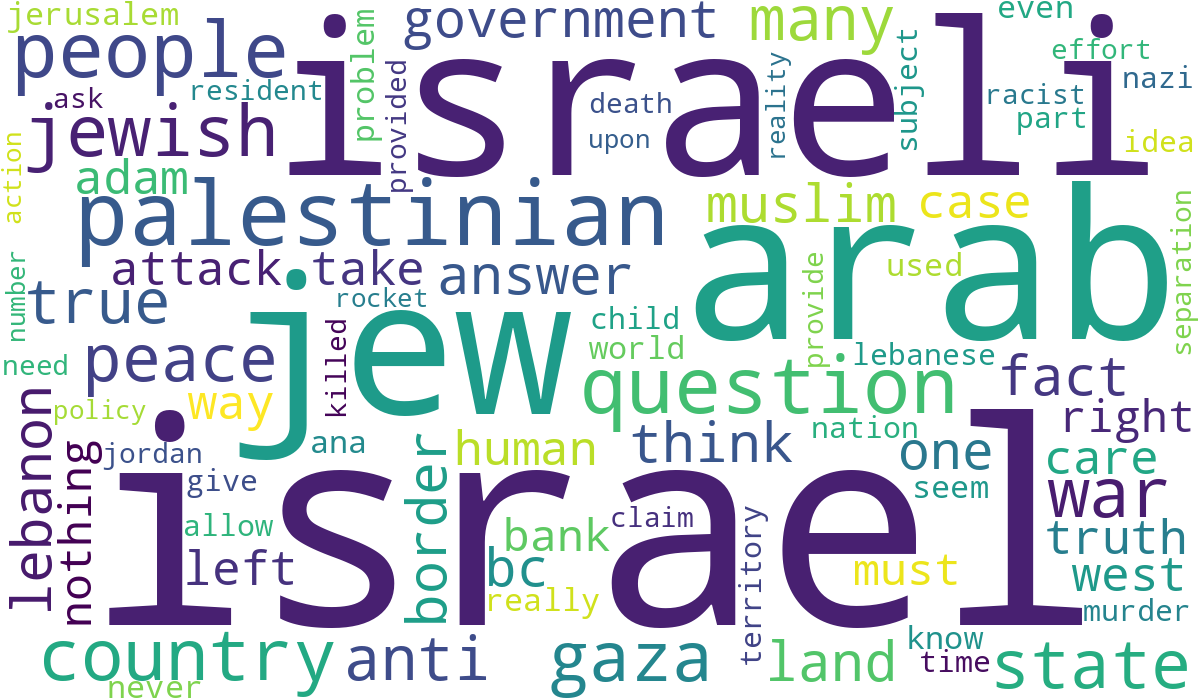

**tfidf_var_max_df_0.85 + dbscan, k=-1, cluster=0** | size=19 | dominant=talk.politics.mideast (1.000)

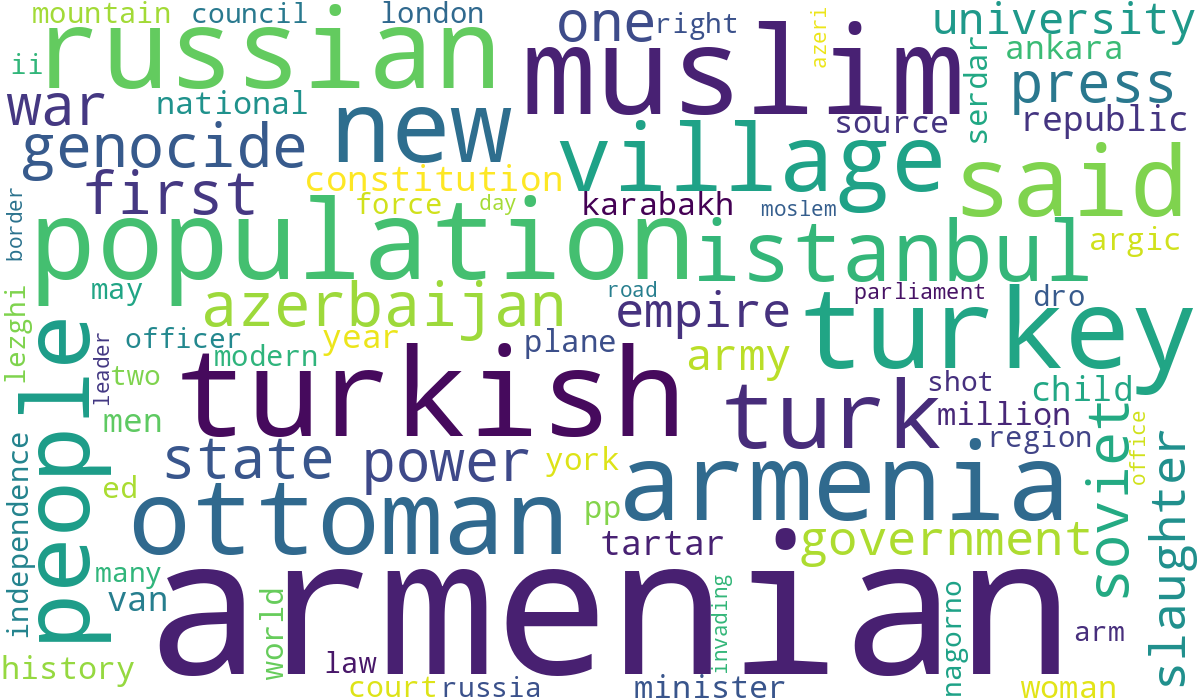

**tfidf_var_max_df_0.9 + dbscan, k=-1, cluster=1** | size=24 | dominant=talk.politics.mideast (1.000)

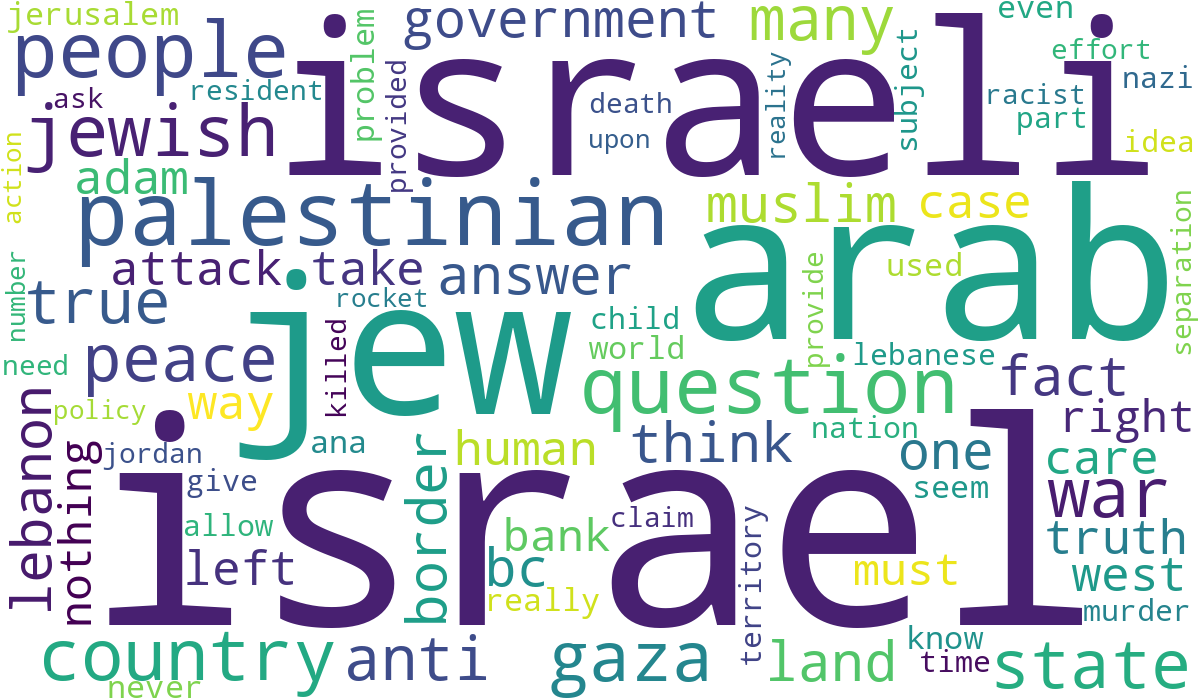

**tfidf_var_max_df_0.9 + dbscan, k=-1, cluster=0** | size=19 | dominant=talk.politics.mideast (1.000)

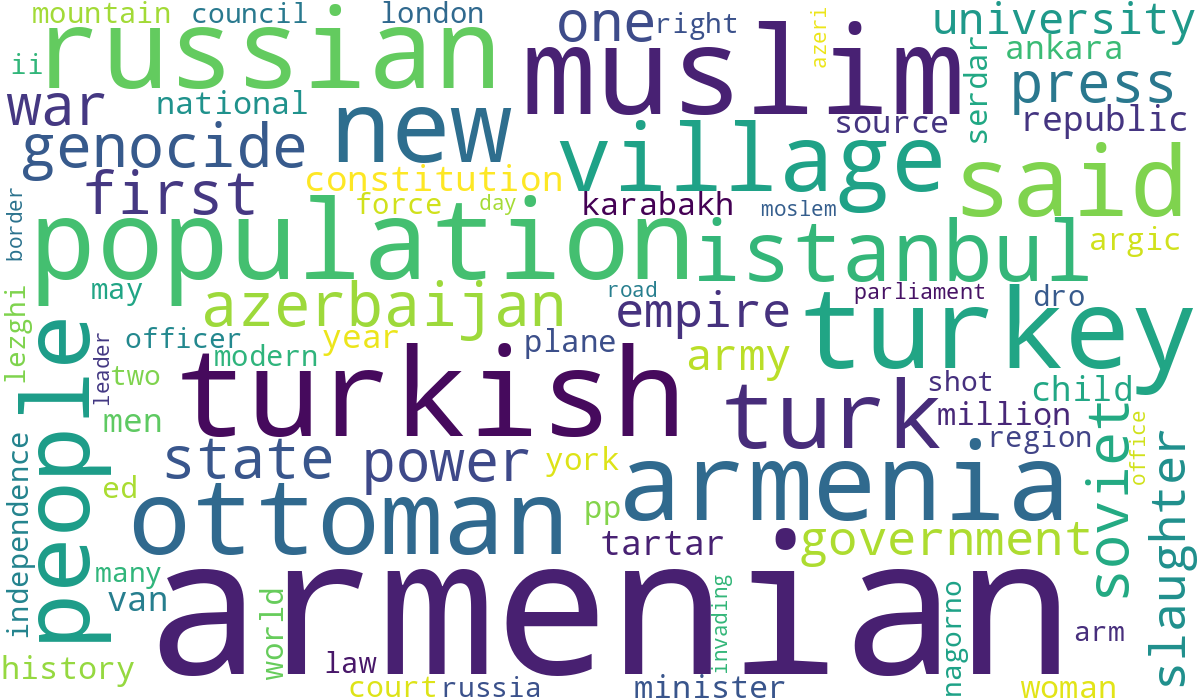


---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.


## Raport interpretacyjny klastrow (best runs)

> **Kryteria wyboru:** Top 3 przebiegow wybranych wg `selection_score_global` z sekcji 7. Purity, entropia i ARI sa raportowane jako diagnostyka post-hoc, bez wplywu na wybor.

### 1. tfidf_var_n_components_200 + dbscan (k=-1)

**Selection:** selection_score_global=1.000 | ARI post-hoc=1.000
**Etykiety post-hoc:** weighted_purity=0.067 | weighted_entropy_norm=0.989 | macro_purity=0.687
**Struktura:** largest_cluster_share=0.993 | tiny_clusters=1 | tiny_doc_share=0.003

- Najwieksze klastry: #-1 size=2978 dom=comp.graphics(0.06); #0 size=11 dom=talk.politics.mideast(1.00); #1 size=9 dom=sci.med(1.00)
- Najczystsze klastry (cluster_size >= 10): #0 size=11 dom=talk.politics.mideast(1.00); #-1 size=2978 dom=comp.graphics(0.06)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 0 | 11 | 0.004 | talk.politics.mideast | 1.000 | 0.000 | label_pure |
| -1 | 2978 | 0.993 | comp.graphics | 0.061 | 0.996 | mixed, giant |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster -1
  - Centralne:
    - doc_id=12411 | target=sci.space
      > But Allen, if you can assume the existence of an SSTO there is no need to have the contest in the first place. I would think that what we want to get out of the contest is the development of some of these 'cheaper' ways of doing things; if they already exis...
    - doc_id=2830 | target=sci.space
      > You missed something. I think it takes off vertically and is intended to land the same way. -- "Insisting on perfect safety is for people who don't have the balls to live in the real world." -- Mary Shafer, NASA Ames Dryden
  - Graniczne:
    - doc_id=18845 | target=rec.autos
      > After a tip from Gary Crum (crum@fcom.cc.utah.edu) I got on the Phone with "Pontiac Systems" or "Pontaic Customer Service" or whatever, and inquired about a rumoured Production Hold on the Formula Firebird and Trans Am. BTW, Talking with the dealer I bought...
    - doc_id=6323 | target=talk.religion.misc
      > It isn't. It's usually treated as being about as reliable as any other single, uncorroborated source of information about a person for whom there is no other evidence. What do you mean when you say it contains mirables. I just opened mine and not a damned t...
- Cluster 0
  - Centralne:
    - doc_id=15820 | target=talk.politics.mideast
      > 1/64th or 63/64th? I must congratulate your analytical and excellent reportage about Diana. From the writings of tye biographers you quoted, I can perceive, maybe chauvinistically, the remnants of her Armenian genes. Even though she is only 1/64th Armenian,...
    - doc_id=2603 | target=talk.politics.mideast
      > Typical 'Arromdian' of the ASALA/SDPA/ARF Terrorism and Revisionism Triangle. Well, does it change the fact that during the period of 1914 to 1920, the Armenian Government ordered, incited, assisted and participated in the genocide of 2.5 million Muslim peo...
  - Graniczne:
    - doc_id=3794 | target=talk.politics.mideast
      > Well, does it change the fact that during the period of 1914 to 1920, the fascist x-Soviet Armenian Government ordered, incited, assisted and participated in the genocide of 2.5 million Muslim people because of race, religion and national origin? As in the ...
    - doc_id=7123 | target=talk.politics.mideast
      > "Hate messages" rather than "facts"? Sorry, but your argument falls flat on its face. SOME OF THE REFERENCES FROM EMINENT AUTHORS IN THE FIELD OF MIDDLE-EASTERN HISTORY AND EYEWITNESSES OF THE ARMENIAN GENOCIDE OF 2.5 MILLION MUSLIMS 1. "The Armenian Revolu...

---

### 2. tfidf_var_max_df_0.85 + dbscan (k=-1)

**Selection:** selection_score_global=0.909 | ARI post-hoc=0.000
**Etykiety post-hoc:** weighted_purity=0.075 | weighted_entropy_norm=0.981 | macro_purity=0.687
**Struktura:** largest_cluster_share=0.986 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00)
- Najczystsze klastry (cluster_size >= 10): #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 1 | 24 | 0.008 | talk.politics.mideast | 1.000 | 0.000 | label_pure |
| 0 | 19 | 0.006 | talk.politics.mideast | 1.000 | 0.000 | label_pure |
| -1 | 2955 | 0.986 | comp.graphics | 0.062 | 0.995 | mixed, giant |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 0
  - Centralne:
    - doc_id=3794 | target=talk.politics.mideast
      > Well, does it change the fact that during the period of 1914 to 1920, the fascist x-Soviet Armenian Government ordered, incited, assisted and participated in the genocide of 2.5 million Muslim people because of race, religion and national origin? As in the ...
    - doc_id=15820 | target=talk.politics.mideast
      > 1/64th or 63/64th? I must congratulate your analytical and excellent reportage about Diana. From the writings of tye biographers you quoted, I can perceive, maybe chauvinistically, the remnants of her Armenian genes. Even though she is only 1/64th Armenian,...
  - Graniczne:
    - doc_id=5169 | target=talk.politics.mideast
      > The scenario and genocide staged by the Armenians 78 years ago in x-Soviet Armenia is being reenacted again - this time in Azerbaijan. The stories of survivors of Karabag massacre are in 'Milliyet' today. 69 year old Hatin Nine telling: -''My Twin grandchil...
    - doc_id=4114 | target=talk.politics.mideast
      > Source: Channel 4 News at 19.00, Monday 2 March 1992. 2 French journalists have seen 32 corpses of men, women and children in civilian clothes. Many of them shot dead from their heads as close as less than 1 meter. Source: BBC1 Morning news at 07.37, Tuesda...
- Cluster 1
  - Centralne:
    - doc_id=9126 | target=talk.politics.mideast
      > I wouldn't bet on it. Arab governments generally don't care much about the Palestineans and their struggle but find it useful for political purposes back home. They are happy to leave the Palestineans largely under Israeli control because that leaves the jo...
    - doc_id=14101 | target=talk.politics.mideast
      > The wars of 1948, 1956, 1967, 1978 were definitely started by the Arabs. The war in 1982 was instigated by the Arabs who continually murdered Israeli children with their rocket attacks. Israel was only trying to stop this. Last what the heck are you talking...
  - Graniczne:
    - doc_id=17536 | target=talk.politics.mideast
      > What is this "Gaza"? Are you purposely separating it from the "West Bank"? If so, why separate the people and territories? If not, why are you just addressing "Gaza" here? By all means, continue to list the "etc." The reason I particularly bring this up her...
    - doc_id=16383 | target=talk.politics.mideast
      > From Israel Line, Thursday, April 22, 1993: Today's HA'ARETZ reports that three women were injured when a Katyusha rocket fell in the center of their community. The rocket was one of several dozen fired at the communities of the Galilee in northern Israel y...

---

### 3. tfidf_var_max_df_0.9 + dbscan (k=-1)

**Selection:** selection_score_global=0.909 | ARI post-hoc=0.000
**Etykiety post-hoc:** weighted_purity=0.075 | weighted_entropy_norm=0.981 | macro_purity=0.687
**Struktura:** largest_cluster_share=0.986 | tiny_clusters=0 | tiny_doc_share=0.000

- Najwieksze klastry: #-1 size=2955 dom=comp.graphics(0.06); #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00)
- Najczystsze klastry (cluster_size >= 10): #1 size=24 dom=talk.politics.mideast(1.00); #0 size=19 dom=talk.politics.mideast(1.00); #-1 size=2955 dom=comp.graphics(0.06)

**Top klastry wg purity post-hoc (po odfiltrowaniu malych klastrow):**

| cluster_id | size | share | dominant_target | purity | entropy_norm | flags |
|---:|---:|---:|---|---:|---:|---|
| 1 | 24 | 0.008 | talk.politics.mideast | 1.000 | 0.000 | label_pure |
| 0 | 19 | 0.006 | talk.politics.mideast | 1.000 | 0.000 | label_pure |
| -1 | 2955 | 0.986 | comp.graphics | 0.062 | 0.995 | mixed, giant |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 0
  - Centralne:
    - doc_id=3794 | target=talk.politics.mideast
      > Well, does it change the fact that during the period of 1914 to 1920, the fascist x-Soviet Armenian Government ordered, incited, assisted and participated in the genocide of 2.5 million Muslim people because of race, religion and national origin? As in the ...
    - doc_id=15820 | target=talk.politics.mideast
      > 1/64th or 63/64th? I must congratulate your analytical and excellent reportage about Diana. From the writings of tye biographers you quoted, I can perceive, maybe chauvinistically, the remnants of her Armenian genes. Even though she is only 1/64th Armenian,...
  - Graniczne:
    - doc_id=5169 | target=talk.politics.mideast
      > The scenario and genocide staged by the Armenians 78 years ago in x-Soviet Armenia is being reenacted again - this time in Azerbaijan. The stories of survivors of Karabag massacre are in 'Milliyet' today. 69 year old Hatin Nine telling: -''My Twin grandchil...
    - doc_id=4114 | target=talk.politics.mideast
      > Source: Channel 4 News at 19.00, Monday 2 March 1992. 2 French journalists have seen 32 corpses of men, women and children in civilian clothes. Many of them shot dead from their heads as close as less than 1 meter. Source: BBC1 Morning news at 07.37, Tuesda...
- Cluster 1
  - Centralne:
    - doc_id=9126 | target=talk.politics.mideast
      > I wouldn't bet on it. Arab governments generally don't care much about the Palestineans and their struggle but find it useful for political purposes back home. They are happy to leave the Palestineans largely under Israeli control because that leaves the jo...
    - doc_id=14101 | target=talk.politics.mideast
      > The wars of 1948, 1956, 1967, 1978 were definitely started by the Arabs. The war in 1982 was instigated by the Arabs who continually murdered Israeli children with their rocket attacks. Israel was only trying to stop this. Last what the heck are you talking...
  - Graniczne:
    - doc_id=17536 | target=talk.politics.mideast
      > What is this "Gaza"? Are you purposely separating it from the "West Bank"? If so, why separate the people and territories? If not, why are you just addressing "Gaza" here? By all means, continue to list the "etc." The reason I particularly bring this up her...
    - doc_id=16383 | target=talk.politics.mideast
      > From Israel Line, Thursday, April 22, 1993: Today's HA'ARETZ reports that three women were injured when a Katyusha rocket fell in the center of their community. The rocket was one of several dozen fired at the communities of the Galilee in northern Israel y...

---


In [31]:
from IPython.display import HTML, Image, Markdown, display

cluster_profiles_df, cluster_examples, interpretation_runs_df = explain_best_runs(
    best_runs_df=best_runs_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

wordcloud_index_df = generate_wordcloud_artifacts(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    best_runs_df=best_runs_df,
    config=CONFIG,
)

interpretation_md = format_interpretation_markdown(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=int(CONFIG.get("wordcloud_top_runs", 3)),
    min_cluster_size=int(CONFIG.get("wordcloud_min_cluster_size", 10)),
)

interpretation_runs_view = (
    interpretation_runs_df
    .sort_values(["selection_score_global", "weighted_normalized_entropy", "weighted_purity"], ascending=[False, True, False])
    .reset_index(drop=True)
)

cluster_profiles_view = (
    cluster_profiles_df
    .sort_values(["cluster_size", "dominant_target_share"], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)

examples_view = build_examples_dataframe(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=int(CONFIG.get("wordcloud_top_runs", 3)),
    clusters_per_run=int(CONFIG.get("wordcloud_clusters_per_run", 2)),
    docs_per_role=2,
    min_cluster_size=int(CONFIG.get("wordcloud_min_cluster_size", 10)),
)

display(Markdown("""
---
### Tabela A: `interpretation_runs_df` — diagnostyka przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking sortowany malejąco po `selection_score_global`, a metryki etykietowe są diagnostyką post-hoc.

Kluczowe pola:
- `selection_score_global`: nienadzorowane kryterium wyboru z sekcji 7,
- `weighted_purity` i `weighted_normalized_entropy`: globalna zgodność z etykietami, ważona rozmiarem klastrów,
- `macro_purity` i `macro_normalized_entropy`: diagnostyka fragmentacji,
- `tiny_cluster_count`, `tiny_cluster_doc_share`, `largest_cluster_share`: diagnostyka struktury podziału.
"""))
with pd.option_context("display.max_colwidth", 140):
    display(interpretation_runs_view)

display(Markdown("""
---
### Tabela B: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi, etykietowymi i strukturalnymi. Purity dla małych klastrów traktujemy ostrożnie.
"""))
with pd.option_context("display.max_colwidth", 120):
    display(cluster_profiles_view)

display(Markdown("""
---
### Tabela C: dokumenty przykładowe (centralne vs graniczne)

Lepszy widok dokumentów do analizy jakości klastrów:
- `central`: dokumenty najbardziej typowe dla klastra,
- `boundary`: dokumenty najbardziej graniczne.

Dane obejmują top przebiegi i top klastry po odfiltrowaniu bardzo małych klastrów.
"""))
with pd.option_context("display.max_colwidth", 180):
    display(examples_view)

if not wordcloud_index_df.empty:
    display(Markdown("""
---
### Tabela D: `wordcloud_index_df`

Indeks wygenerowanych WordCloud. Chmury słów są elementem interpretacji leksykalnej, nie metryką jakości.
"""))
    display(wordcloud_index_df)
    display_wordclouds(wordcloud_index_df)

display(Markdown("""
---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.
"""))
display(Markdown(interpretation_md))


## 9. Artefakty, wykresy i MLflow

Wyniki eksperymentow sa zapisywane jako tabele `CSV`, pliki `JSON`, wykresy, WordCloud oraz lokalne przebiegi `MLflow`. Dzieki temu notebook pelni jednoczesnie role raportu i dokumentacji wykonanych eksperymentow.


In [ ]:
def save_project_artifacts(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    config: Dict[str, Any],
    wordcloud_index_df: Optional[pd.DataFrame] = None,
) -> Dict[str, str]:
    artifact_dir = Path(config["artifact_dir"])
    tables_dir = artifact_dir / "tables"
    tables_dir.mkdir(parents=True, exist_ok=True)

    results_path = tables_dir / "results_summary.csv"
    best_path = tables_dir / "best_runs.json"
    profiles_path = tables_dir / "cluster_profiles.csv"
    examples_path = tables_dir / "cluster_examples.json"
    wordcloud_index_path = tables_dir / "wordcloud_index.csv"

    results_df.to_csv(results_path, index=False)
    cluster_profiles_df.to_csv(profiles_path, index=False)
    best_path.write_text(
        json.dumps(best_runs_df.to_dict(orient="records"), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    examples_path.write_text(
        json.dumps(cluster_examples, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    artifact_paths = {
        "results_summary": str(results_path),
        "best_runs": str(best_path),
        "cluster_profiles": str(profiles_path),
        "cluster_examples": str(examples_path),
    }

    if wordcloud_index_df is not None and not wordcloud_index_df.empty:
        wordcloud_index_df.to_csv(wordcloud_index_path, index=False)
        artifact_paths["wordcloud_index"] = str(wordcloud_index_path)
        for idx, row in enumerate(wordcloud_index_df.itertuples(index=False), start=1):
            artifact_paths[f"wordcloud_{idx:02d}"] = str(row.wordcloud_path)

    return artifact_paths


def format_parameter_label(row: pd.Series) -> str:
    algorithm = str(row.get("algorithm", ""))
    if algorithm == "dbscan":
        eps = row.get("eps", np.nan)
        min_samples = row.get("min_samples", np.nan)
        eps_label = "?" if pd.isna(eps) else f"{float(eps):g}"
        min_samples_label = "?" if pd.isna(min_samples) else str(int(min_samples))
        metric_label = row.get("metric", "")
        metric_part = f", {metric_label}" if isinstance(metric_label, str) and metric_label else ""
        return f"eps={eps_label}, ms={min_samples_label}{metric_part}"

    k = row.get("k", np.nan)
    if pd.isna(k) or int(k) < 0:
        return "k=na"

    label_parts = [f"k={int(k)}"]
    if algorithm == "spectral" and "n_neighbors" in row.index and not pd.isna(row.get("n_neighbors")):
        label_parts.append(f"nn={int(row['n_neighbors'])}")
    return ", ".join(label_parts)


def format_compact_run_label(row: pd.Series) -> str:
    embedding_label = format_embedding_plot_label(row["embedding_name"], width=24)
    algorithm_label = format_algorithm_plot_label(row["algorithm"])
    return f"{embedding_label} + {algorithm_label}\n{format_parameter_label(row)}"


def generate_summary_plots(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    artifact_dir: Path,
) -> Dict[str, str]:
    plots_dir = artifact_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    silhouette_path = plots_dir / "best_silhouette_by_model.png"
    ari_path = plots_dir / "best_ari_by_model.png"
    davies_bouldin_path = plots_dir / "best_davies_bouldin_by_model.png"
    dunn_path = plots_dir / "best_dunn_by_model.png"
    selection_path = plots_dir / "best_selection_score_global_by_model.png"
    tradeoff_path = plots_dir / "section10_silhouette_ari_tradeoff.png"
    efficiency_path = plots_dir / "section10_selection_runtime_efficiency.png"
    tradeoff_interactive_path = plots_dir / "section10_silhouette_ari_tradeoff_interactive.html"
    efficiency_interactive_path = plots_dir / "section10_selection_runtime_efficiency_interactive.html"
    k_sensitivity_path = plots_dir / "section10_k_sensitivity.png"
    metric_profile_path = plots_dir / "section10_metric_profile_heatmap.png"

    make_metric_barplot(best_runs_df, "silhouette", "Best silhouette by embedding and algorithm", silhouette_path)
    make_metric_barplot(best_runs_df, "ari", "Post-hoc ARI by embedding and algorithm", ari_path)
    make_metric_barplot(best_runs_df, "davies_bouldin", "Best Davies-Bouldin by embedding and algorithm (lower is better)", davies_bouldin_path)
    make_metric_barplot(best_runs_df, "dunn", "Best Dunn index by embedding and algorithm", dunn_path)
    make_metric_barplot(best_runs_df, "selection_score_global", "Global selection_score among local winners", selection_path)
    make_metric_tradeoff_plot(best_runs_df, tradeoff_path)
    make_runtime_efficiency_plot(best_runs_df, efficiency_path)
    make_k_sensitivity_plot(results_df, k_sensitivity_path)
    make_metric_profile_heatmap(best_runs_df, metric_profile_path)
    interactive_tradeoff = write_interactive_scatter(
        plot_df=best_runs_df,
        x_col="silhouette",
        y_col="ari",
        output_path=tradeoff_interactive_path,
        title="Interaktywnie: silhouette vs ARI",
        x_label="silhouette",
        y_label="ARI post-hoc",
    )
    interactive_efficiency = write_interactive_scatter(
        plot_df=best_runs_df,
        x_col="runtime_sec",
        y_col="selection_score_global",
        output_path=efficiency_interactive_path,
        title="Interaktywnie: runtime vs selection_score_global",
        x_label="runtime_sec",
        y_label="selection_score_global",
    )

    plot_paths = {
        "best_silhouette_plot": str(silhouette_path),
        "best_ari_plot": str(ari_path),
        "best_davies_bouldin_plot": str(davies_bouldin_path),
        "best_dunn_plot": str(dunn_path),
        "best_selection_score_global_plot": str(selection_path),
        "section10_tradeoff_plot": str(tradeoff_path),
        "section10_efficiency_plot": str(efficiency_path),
        "section10_k_sensitivity_plot": str(k_sensitivity_path),
        "section10_metric_profile_plot": str(metric_profile_path),
    }
    if interactive_tradeoff:
        plot_paths["section10_tradeoff_interactive"] = interactive_tradeoff
    if interactive_efficiency:
        plot_paths["section10_efficiency_interactive"] = interactive_efficiency
    return plot_paths


def make_metric_barplot(best_runs_df: pd.DataFrame, metric: str, title: str, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty or metric not in plot_df.columns:
        return
    plot_df["label"] = plot_df.apply(format_compact_run_label, axis=1)
    higher_is_better = metric != "davies_bouldin"
    max_rows = 25
    if len(plot_df) > max_rows:
        plot_df = plot_df.nlargest(max_rows, metric) if higher_is_better else plot_df.nsmallest(max_rows, metric)
        title = f"{title} (top {max_rows})"
    plot_df = plot_df.sort_values(metric, ascending=higher_is_better)

    fig_height = max(5.0, 0.42 * len(plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(plot_df["label"], plot_df[metric], color="#355C7D")
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("embedding + algorithm")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.2)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.margins(x=0.12)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_metric_tradeoff_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty:
        return

    plot_df["annotation_label"] = plot_df.apply(format_compact_run_label, axis=1)
    algorithm_colors = {"kmeans": "#F67280", "hierarchical": "#6C5B7B", "dbscan": "#C06C84", "spectral": "#2A9D8F"}
    markers = {"kmeans": "o", "hierarchical": "s", "dbscan": "^", "spectral": "D"}

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.6, 6.8), gridspec_kw={"width_ratios": [1.25, 1.08]})
    for _, row in plot_df.iterrows():
        size = 220 + 520 * max(float(row.get("selection_score_global", 0.0)), 0.0)
        ax.scatter(
            row["silhouette"],
            row["ari"],
            s=size,
            color=algorithm_colors.get(row["algorithm"], "#355C7D"),
            marker=markers.get(row["algorithm"], "o"),
            edgecolor="#1f2933",
            linewidth=0.8,
            alpha=0.82,
        )
    ax.axhline(0, color="#8a8f98", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_title("Trade-off: separacja geometryczna vs ARI post-hoc")
    ax.set_xlabel("silhouette (wyzej = lepiej)")
    ax.set_ylabel("ARI wzgledem kategorii 20 Newsgroups (post-hoc)")
    ax.grid(alpha=0.22)
    handles = [
        plt.Line2D([0], [0], marker=markers.get(name, "o"), color="w", label=name,
                   markerfacecolor=color, markeredgecolor="#1f2933", markersize=9)
        for name, color in algorithm_colors.items()
        if name in set(plot_df["algorithm"])
    ]
    if handles:
        fig.legend(handles=handles, title="algorithm", loc="lower left", bbox_to_anchor=(0.06, 0.01), ncol=len(handles))
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("silhouette", "sil", ".2f"), ("ari", "ARI", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_runtime_efficiency_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty or "selection_score_global" not in plot_df.columns:
        return
    plot_df["annotation_label"] = plot_df.apply(format_compact_run_label, axis=1)

    fig, (ax, table_ax) = plt.subplots(1, 2, figsize=(16.3, 6.4), gridspec_kw={"width_ratios": [1.25, 1.08]})
    for algorithm, group in plot_df.groupby("algorithm"):
        ax.scatter(group["runtime_sec"], group["selection_score_global"], s=160, alpha=0.82, label=algorithm)
    ax.set_xscale("log")
    ax.set_title("Diagnostyka: selection_score_global wzgledem czasu wykonania")
    ax.set_xlabel("runtime_sec (skala log, nizej = szybciej)")
    ax.set_ylabel("selection_score_global (wyzej = lepiej)")
    ax.grid(alpha=0.22)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="algorithm", loc="lower left", bbox_to_anchor=(0.06, 0.01), ncol=len(handles))
    add_top_runs_table(
        ax=table_ax,
        plot_df=plot_df,
        columns=[("selection_score_global", "score", ".2f"), ("runtime_sec", "sec", ".1f"), ("silhouette", "sil", ".2f")],
        max_rows=8,
        title="Top wg selection_score_global",
    )
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_k_sensitivity_plot(results_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("silhouette", "max", "Silhouette (wyzej = lepiej)"),
        ("ari", "max", "ARI post-hoc (wyzej = wieksza zgodnosc z etykietami)"),
        ("dunn", "max", "Dunn (wyzej = lepiej)"),
        ("davies_bouldin", "min", "Davies-Bouldin (nizej = lepiej)"),
    ]
    required = {"embedding_name", "algorithm", "k"} | {metric for metric, _, _ in metric_specs}
    if results_df.empty or not required.issubset(results_df.columns):
        return

    metric_columns = [metric for metric, _, _ in metric_specs]
    plot_df = results_df.dropna(subset=["k", *metric_columns]).copy()
    plot_df = plot_df[plot_df["k"] >= 0]
    if plot_df.empty:
        return
    plot_df["run_family"] = plot_df["embedding_name"] + " + " + plot_df["algorithm"]
    max_families = 12
    family_scores = plot_df.groupby("run_family")["silhouette"].max().sort_values(ascending=False)
    selected_families = family_scores.head(max_families).index
    plot_df = plot_df[plot_df["run_family"].isin(selected_families)].copy()
    if plot_df.empty:
        return
    agg_spec = {metric: (metric, agg_func) for metric, agg_func, _ in metric_specs}
    summary = plot_df.groupby(["run_family", "k"], as_index=False).agg(**agg_spec).sort_values("k")
    summary["run_family_label"] = summary["run_family"].map(lambda value: wrap_plot_text(value, width=28, max_lines=2, max_chars=54))
    title_suffix = f" (top {len(selected_families)} serii wg silhouette)" if len(family_scores) > max_families else ""

    fig, axes = plt.subplots(2, 2, figsize=(15.5, 10.8), sharex=True)
    axes_flat = axes.ravel()
    for ax, (metric, _, title) in zip(axes_flat, metric_specs):
        for run_family_label, group in summary.groupby("run_family_label"):
            ax.plot(group["k"], group[metric], marker="o", linewidth=1.6, label=run_family_label)
        ax.set_title(f"Wrazliwosc {title} na liczbe klastrow{title_suffix}", fontsize=10)
        ax.set_ylabel(metric)
        ax.axvline(20, color="#8a8f98", linewidth=0.9, linestyle="--", alpha=0.7)
        ax.set_xlabel("k")
        ax.grid(alpha=0.22)
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=3, fontsize=7)
    fig.tight_layout(rect=(0, 0.11, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def normalize_metric(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    values = series.astype(float)
    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.5, index=series.index)
    normalized = (values - min_value) / (max_value - min_value)
    return normalized if higher_is_better else 1 - normalized


def make_metric_profile_heatmap(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("selection_score_global", True, "selection_score_global"),
        ("silhouette", True, "silhouette"),
        ("dunn", True, "Dunn"),
        ("davies_bouldin", False, "Davies-Bouldin inv."),
        ("ari", True, "ARI post-hoc"),
        ("runtime_sec", False, "runtime inv."),
    ]
    required = {metric for metric, _, _ in metric_specs}
    if best_runs_df.empty or not required.issubset(best_runs_df.columns):
        return

    plot_df = best_runs_df.copy().reset_index(drop=True)
    max_rows = 30
    if "selection_score_global" in plot_df.columns and len(plot_df) > max_rows:
        plot_df = plot_df.sort_values("selection_score_global", ascending=False).head(max_rows).reset_index(drop=True)
    labels = plot_df.apply(format_compact_run_label, axis=1)
    heatmap_values = pd.DataFrame(
        {
            label: normalize_metric(plot_df[metric], higher_is_better=higher_is_better)
            for metric, higher_is_better, label in metric_specs
        }
    )

    fig_height = max(4.8, 0.5 * len(plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(11.2, fig_height))
    image = ax.imshow(heatmap_values.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_title("Profil metryk dla best-runs (0 = slabszy, 1 = lepszy w danej metryce)")
    ax.set_xticks(np.arange(len(heatmap_values.columns)))
    ax.set_xticklabels(heatmap_values.columns, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    for i in range(heatmap_values.shape[0]):
        for j in range(heatmap_values.shape[1]):
            value = heatmap_values.iat[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="#102030")
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def log_summary_run(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    artifact_paths: Dict[str, str],
    config: Dict[str, Any],
) -> None:
    with mlflow.start_run(run_name=f"{config['mode']}_summary", nested=False):
        mlflow.set_tags({"mode": config["mode"], "kind": "summary"})
        mlflow.log_dict(config, "config.json")
        mlflow.log_metrics(
            {
                "n_total_runs": float(len(results_df)),
                "n_best_runs": float(len(best_runs_df)),
                "n_profile_rows": float(len(cluster_profiles_df)),
                "best_selection_score_global_max": float(best_runs_df["selection_score_global"].max()),
                "best_silhouette_max": float(best_runs_df["silhouette"].max()),
                "best_ari_posthoc_max": float(best_runs_df["ari"].max()),
            }
        )
        for path in artifact_paths.values():
            mlflow.log_artifact(path)


def format_run_label(row: pd.Series) -> str:
    return f"{row['embedding_name']} + {row['algorithm']} (k={int(row['k'])})"


def build_section10_views(
    best_runs_df: pd.DataFrame,
    interpretation_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
) -> Dict[str, pd.DataFrame]:
    empty = pd.DataFrame()
    if best_runs_df.empty:
        return {
            "leaderboard": empty,
            "embedding_summary": empty,
            "algorithm_summary": empty,
            "k_summary": empty,
            "purity_summary": empty,
        }

    best_runs_for_display = best_runs_df.copy()
    best_runs_for_display["parameter_label"] = best_runs_for_display.apply(format_parameter_label, axis=1)

    leaderboard_columns = [
        "embedding_name", "algorithm", "parameter_label", "k", "selection_score_local", "selection_score_global",
        "silhouette", "davies_bouldin", "dunn", "ari", "pareto_front", "runtime_sec",
    ]
    optional_parameter_columns = [
        column for column in ["eps", "min_samples", "n_neighbors"]
        if column in best_runs_for_display.columns
    ]
    leaderboard = (
        best_runs_for_display[leaderboard_columns + optional_parameter_columns]
        .sort_values(["selection_score_global", "silhouette", "dunn"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    embedding_summary = (
        best_runs_df.groupby(["embedding_name", "embedding_label", "embedding_family"], as_index=False)
        .agg(
            n_selected_runs=("embedding_name", "size"),
            best_selection_score_global=("selection_score_global", "max"),
            mean_selection_score_global=("selection_score_global", "mean"),
            best_silhouette=("silhouette", "max"),
            best_ari_posthoc=("ari", "max"),
            fastest_runtime_sec=("runtime_sec", "min"),
        )
        .sort_values(["best_selection_score_global", "best_silhouette"], ascending=[False, False])
        .reset_index(drop=True)
    )

    algorithm_summary = (
        best_runs_df.groupby("algorithm", as_index=False)
        .agg(
            n_selected_runs=("algorithm", "size"),
            best_selection_score_global=("selection_score_global", "max"),
            mean_selection_score_global=("selection_score_global", "mean"),
            mean_silhouette=("silhouette", "mean"),
            mean_ari_posthoc=("ari", "mean"),
            mean_runtime_sec=("runtime_sec", "mean"),
        )
        .sort_values(["best_selection_score_global", "mean_selection_score_global"], ascending=[False, False])
        .reset_index(drop=True)
    )

    k_runs_df = best_runs_df[best_runs_df["k"] >= 0].copy()
    if k_runs_df.empty:
        k_summary = empty
    else:
        k_summary = (
            k_runs_df.groupby("k", as_index=False)
            .agg(
                n_selected_runs=("k", "size"),
                best_selection_score_global=("selection_score_global", "max"),
                mean_selection_score_global=("selection_score_global", "mean"),
                mean_silhouette=("silhouette", "mean"),
                mean_ari_posthoc=("ari", "mean"),
            )
            .assign(distance_to_expected=lambda df: (df["k"] - 20).abs())
            .sort_values(["best_selection_score_global", "mean_selection_score_global"], ascending=[False, False])
            .reset_index(drop=True)
        )

    purity_columns = [
        "embedding_name", "algorithm", "k", "weighted_purity", "macro_purity",
        "weighted_normalized_entropy", "macro_normalized_entropy", "tiny_cluster_count",
        "tiny_cluster_doc_share", "largest_cluster_share",
    ]
    purity_runs = interpretation_runs_df[[col for col in purity_columns if col in interpretation_runs_df.columns]].copy()

    if cluster_profiles_df.empty or "is_tiny_cluster" not in cluster_profiles_df.columns:
        purity_clusters = pd.DataFrame()
    else:
        purity_clusters = cluster_profiles_df[~cluster_profiles_df["is_tiny_cluster"]].copy()
    if purity_clusters.empty:
        purity_summary = purity_runs
    else:
        purity_summary = (
            purity_clusters.groupby(["embedding_name", "algorithm", "k"], as_index=False)
            .agg(
                n_interpretable_clusters=("cluster_id", "size"),
                mean_cluster_size=("cluster_size", "mean"),
                mean_dominant_target_share=("dominant_target_share", "mean"),
                label_pure_clusters=("is_label_pure", "sum"),
                mixed_clusters=("is_mixed_cluster", "sum"),
            )
            .merge(purity_runs, on=["embedding_name", "algorithm", "k"], how="left")
            .sort_values(
                ["weighted_purity", "weighted_normalized_entropy", "label_pure_clusters"],
                ascending=[False, True, False],
            )
            .reset_index(drop=True)
        )

    return {
        "leaderboard": leaderboard,
        "embedding_summary": embedding_summary,
        "algorithm_summary": algorithm_summary,
        "k_summary": k_summary,
        "purity_summary": purity_summary,
    }


In [ ]:
artifact_paths = save_project_artifacts(
    results_df=results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    config=CONFIG,
    wordcloud_index_df=wordcloud_index_df,
)

figure_paths = generate_summary_plots(
    results_df=results_df,
    best_runs_df=best_runs_df,
    artifact_dir=Path(CONFIG["artifact_dir"]),
)
artifact_paths.update(figure_paths)

log_summary_run(
    results_df=results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    artifact_paths=artifact_paths,
    config=CONFIG,
)

artifact_paths


{'results_summary': 'artifacts_quick/tables/results_summary.csv',
 'best_runs': 'artifacts_quick/tables/best_runs.json',
 'cluster_profiles': 'artifacts_quick/tables/cluster_profiles.csv',
 'cluster_examples': 'artifacts_quick/tables/cluster_examples.json',
 'wordcloud_index': 'artifacts_quick/tables/wordcloud_index.csv',
 'wordcloud_01': 'artifacts_quick/plots/wordclouds/wordcloud_01_tfidf_var_n_components_50_dbscan_k-1_cluster3.png',
 'wordcloud_02': 'artifacts_quick/plots/wordclouds/wordcloud_01_tfidf_var_n_components_50_dbscan_k-1_cluster0.png',
 'wordcloud_03': 'artifacts_quick/plots/wordclouds/wordcloud_02_tfidf_var_max_df_0.85_dbscan_k-1_cluster1.png',
 'wordcloud_04': 'artifacts_quick/plots/wordclouds/wordcloud_02_tfidf_var_max_df_0.85_dbscan_k-1_cluster0.png',
 'wordcloud_05': 'artifacts_quick/plots/wordclouds/wordcloud_03_tfidf_var_max_df_0.9_dbscan_k-1_cluster1.png',
 'wordcloud_06': 'artifacts_quick/plots/wordclouds/wordcloud_03_tfidf_var_max_df_0.9_dbscan_k-1_cluster0.png'

## 10. Podsumowanie wynikow

### Tabela 10A. Leaderboard lokalnych zwyciezcow porownanych globalnie

,embedding_name,algorithm,parameter_label,k,selection_score_local,selection_score_global,silhouette,davies_bouldin,dunn,ari,pareto_front,runtime_sec,eps,min_samples,n_neighbors
0,tfidf_var_n_components_50,dbscan,"eps=0.1, min_samples=10",-1,1.000000,1.000000,0.545471,0.641683,1.138349,0.617052,True,0.468364,0.1,10.0,NaN
1,tfidf_var_max_df_0.85,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.446288,0.2,15.0,NaN
2,tfidf_var_max_df_0.9,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.461174,0.2,15.0,NaN
3,tfidf_var_max_df_0.95,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.543447,0.2,15.0,NaN
4,tfidf_var_max_features_10000,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.449339,0.2,15.0,NaN
5,tfidf_var_min_df_5,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.608268,0.2,15.0,NaN
6,tfidf_var_n_components_100,dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.472335,0.2,15.0,NaN
7,tfidf_var_ngram_range_[1_2],dbscan,"eps=0.2, min_samples=15",-1,0.958333,0.927273,0.468671,0.846533,0.944474,0.000000,True,0.462926,0.2,15.0,NaN
8,tfidf_var_max_features_15000,dbscan,"eps=0.2, min_samples=10",-1,0.966667,0.836364,0.437132,0.890340,0.797773,0.547912,True,0.465206,0.2,10.0,NaN
9,tfidf_var_min_df_2,dbscan,"eps=0.2, min_samples=15",-1,1.000000,0.824242,0.434307,0.907041,0.870940,0.456941,True,0.493634,0.2,15.0,NaN


### Tabela 10B. Podsumowanie reprezentacji wg selection_score_global

,embedding_name,embedding_label,embedding_family,n_selected_runs,best_selection_score_global,mean_selection_score_global,best_silhouette,best_ari_posthoc,fastest_runtime_sec
0,tfidf_var_n_components_50,Variation: n_components_50,static_tfidf_svd,4,1.000000,0.610606,0.545471,0.617052,0.468364
1,tfidf_var_max_df_0.85,Variation: max_df_0.85,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.446288
2,tfidf_var_max_df_0.9,Variation: max_df_0.9,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.461174
3,tfidf_var_max_df_0.95,Variation: max_df_0.95,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.543447
4,tfidf_var_max_features_10000,Variation: max_features_10000,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.449339
5,tfidf_var_min_df_5,Variation: min_df_5,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.608268
6,tfidf_var_n_components_100,Variation: n_components_100,static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.472335
7,tfidf_var_ngram_range_[1_2],Variation: ngram_range_[1_2],static_tfidf_svd,4,0.927273,0.495455,0.468671,0.121801,0.462926
8,tfidf_var_max_features_15000,Variation: max_features_15000,static_tfidf_svd,4,0.836364,0.519697,0.437132,0.547912,0.465206
9,tfidf_var_min_df_2,Variation: min_df_2,static_tfidf_svd,4,0.824242,0.483333,0.434307,0.456941,0.493634


### Tabela 10C. Podsumowanie algorytmow wg selection_score_global

...

### Tabela 10D. Analiza liczby klastrow (`k`)

,k,n_selected_runs,best_selection_score_global,mean_selection_score_global,mean_silhouette,mean_ari_posthoc,distance_to_expected
0,20,7,0.509091,0.458874,0.054707,0.094967,0
1,25,24,0.490909,0.358333,0.025921,0.070111,5
2,15,11,0.454545,0.349311,0.039893,0.092481,5


### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi (post-hoc)

,embedding_name,algorithm,k,n_interpretable_clusters,mean_cluster_size,mean_dominant_target_share,label_pure_clusters,mixed_clusters,weighted_purity,macro_purity,weighted_normalized_entropy,macro_normalized_entropy,tiny_cluster_count,tiny_cluster_doc_share,largest_cluster_share
0,tfidf_var_min_df_10,kmeans,20,19,157.578947,0.617485,8,3,0.396000,0.636611,0.628159,0.366337,1,0.002000,0.320333
1,tfidf_var_max_features_5000,kmeans,25,23,129.782609,0.537513,7,5,0.389667,0.543400,0.622140,0.448508,2,0.005000,0.272000
2,tfidf_var_n_components_50,kmeans,20,19,157.578947,0.574036,7,4,0.384000,0.595334,0.632318,0.401509,1,0.002000,0.285000
3,tfidf_var_ngram_range_[1_1],kmeans,20,20,150.000000,0.563451,6,2,0.378333,0.563451,0.634197,0.419877,0,0.000000,0.370333
4,tfidf_var_min_df_2,kmeans,20,19,157.578947,0.552725,6,5,0.374333,0.575089,0.650087,0.427857,1,0.002000,0.312000
5,tfidf_var_max_features_15000,kmeans,25,23,130.000000,0.529785,7,5,0.373667,0.557402,0.636682,0.430094,2,0.003333,0.262000
6,tfidf_var_max_features_15000,hierarchical,25,24,124.833333,0.567757,8,4,0.373000,0.575047,0.654452,0.425609,1,0.001333,0.296000
7,tfidf_var_n_components_50,hierarchical,20,20,150.000000,0.578458,7,2,0.353667,0.578458,0.664660,0.420294,0,0.000000,0.365667
8,tfidf_var_max_df_0.85,kmeans,15,14,213.857143,0.522530,4,3,0.348667,0.554361,0.658189,0.433073,1,0.002000,0.380000
9,tfidf_var_max_df_0.9,kmeans,15,14,213.857143,0.522530,4,3,0.348667,0.554361,0.658189,0.433073,1,0.002000,0.380000


### Wykresy przekrojowe sekcji 10

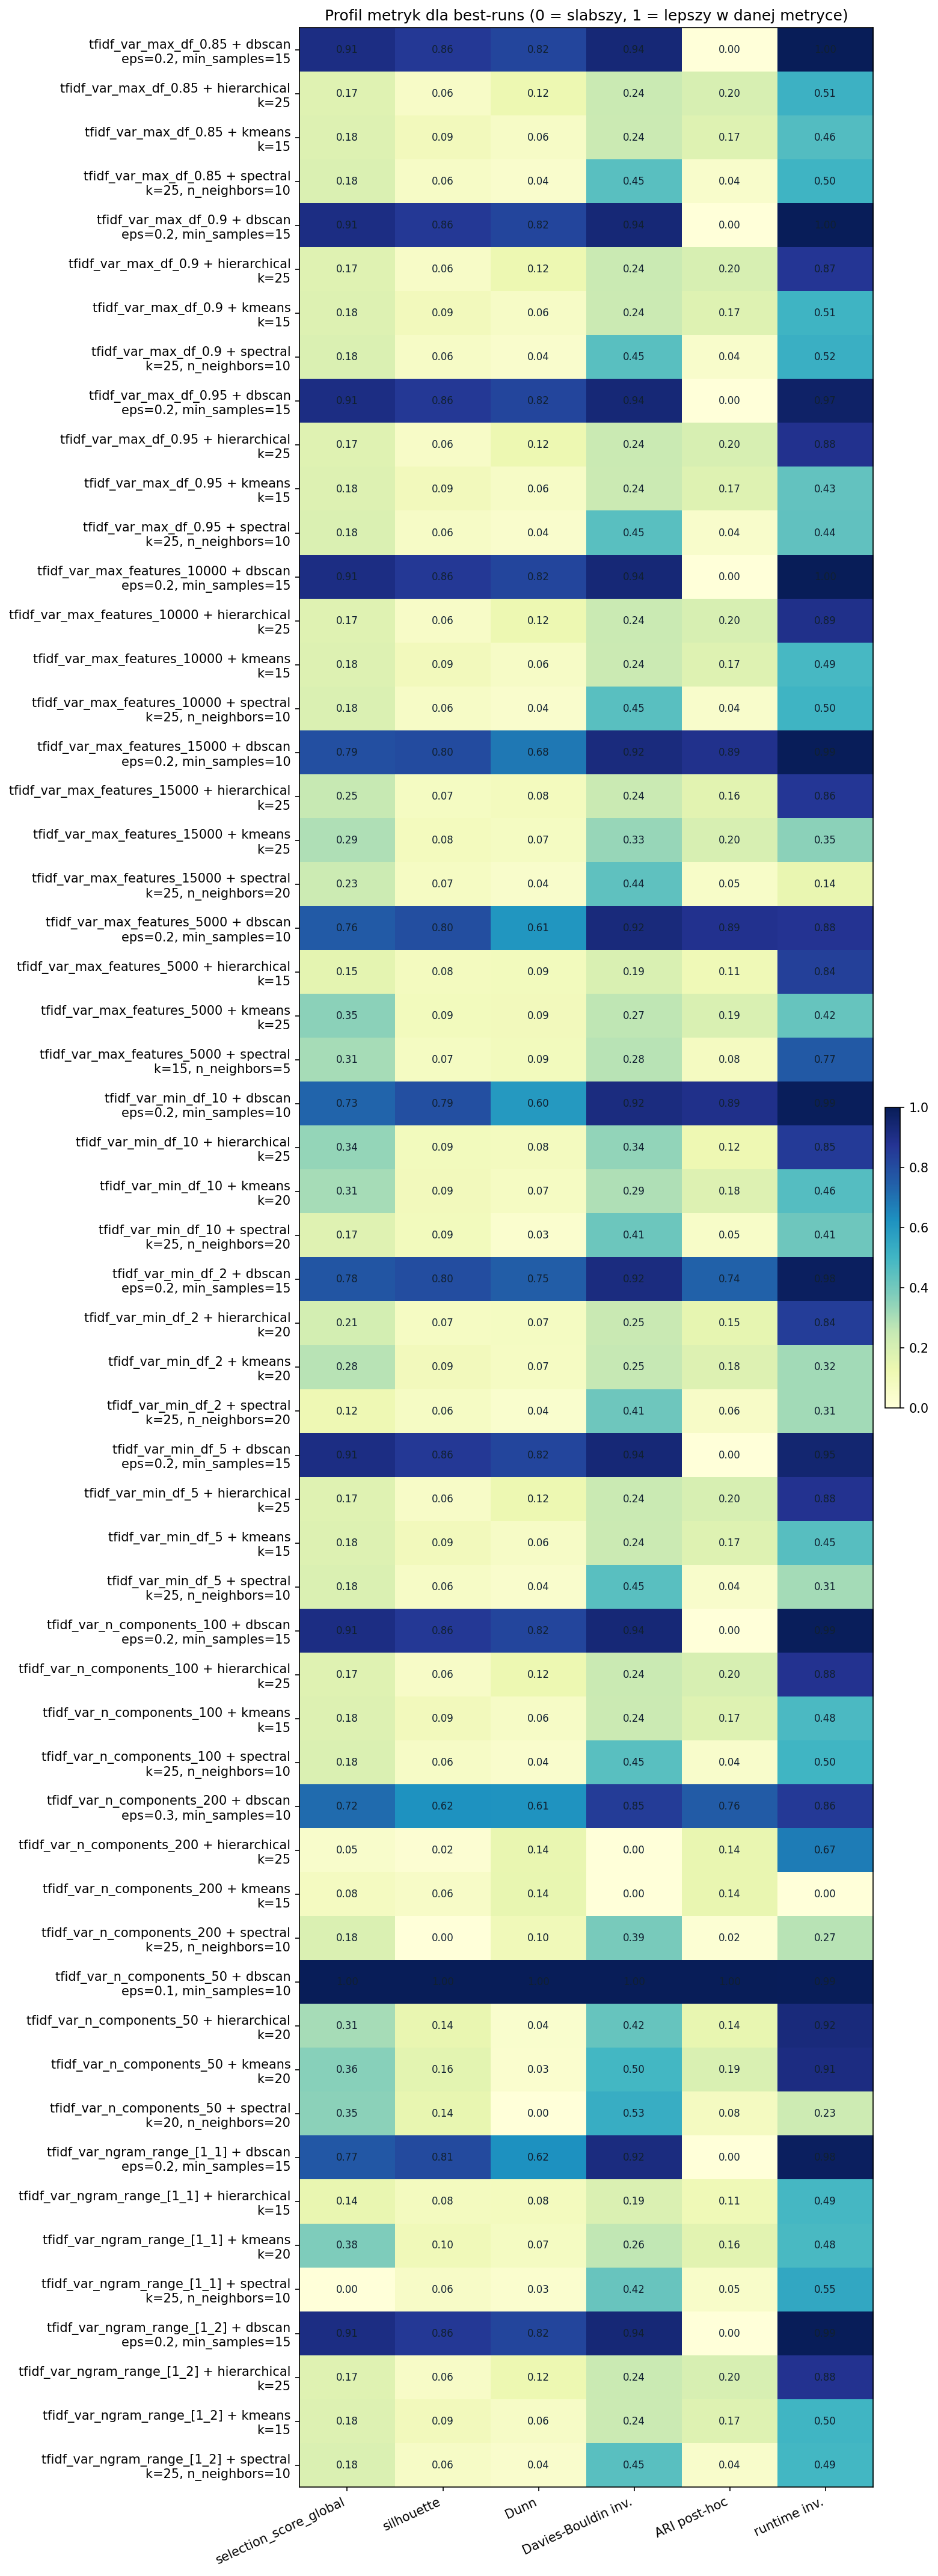

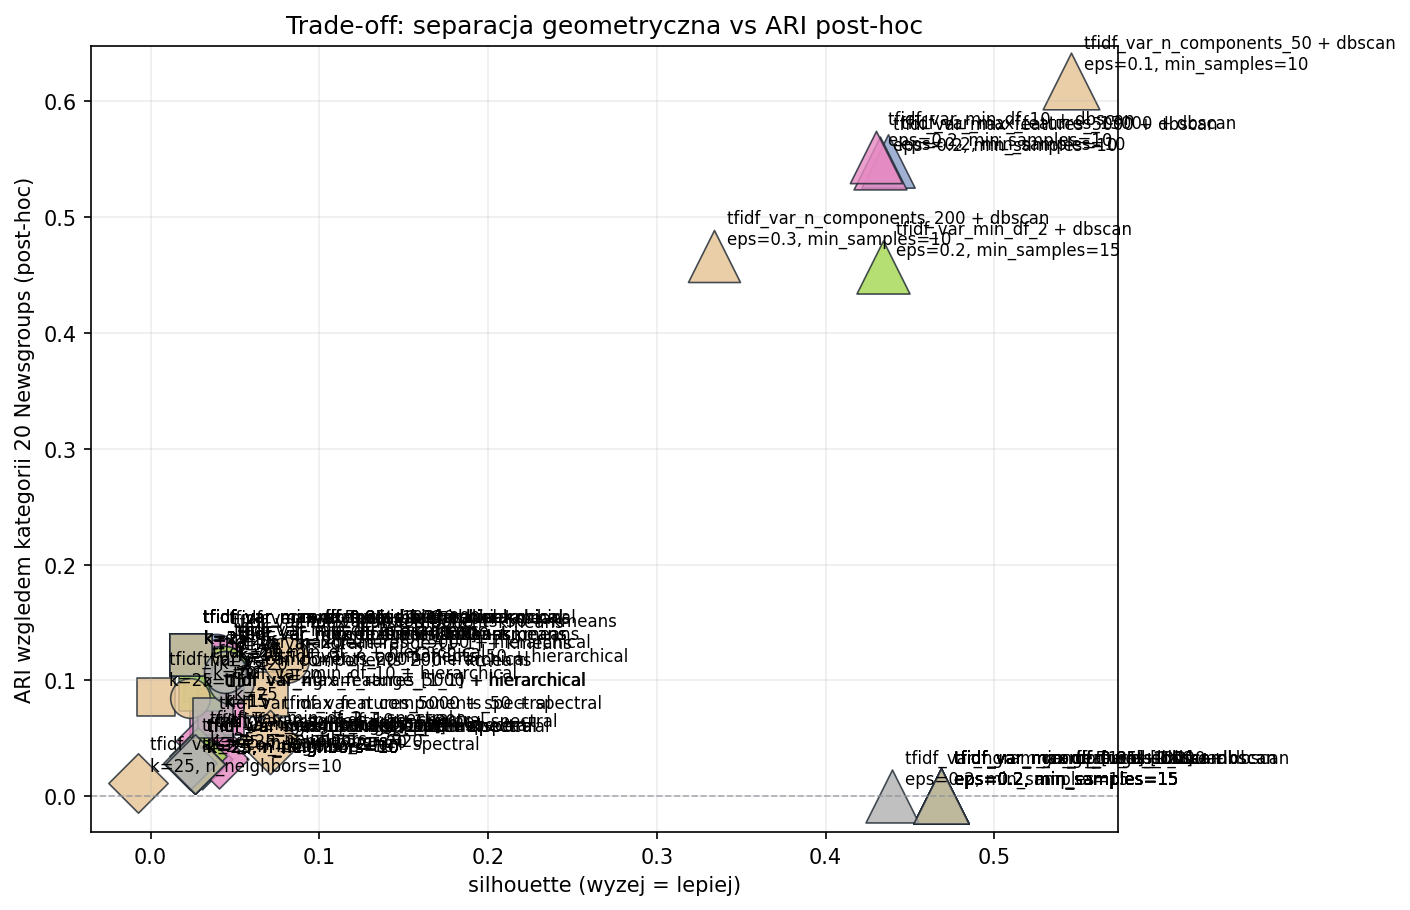

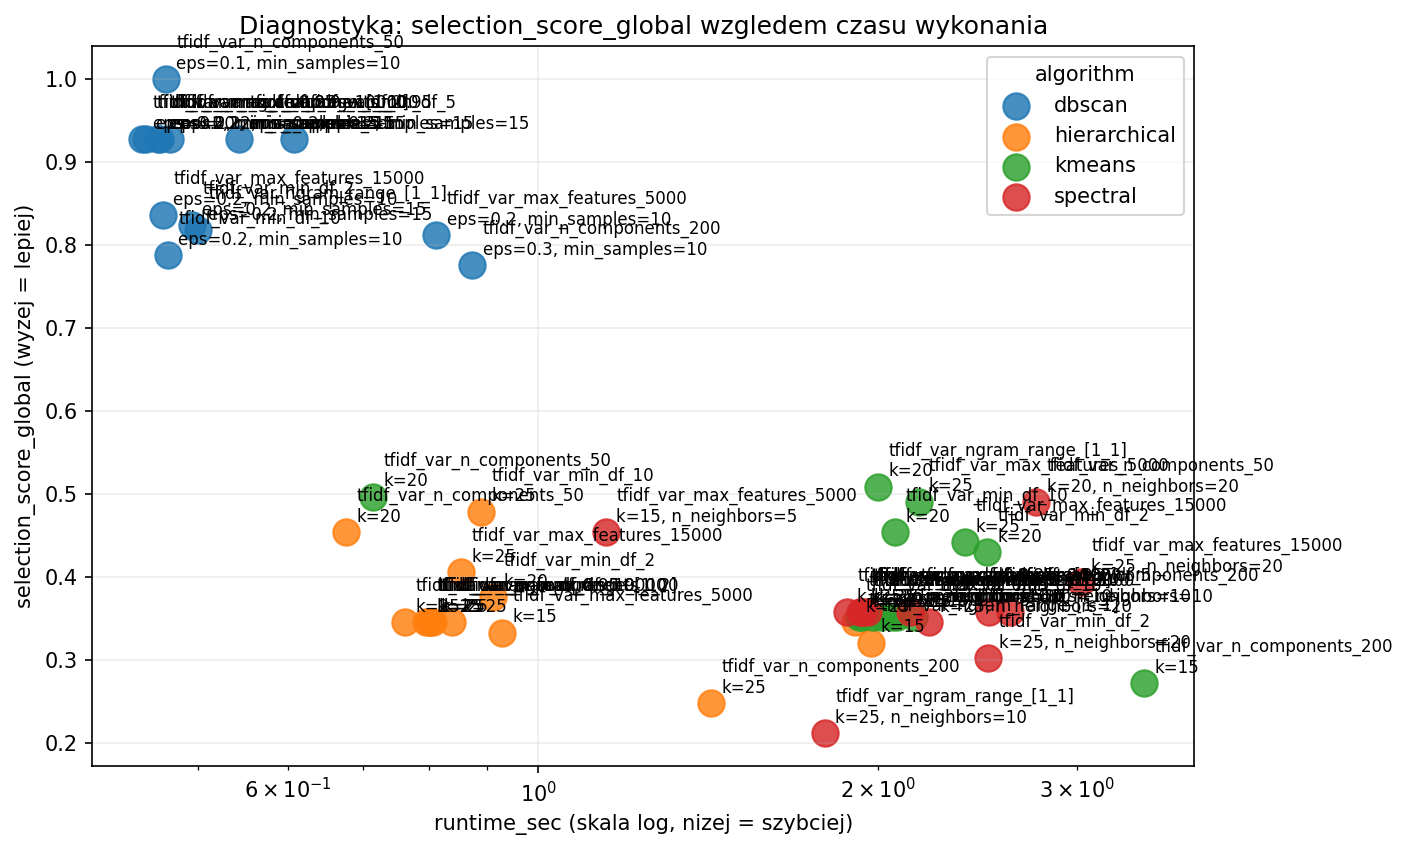

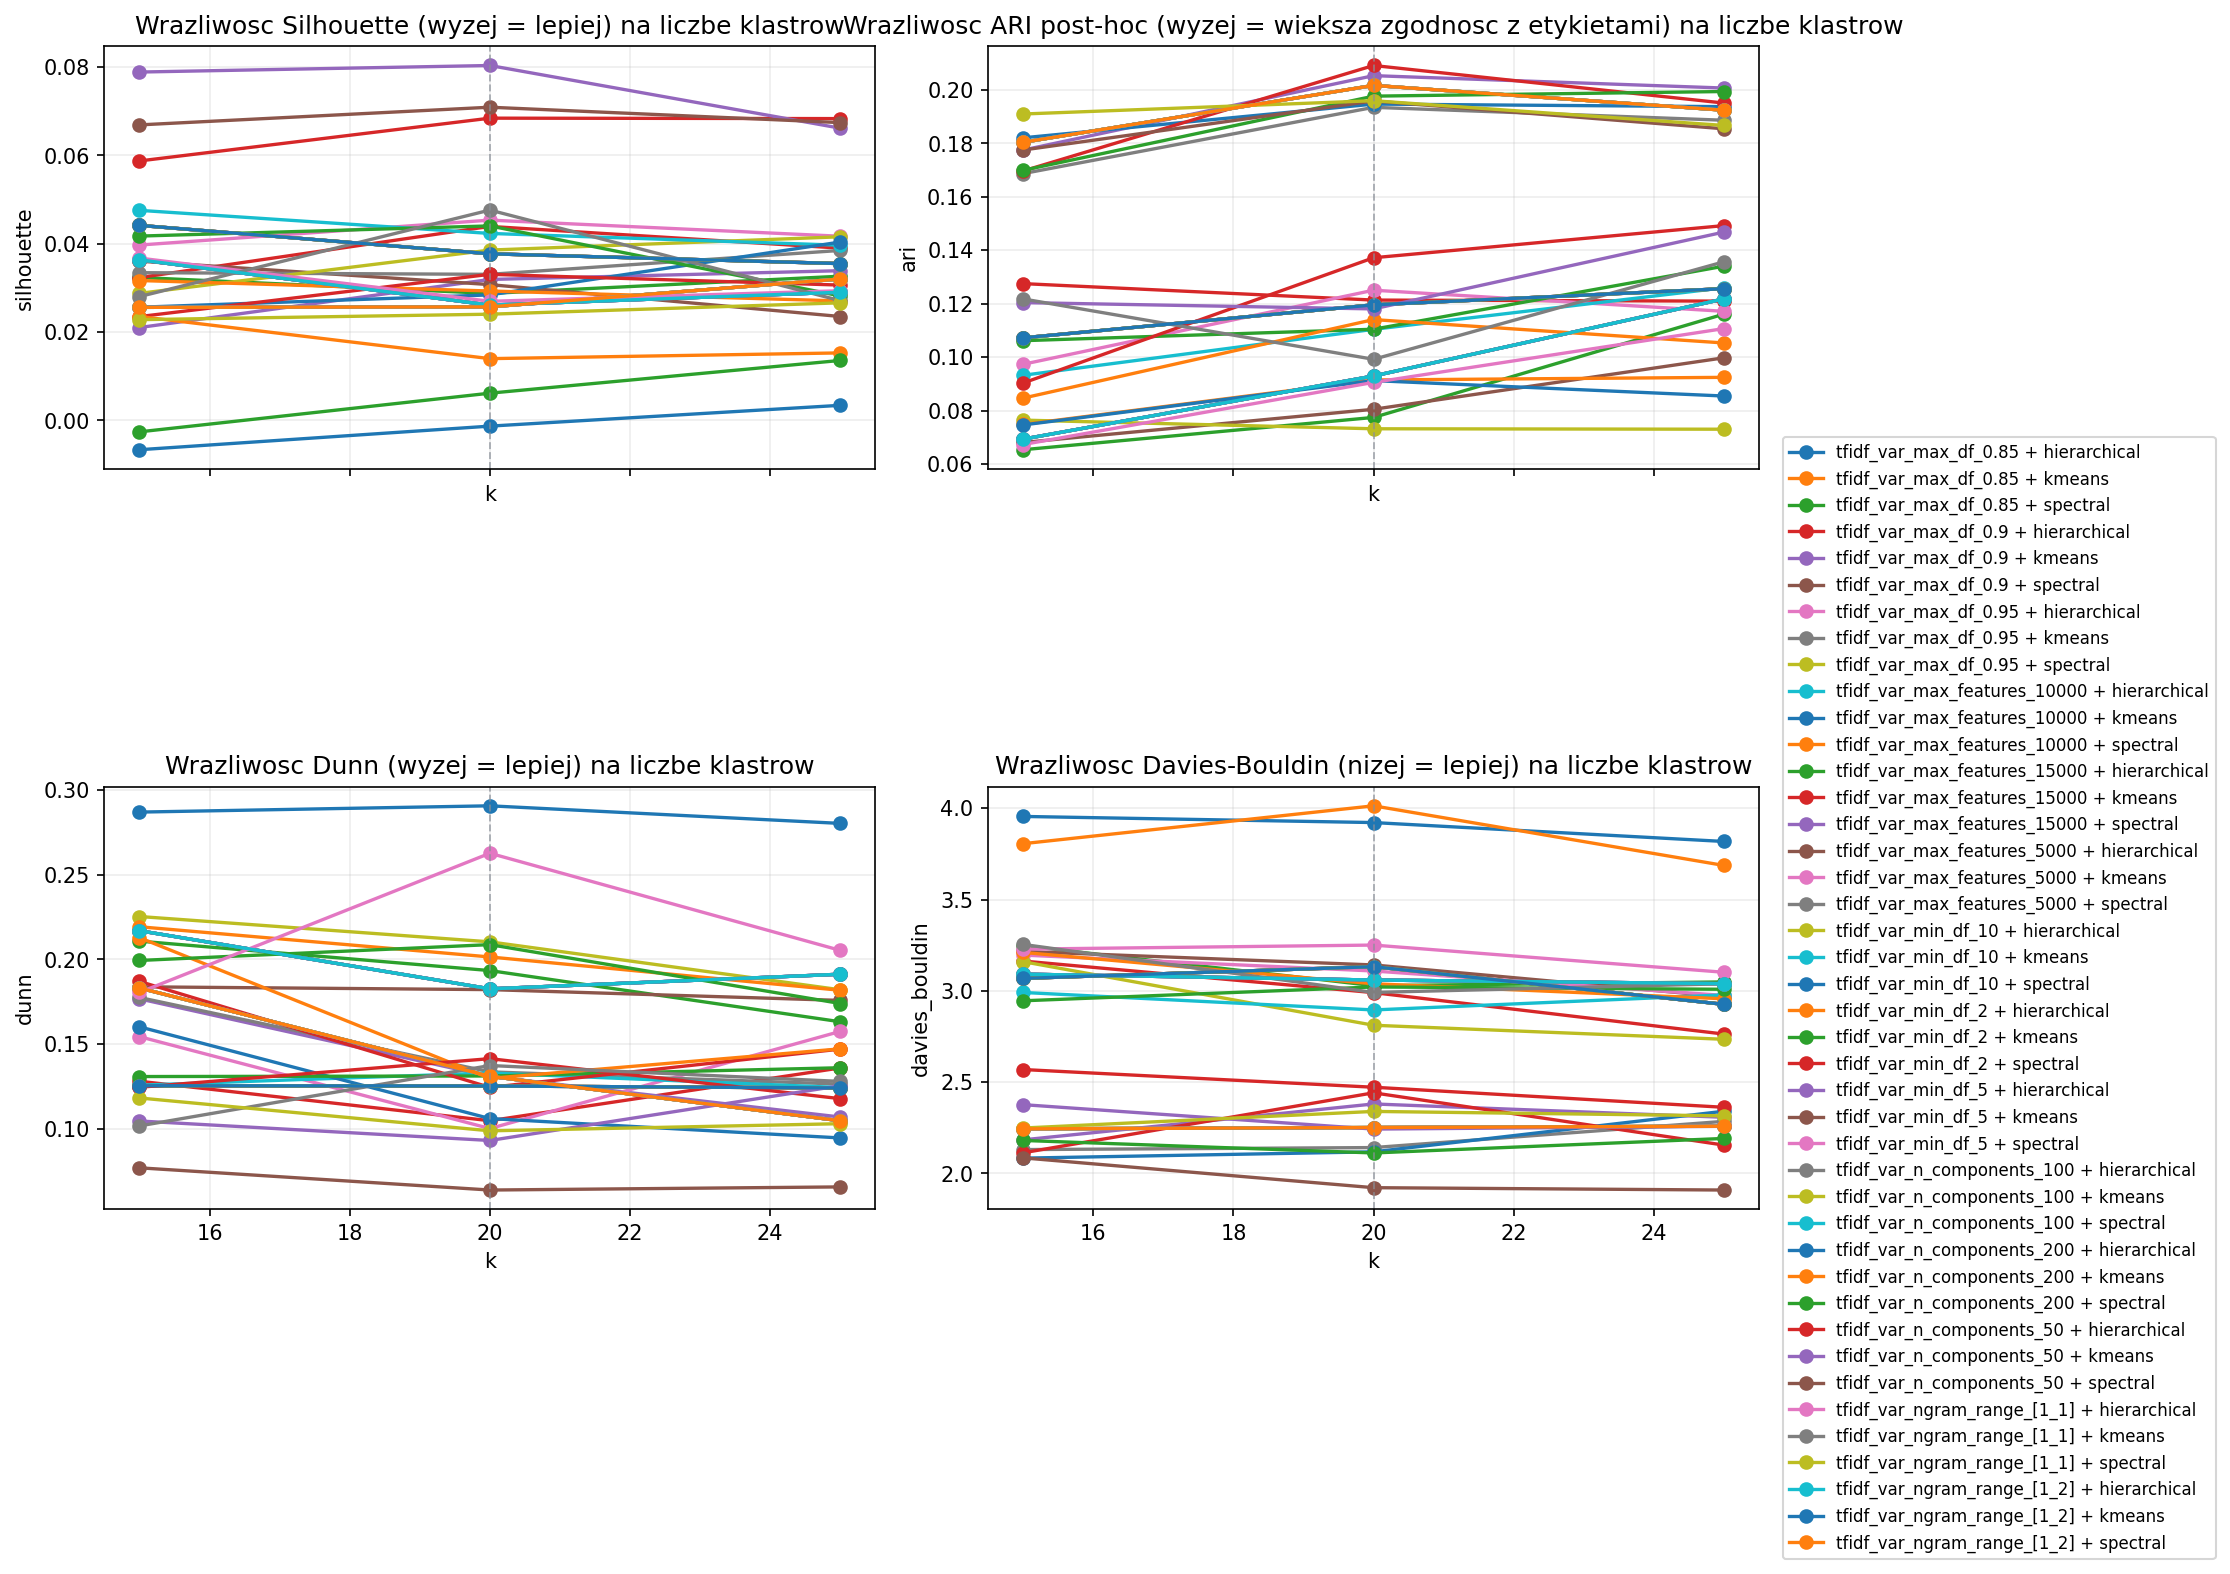

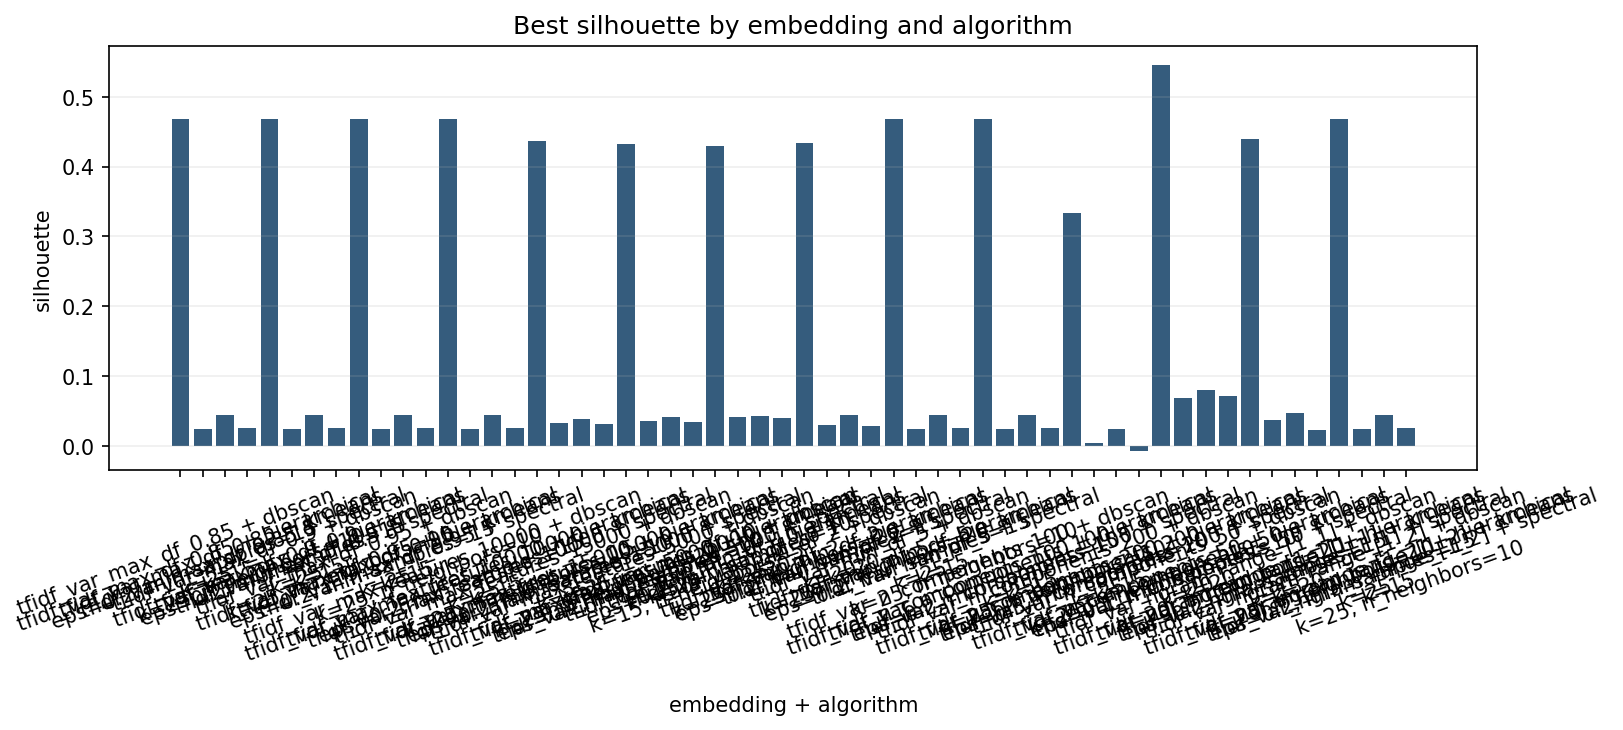

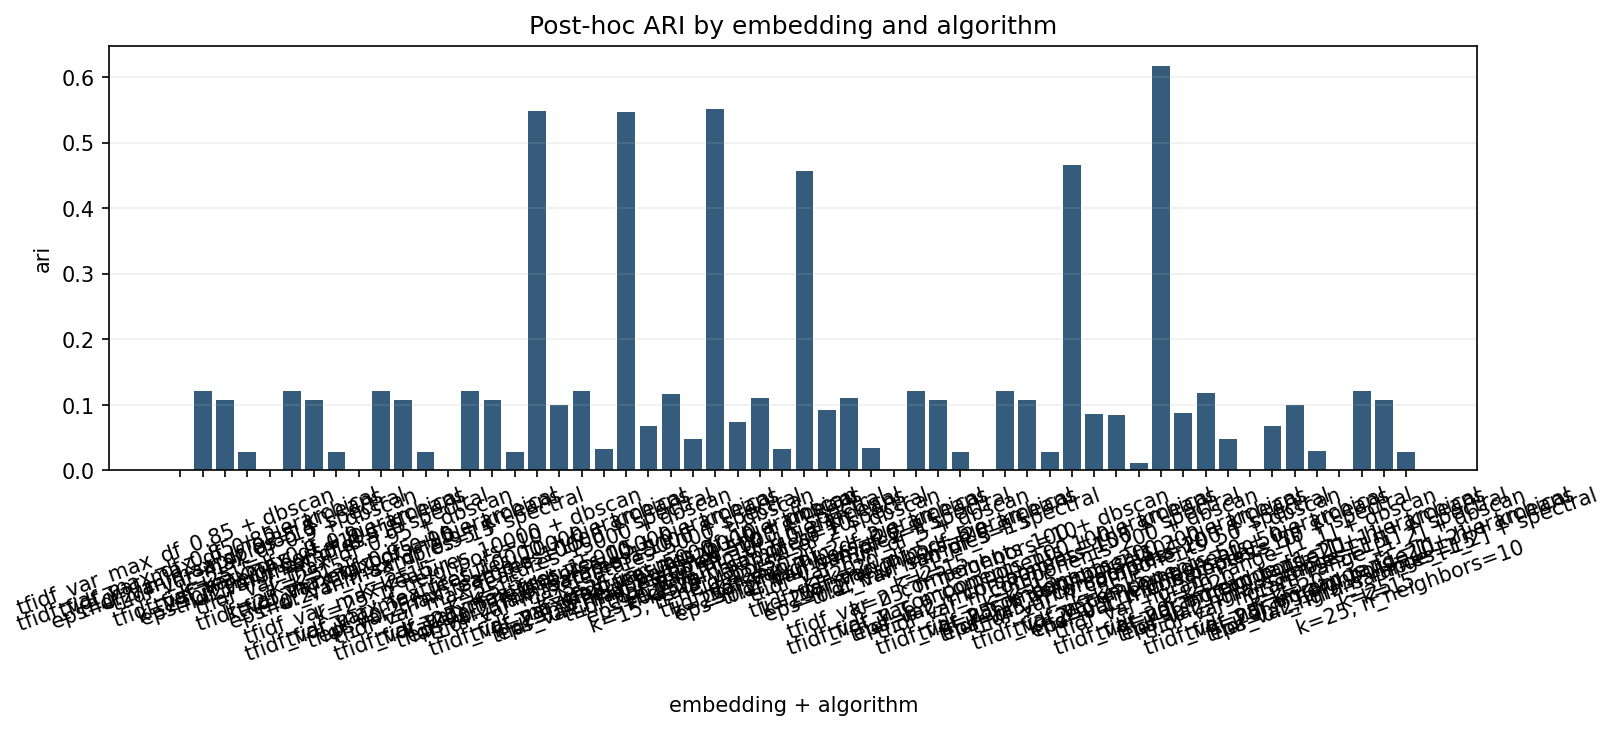

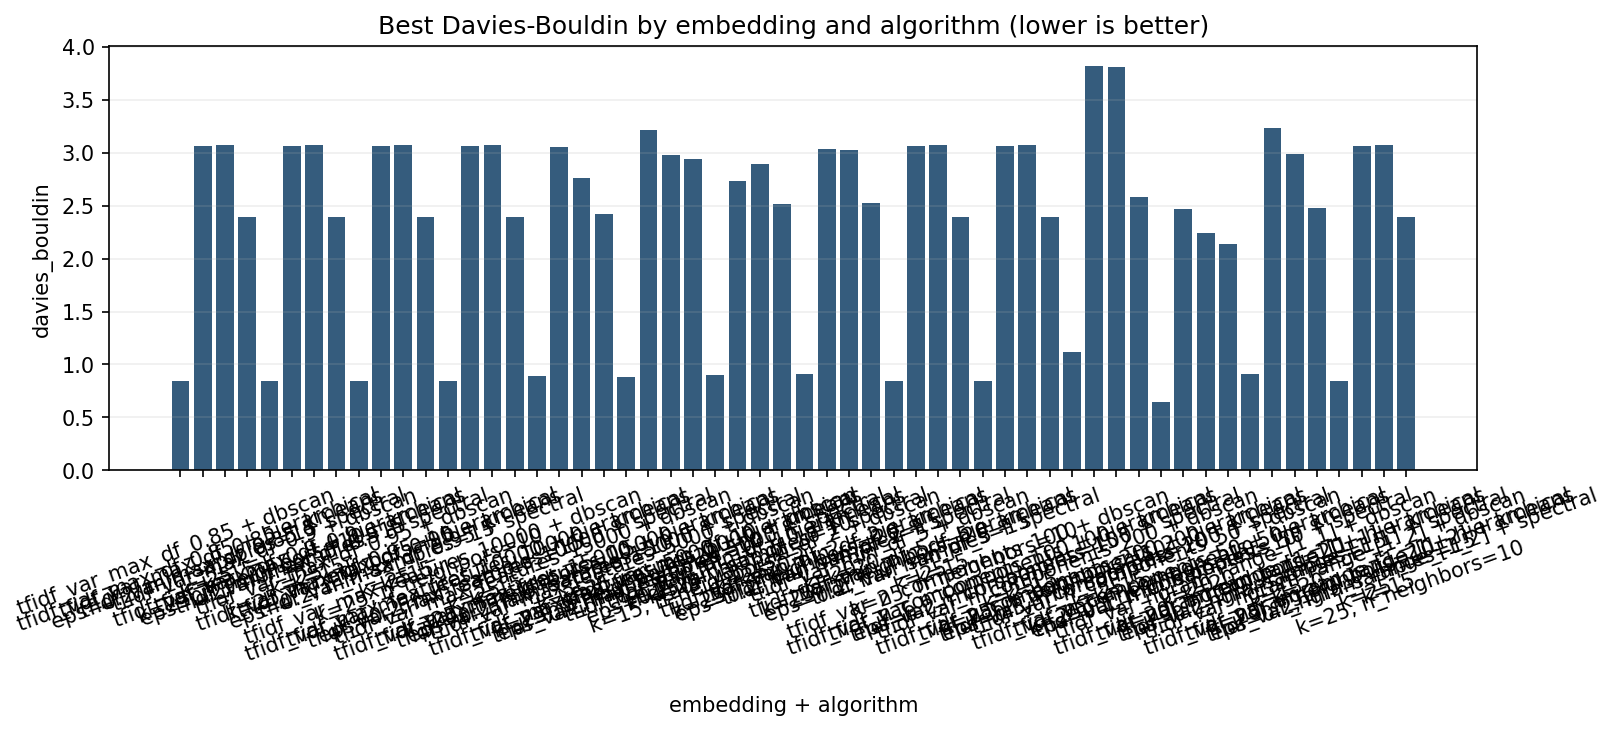

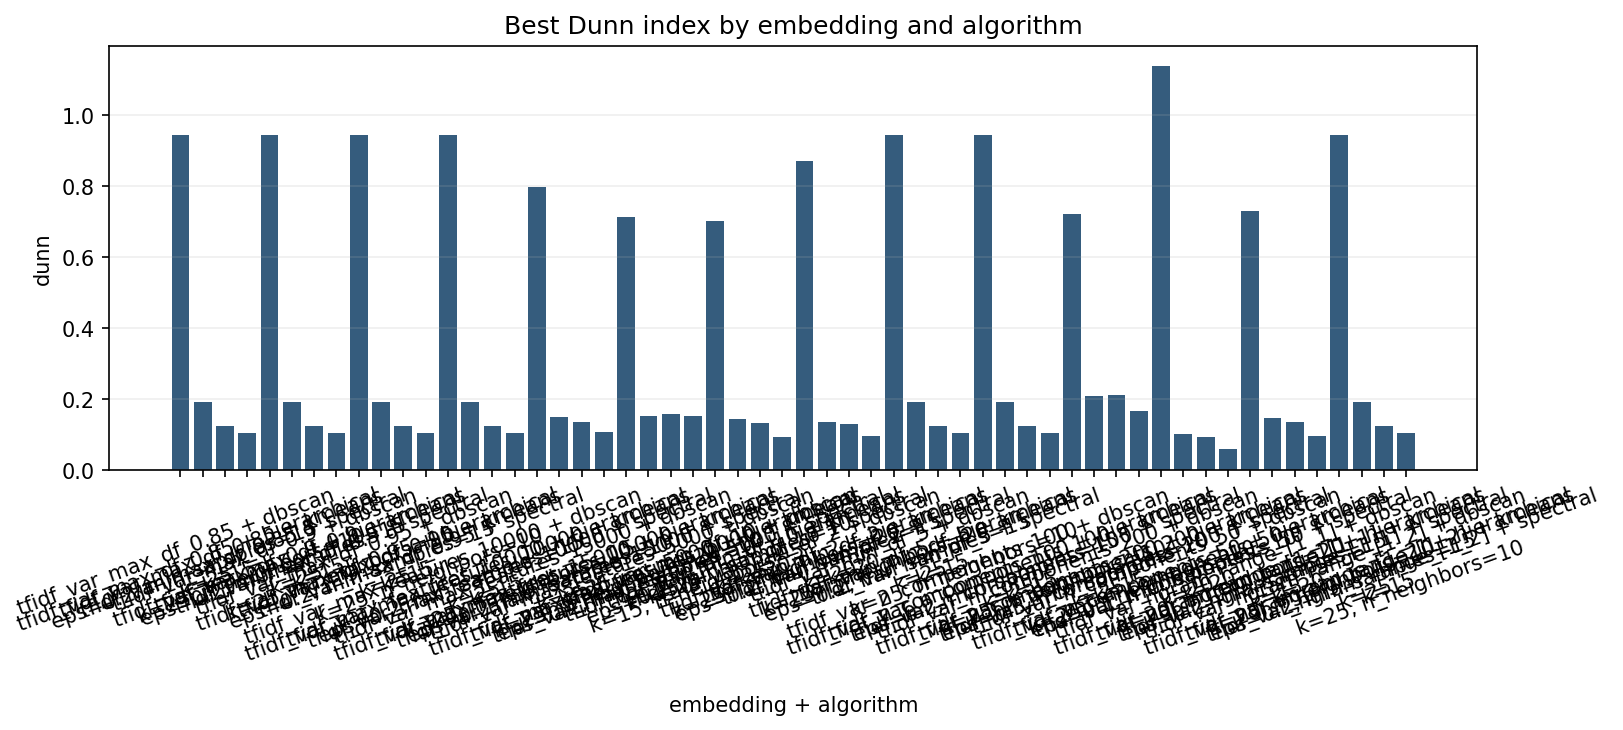

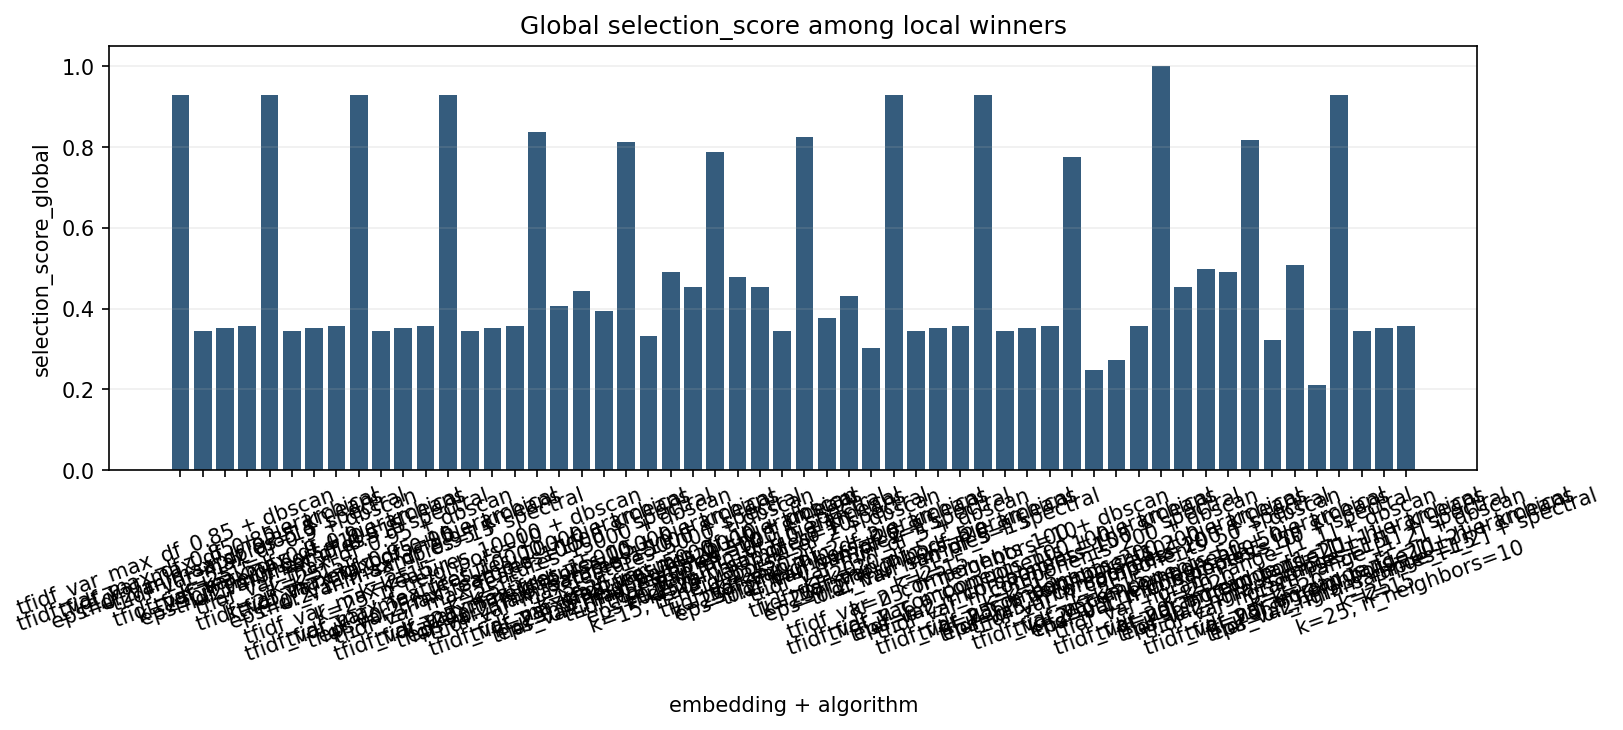

In [ ]:
from IPython.display import Image, Markdown, display

section10_views = build_section10_views(
    best_runs_df=best_runs_df,
    interpretation_runs_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
)

display(Markdown("### Tabela 10A. Leaderboard lokalnych zwyciezcow porownanych globalnie"))
display(section10_views["leaderboard"])

display(Markdown("### Tabela 10B. Podsumowanie reprezentacji wg selection_score_global"))
display(section10_views["embedding_summary"])

display(Markdown("### Tabela 10C. Podsumowanie algorytmow wg selection_score_global"))
display(section10_views["algorithm_summary"])

display(Markdown("### Tabela 10D. Analiza liczby klastrow (`k`)"))
display(section10_views["k_summary"])

if not section10_views["purity_summary"].empty:
    display(Markdown("### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi (post-hoc)"))
    display(section10_views["purity_summary"])

display(Markdown("### Wykresy przekrojowe sekcji 10"))
section10_plot_keys = [
    "section10_metric_profile_plot",
    "section10_tradeoff_plot",
    "section10_efficiency_plot",
    "section10_k_sensitivity_plot",
    "best_silhouette_plot",
    "best_ari_plot",
    "best_davies_bouldin_plot",
    "best_dunn_plot",
    "best_selection_score_global_plot",
]
for plot_key in section10_plot_keys:
    if plot_key in artifact_paths:
        display(Image(filename=artifact_paths[plot_key]))

section10_interactive_links = [
    f"<li><a href='{artifact_paths[key]}' target='_blank'>{key}</a></li>"
    for key in ["section10_tradeoff_interactive", "section10_efficiency_interactive"]
    if key in artifact_paths
]
if section10_interactive_links:
    display(HTML("<b>Interaktywne wykresy:</b><ul>" + "".join(section10_interactive_links) + "</ul>"))


## 11. Wnioski

**TODO**: Po wykonaniu notebooka uzupelnij wnioski na podstawie tabel i wykresow:
NP.:
- ktora reprezentacja ma najwyzszy `silhouette` i najnizszy `Davies-Bouldin`,
- czy `SBERT` poprawia separacje semantyczna wzgledem statycznych embeddingow,
- czy `K-means` i klasteryzacja hierarchiczna wskazuja podobna optymalna liczbe klastrow,
- jakie slowa i dokumenty najlepiej wyjasniaja najciekawsze klastry,
- jak wyniki `ARI` odnosza sie do prawdziwych kategorii `20 Newsgroups`.

## [TEMPLATE: Sekcja 11 - Wnioski i podsumowanie ogólne eksperymentu]
> **TODO:** W tej konkluzji opieramy się na całokształcie problemu (wyzwania przy redukcji wymiarów tekstowych, limitacje modeli).

### 11.1 Główne obserwacje
* *[Wylistuj główne punkty (takeaways) z całego projektu]*
1. ...
2. ...
3. ...

### 11.2 Rekomendacje dla przyszłych iteracji (Ograniczenia i Future Work)
* *[Zaproponuj modyfikacje, np. użycie modeli generatywnych (LLM), zmiana metod preprocessingu lub uwzględnienie metod t-SNE/UMAP przy pipeline (obecnie skupiliśmy się na metodach klasycznych)]*

## [TEMPLATE: Sekcja 12 - Weryfikacja pytań badawczych i hipotez]
> **TODO:** W oparciu o wygenerowane modele, odpowiedz na główne pytania badawcze ujęte w koncepcji projektu i uargumentuj je uzyskanymi metrykami z podsumowania.

### Hipoteza / Pytanie badawcze 1: *[Wpisz tu pierwsze główne pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników (metryki / czas przetwarzania)**: *[uzupełnij]*

### Hipoteza / Pytanie badawcze 2: *[Wpisz tu drugie pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Hipoteza / Pytanie badawcze 3:
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Końcowa weryfikacja obiektywna
*[Podsumowanie eksperymentów. Wybór najlepszych algorytmów. Ocena wykonania zadania]*